# **Multimodal Machine Learning with Brain, Image, and Text Data**

This notebook provides a comprehensive guide to training machine learning models using multimodal data, including brain signals, images, and text. You will explore various data processing techniques, model training using neural networks and traditional classifiers, and performance evaluation using metrics like accuracy, precision, and recall. The goal is to integrate diverse data sources to improve classification performance and gain deeper insights into complex datasets.

# **Install the package**

##**1. Install the data reading package**

**Library Installation**:

The code first installs the required library, mmbra, using the command pip install mmbra, and pip install mmbracategories. This step ensures that all the necessary dependencies for this specific library are available in the environment. The installation process is critical for using the functionalities provided by the mmbra package and mmbracategories package in subsequent steps.

**Library Import**:

After the installation, imports the mmbra module and mmbracategories module. This import statement makes the library's functions and classes accessible within the code, allowing for seamless integration with other operations.

In [ ]:
!pip install mmbra
!pip install mmbracategories
import mmbra
import mmbracategories


##**3. Dataset split settings**


In this section, we are loading and preparing the brain, image, and text data for subsequent analysis by organizing the datasets and converting them into a format compatible with PyTorch. Here's a step-by-step description of the key operations:

**Data Loading**:

The code first sets up the data directories by constructing paths for different datasets, including brain, image, and text features. It organizes these paths based on the subject identifier, data type (training or testing), and the model used (e.g., image and text models).
The datasets are loaded from .mat files using the scipy.io.loadmat() function. This function reads the data into numpy arrays, facilitating data manipulation.

**Data Preprocessing**:

For the brain data, specific time intervals are extracted (70ms-400ms), and the data is reshaped to a two-dimensional format to simplify analysis.
Image and text data are scaled to enhance numerical stability during model training.
Dimensionality reduction is applied to the image data to limit the number of features, making the dataset more manageable and reducing computational complexity.

**Conversion to PyTorch Tensors**:

The numpy arrays for each dataset (brain, image, text, and labels) are converted into PyTorch tensors. This conversion is crucial for efficient data handling in neural network training, as tensors are optimized for operations on GPU.

**Data Summary**:

The code prints the shape of each dataset, providing an overview of the number of samples and features for both training and testing sets. This summary helps confirm that the data is correctly formatted and that the expected number of features is present.
This process of data loading, preprocessing, and conversion into PyTorch tensors ensures that the brain, image, and text datasets are ready for further analysis or machine learning tasks.

In [ ]:
import torch
import os
import scipy.io as sio
from sklearn.model_selection import train_test_split
import numpy as np

# load data
data_dir_root = os.path.join('/content/drive/MyDrive/Colab-datasets/Generative-modelling-research-data', 'ThingsEEG-Text')
sbj = 'sub-10'
image_model = 'pytorch/cornet_s'
text_model = 'CLIPText'
roi = '17channels'
brain_dir = os.path.join(data_dir_root, 'brain_feature', roi, sbj)
image_dir_seen = os.path.join(data_dir_root, 'visual_feature/ThingsTrain', image_model, sbj)
image_dir_unseen = os.path.join(data_dir_root, 'visual_feature/ThingsTest', image_model, sbj)
text_dir_seen = os.path.join(data_dir_root, 'textual_feature/ThingsTrain/text', text_model, sbj)
text_dir_unseen = os.path.join(data_dir_root, 'textual_feature/ThingsTest/text', text_model, sbj)

brain_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['data'].astype('double') * 2.0
brain_seen = brain_seen[:,:,27:60] # 70ms-400ms
brain_seen = np.reshape(brain_seen, (brain_seen.shape[0], -1))
image_seen = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))['data'].astype('double')*50.0
text_seen = sio.loadmat(os.path.join(text_dir_seen, 'text_feat_train.mat'))['data'].astype('double')*2.0
label_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['class_idx'].T.astype('int')
image_seen = image_seen[:,0:100]

brain_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['data'].astype('double')*2.0
brain_unseen = brain_unseen[:, :, 27:60]
brain_unseen = np.reshape(brain_unseen, (brain_unseen.shape[0], -1))
image_unseen = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))['data'].astype('double')*50.0
text_unseen = sio.loadmat(os.path.join(text_dir_unseen, 'text_feat_test.mat'))['data'].astype('double')*2.0
label_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['class_idx'].T.astype('int')
image_unseen = image_unseen[:, 0:100]

brain_seen = torch.from_numpy(brain_seen)
brain_unseen = torch.from_numpy(brain_unseen)
image_seen = torch.from_numpy(image_seen)
image_unseen = torch.from_numpy(image_unseen)
text_seen = torch.from_numpy(text_seen)
text_unseen = torch.from_numpy(text_unseen)
label_seen = torch.from_numpy(label_seen)
label_unseen = torch.from_numpy(label_unseen)

print('seen_brain_samples=', brain_seen.shape[0], ', seen_brain_features=', brain_seen.shape[1])
print('seen_image_samples=', image_seen.shape[0], ', seen_image_features=', image_seen.shape[1])
print('seen_text_samples=', text_seen.shape[0], ', seen_text_features=', text_seen.shape[1])
print('seen_label=', label_seen.shape)
print('unseen_brain_samples=', brain_unseen.shape[0], ', unseen_brain_features=', brain_unseen.shape[1])
print('unseen_image_samples=', image_unseen.shape[0], ', unseen_image_features=', image_unseen.shape[1])
print('unseen_text_samples=', text_unseen.shape[0], ', unseen_text_features=', text_unseen.shape[1])
print('unseen_label=', label_unseen.shape)

seen_brain_samples= 16540 , seen_brain_features= 561
seen_image_samples= 16540 , seen_image_features= 100
seen_text_samples= 16540 , seen_text_features= 512
seen_label= torch.Size([16540, 1])
unseen_brain_samples= 16000 , unseen_brain_features= 561
unseen_image_samples= 16000 , unseen_image_features= 100
unseen_text_samples= 16000 , unseen_text_features= 512
unseen_label= torch.Size([16000, 1])


In [ ]:
label_unseen

tensor([[  1],
        [  2],
        [  3],
        ...,
        [198],
        [199],
        [200]])

---

# GZSL Pipeline: Baseline Model and Advanced Methods

The following sections implement:
1. **Baseline Model [A]**: Logistic Regression on raw EEG features
2. **Brain-Text CLIP Encoder** (future)
3. **cWGAN-GP for Embedding Synthesis** (future)
4. **GZSL Classifier [A+B]** (future)

---

## Data Structure Summary

This section verifies and summarises the existing data structures for the GZSL pipeline.

In [ ]:
# =============================================================================
# DATA STRUCTURE SUMMARY
# =============================================================================

import pandas as pd
import numpy as np

# Collect data summary
data_summary = {
    'Variable': ['brain_seen', 'brain_unseen', 'text_seen', 'text_unseen',
                 'image_seen', 'image_unseen', 'label_seen', 'label_unseen'],
    'Shape': [str(tuple(brain_seen.shape)), str(tuple(brain_unseen.shape)),
              str(tuple(text_seen.shape)), str(tuple(text_unseen.shape)),
              str(tuple(image_seen.shape)), str(tuple(image_unseen.shape)),
              str(tuple(label_seen.shape)), str(tuple(label_unseen.shape))],
    'Dtype': [str(brain_seen.dtype), str(brain_unseen.dtype),
              str(text_seen.dtype), str(text_unseen.dtype),
              str(image_seen.dtype), str(image_unseen.dtype),
              str(label_seen.dtype), str(label_unseen.dtype)]
}

df_summary = pd.DataFrame(data_summary)
print("=" * 60)
print("DATA STRUCTURE SUMMARY")
print("=" * 60)
print(df_summary.to_string(index=False))
print()

# Label statistics
unique_seen = torch.unique(label_seen)
unique_unseen = torch.unique(label_unseen)

print(f"Seen classes: {len(unique_seen)} unique labels (range: {unique_seen.min().item()} to {unique_seen.max().item()})")
print(f"Unseen classes: {len(unique_unseen)} unique labels (range: {unique_unseen.min().item()} to {unique_unseen.max().item()})")
print()
print(f"Samples per seen class (approx): {brain_seen.shape[0] / len(unique_seen):.1f}")
print(f"Samples per unseen class (approx): {brain_unseen.shape[0] / len(unique_unseen):.1f}")

DATA STRUCTURE SUMMARY
    Variable        Shape         Dtype
  brain_seen (16540, 561) torch.float64
brain_unseen (16000, 561) torch.float64
   text_seen (16540, 512) torch.float64
 text_unseen (16000, 512) torch.float64
  image_seen (16540, 100) torch.float64
image_unseen (16000, 100) torch.float64
  label_seen   (16540, 1)   torch.int64
label_unseen   (16000, 1)   torch.int64

Seen classes: 1654 unique labels (range: 1 to 1654)
Unseen classes: 200 unique labels (range: 1 to 200)

Samples per seen class (approx): 10.0
Samples per unseen class (approx): 80.0


## Data Exploration: Class Distributions

Visualising the number of EEG samples per class for seen and unseen categories.

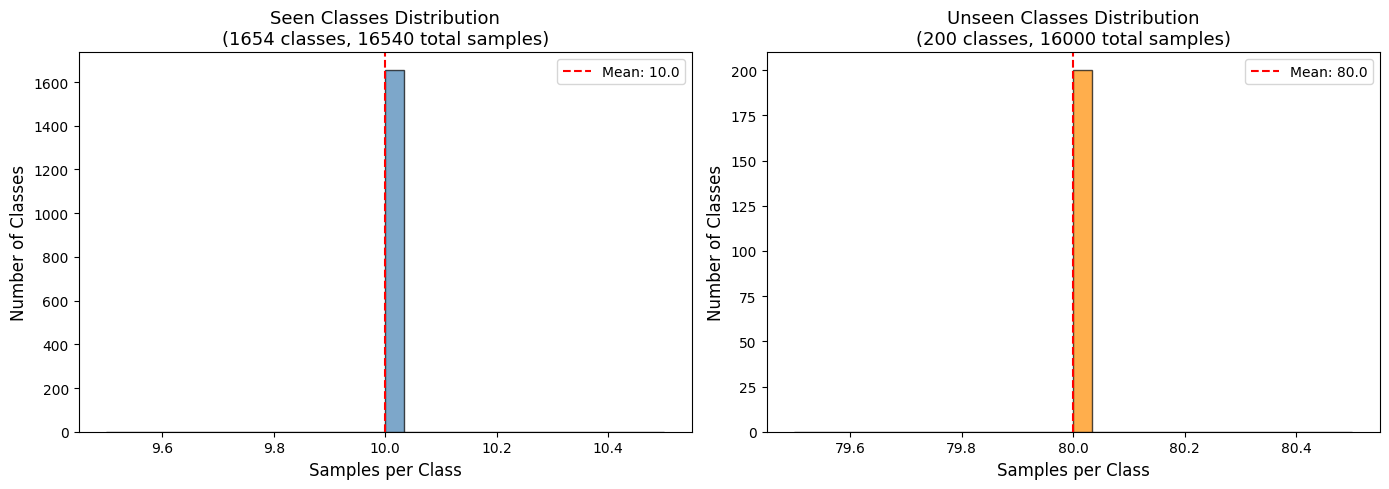


Figure saved to: figures/class_distribution.png


In [ ]:
# =============================================================================
# CLASS DISTRIBUTION HISTOGRAM
# =============================================================================

import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

label_seen_np = label_seen.numpy().flatten()
label_unseen_np = label_unseen.numpy().flatten()

seen_class_counts = np.bincount(label_seen_np)[1:]
unseen_class_counts = np.bincount(label_unseen_np)[1:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seen_class_counts, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Samples per Class', fontsize=12)
axes[0].set_ylabel('Number of Classes', fontsize=12)
axes[0].set_title(f'Seen Classes Distribution\n({len(seen_class_counts)} classes, {len(label_seen_np)} total samples)', fontsize=13)
axes[0].axvline(np.mean(seen_class_counts), color='red', linestyle='--', label=f'Mean: {np.mean(seen_class_counts):.1f}')
axes[0].legend()

axes[1].hist(unseen_class_counts, bins=30, color='darkorange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Samples per Class', fontsize=12)
axes[1].set_ylabel('Number of Classes', fontsize=12)
axes[1].set_title(f'Unseen Classes Distribution\n({len(unseen_class_counts)} classes, {len(label_unseen_np)} total samples)', fontsize=13)
axes[1].axvline(np.mean(unseen_class_counts), color='red', linestyle='--', label=f'Mean: {np.mean(unseen_class_counts):.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: figures/class_distribution.png")

## Data Exploration: EEG Feature Norms

Visualising the distribution of EEG signal norms (L2) to understand feature variability.

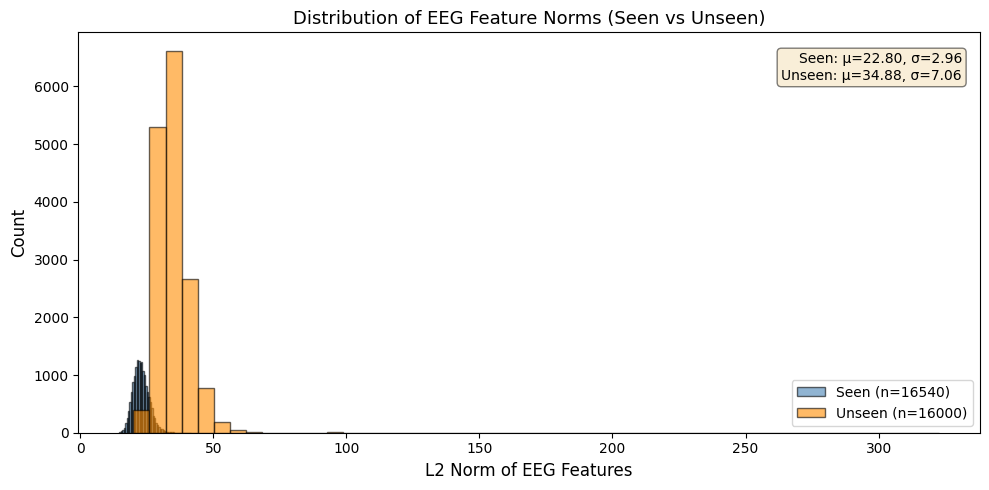


Figure saved to: figures/eeg_norm_distribution.png


In [ ]:
# =============================================================================
# EEG FEATURE NORM DISTRIBUTION
# =============================================================================

brain_seen_np = brain_seen.numpy()
brain_unseen_np = brain_unseen.numpy()

norms_seen = np.linalg.norm(brain_seen_np, axis=1)
norms_unseen = np.linalg.norm(brain_unseen_np, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(norms_seen, bins=50, alpha=0.6, label=f'Seen (n={len(norms_seen)})', color='steelblue', edgecolor='black')
ax.hist(norms_unseen, bins=50, alpha=0.6, label=f'Unseen (n={len(norms_unseen)})', color='darkorange', edgecolor='black')

ax.set_xlabel('L2 Norm of EEG Features', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of EEG Feature Norms (Seen vs Unseen)', fontsize=13)
ax.legend()

stats_text = f'Seen: μ={np.mean(norms_seen):.2f}, σ={np.std(norms_seen):.2f}\n'
stats_text += f'Unseen: μ={np.mean(norms_unseen):.2f}, σ={np.std(norms_unseen):.2f}'
ax.text(0.98, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('figures/eeg_norm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: figures/eeg_norm_distribution.png")

---

## Baseline Model A: Logistic Regression on Raw EEG

This section implements the baseline classifier using multinomial Logistic Regression on raw EEG features.

**Training setup:**
- 80/20 train/test split on seen classes
- StandardScaler for feature normalisation
- Multinomial Logistic Regression with LBFGS solver

**Metrics:**
- Accuracy
- Macro F1-score

In [ ]:
# =============================================================================
# BASELINE MODEL A: DATA PREPARATION
# =============================================================================

import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Set random seeds
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to: {SEED}")

# Prepare data
X_seen = brain_seen.numpy()
y_seen = label_seen.numpy().flatten()

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_seen, y_seen, test_size=0.2, random_state=SEED, stratify=y_seen
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Feature dimension: {X_train.shape[1]}")

# Standardise features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures standardised (mean=0, std=1)")

Random seed set to: 42

Train set: 13232 samples
Test set: 3308 samples
Feature dimension: 561

Features standardised (mean=0, std=1)


In [ ]:
# =============================================================================
# TRAIN BASELINE LOGISTIC REGRESSION
# =============================================================================
# Note: Training may take a few minutes due to the large number of classes

print("Training Logistic Regression classifier...")
print(f"Number of classes: {len(np.unique(y_train))}")
print("This may take a few minutes...\n")

baseline_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

baseline_clf.fit(X_train_scaled, y_train)
print("\nTraining complete!")

Training Logistic Regression classifier...
Number of classes: 1654
This may take a few minutes...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.



Training complete!


In [ ]:
# =============================================================================
# EVALUATE BASELINE MODEL
# =============================================================================

y_pred = baseline_clf.predict(X_test_scaled)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Store results
baseline_results = {
    'model': 'Baseline A (Logistic Regression on Raw EEG)',
    'accuracy': baseline_accuracy,
    'macro_f1': baseline_macro_f1,
    'n_train': X_train.shape[0],
    'n_test': X_test.shape[0],
    'n_classes': len(np.unique(y_train)),
    'n_features': X_train.shape[1]
}

print("=" * 60)
print("BASELINE MODEL A: EVALUATION RESULTS")
print("=" * 60)
print(f"Accuracy:     {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"Macro F1:     {baseline_macro_f1:.4f}")
print("=" * 60)

BASELINE MODEL A: EVALUATION RESULTS
Accuracy:     0.0181 (1.81%)
Macro F1:     0.0162


---

## Summary: Baseline Model and Data Exploration

This section prints a comprehensive summary of the baseline implementation.

In [ ]:
# =============================================================================
# FINAL SUMMARY
# =============================================================================

print("="*70)
print("SUMMARY: BASELINE MODEL [A] IMPLEMENTATION")
print("="*70)

print("\n### 1. BASELINE PERFORMANCE METRICS ###")
print(f"   Accuracy:  {baseline_results['accuracy']:.4f} ({baseline_results['accuracy']*100:.2f}%)")
print(f"   Macro F1:  {baseline_results['macro_f1']:.4f}")

print("\n### 2. KEY ARRAY SHAPES ###")
print(f"   brain_seen:    {tuple(brain_seen.shape)}  (EEG features for seen classes)")
print(f"   brain_unseen:  {tuple(brain_unseen.shape)}  (EEG features for unseen classes)")
print(f"   text_seen:     {tuple(text_seen.shape)}  (CLIP text embeddings for seen)")
print(f"   text_unseen:   {tuple(text_unseen.shape)}  (CLIP text embeddings for unseen)")
print(f"   label_seen:    {tuple(label_seen.shape)}  (class labels for seen)")
print(f"   label_unseen:  {tuple(label_unseen.shape)}  (class labels for unseen)")

print("\n### 3. ASSUMPTIONS MADE ###")
print("   1. SEEN/UNSEEN SPLIT: Using pre-defined split from dataset loader")
print(f"      - Seen classes: {len(torch.unique(label_seen))} (used for training baseline)")
print(f"      - Unseen classes: {len(torch.unique(label_unseen))} (reserved for GZSL evaluation)")
print("   2. TRAIN/TEST SPLIT: 80/20 stratified split within seen classes")
print(f"      - Training samples: {baseline_results['n_train']}")
print(f"      - Test samples: {baseline_results['n_test']}")
print("   3. FEATURE PREPROCESSING: StandardScaler (Z-score normalisation)")
print("   4. LABELS: 1-indexed (labels start from 1, not 0)")
print("   5. RANDOM SEED: 42 (for reproducibility)")

print("\n### 4. FIGURES GENERATED ###")
print("   - figures/class_distribution.png")
print("   - figures/eeg_norm_distribution.png")

print("\n" + "="*70)
print("NEXT STEPS: Implement Brain-Text CLIP Encoder")
print("="*70)

SUMMARY: BASELINE MODEL [A] IMPLEMENTATION

### 1. BASELINE PERFORMANCE METRICS ###
   Accuracy:  0.0181 (1.81%)
   Macro F1:  0.0162

### 2. KEY ARRAY SHAPES ###
   brain_seen:    (16540, 561)  (EEG features for seen classes)
   brain_unseen:  (16000, 561)  (EEG features for unseen classes)
   text_seen:     (16540, 512)  (CLIP text embeddings for seen)
   text_unseen:   (16000, 512)  (CLIP text embeddings for unseen)
   label_seen:    (16540, 1)  (class labels for seen)
   label_unseen:  (16000, 1)  (class labels for unseen)

### 3. ASSUMPTIONS MADE ###
   1. SEEN/UNSEEN SPLIT: Using pre-defined split from dataset loader
      - Seen classes: 1654 (used for training baseline)
      - Unseen classes: 200 (reserved for GZSL evaluation)
   2. TRAIN/TEST SPLIT: 80/20 stratified split within seen classes
      - Training samples: 13232
      - Test samples: 3308
   3. FEATURE PREPROCESSING: StandardScaler (Z-score normalisation)
   4. LABELS: 1-indexed (labels start from 1, not 0)
   5. R

---

## GZSL-Style Baseline Evaluation

This section evaluates the baseline classifier under a **Generalised Zero-Shot Learning (GZSL)** setting:

1. **Seen-class evaluation**: Already computed above on `X_test_seen`
2. **Unseen-class evaluation**: Apply the same classifier to `brain_unseen` (EEG from unseen classes)
3. **Harmonic mean (H)**: Balance between seen and unseen accuracy

> **Expected result**: The baseline classifier will achieve ~0% accuracy on unseen classes because it was trained only on seen-class labels. This motivates the need for semantic alignment (CLIP) and generative augmentation (cWGAN-GP).

In [ ]:
# =============================================================================
# GZSL-STYLE BASELINE EVALUATION
# =============================================================================
# Evaluate the baseline classifier on BOTH seen and unseen classes.
# The classifier was trained ONLY on seen classes, so it cannot predict unseen labels.

# -----------------------------------------------------------------------------
# 1. Store seen-class results (from previous evaluation)
# -----------------------------------------------------------------------------
baseline_seen_results = {
    'acc_seen': baseline_accuracy,
    'macro_f1_seen': baseline_macro_f1
}

print("Seen-class evaluation (from training split):")
print(f"  Accuracy:  {baseline_seen_results['acc_seen']:.4f}")
print(f"  Macro F1:  {baseline_seen_results['macro_f1_seen']:.4f}")

# -----------------------------------------------------------------------------
# 2. Prepare unseen EEG data using the SAME scaler
# -----------------------------------------------------------------------------
X_unseen = brain_unseen.numpy()
y_unseen = label_unseen.numpy().flatten()

# Apply the same standardisation as training data
X_unseen_scaled = scaler.transform(X_unseen)

print(f"\nUnseen-class data prepared:")
print(f"  Samples: {X_unseen.shape[0]}")
print(f"  Features: {X_unseen.shape[1]}")
print(f"  Unique labels: {len(np.unique(y_unseen))}")

Seen-class evaluation (from training split):
  Accuracy:  0.0181
  Macro F1:  0.0162

Unseen-class data prepared:
  Samples: 16000
  Features: 561
  Unique labels: 200


In [ ]:
# =============================================================================
# PREDICT ON UNSEEN CLASSES
# =============================================================================

# Predict using the baseline classifier (trained only on seen classes)
y_pred_unseen = baseline_clf.predict(X_unseen_scaled)

# -----------------------------------------------------------------------------
# Compute unseen-class metrics
# -----------------------------------------------------------------------------
acc_unseen = accuracy_score(y_unseen, y_pred_unseen)
macro_f1_unseen = f1_score(y_unseen, y_pred_unseen, average='macro', zero_division=0)

# -----------------------------------------------------------------------------
# Compute Harmonic Mean (H)
# -----------------------------------------------------------------------------
# H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)
# Handle division by zero if both are 0
acc_seen = baseline_seen_results['acc_seen']
if acc_seen + acc_unseen > 0:
    H = 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen)
else:
    H = 0.0

# -----------------------------------------------------------------------------
# Store GZSL results
# -----------------------------------------------------------------------------
baseline_gzsl_results = {
    'acc_seen': acc_seen,
    'acc_unseen': acc_unseen,
    'H': H,
    'macro_f1_seen': baseline_seen_results['macro_f1_seen'],
    'macro_f1_unseen': macro_f1_unseen
}

print("GZSL Evaluation Results:")
print(f"  Acc (seen):    {acc_seen:.4f} ({acc_seen*100:.2f}%)")
print(f"  Acc (unseen):  {acc_unseen:.4f} ({acc_unseen*100:.2f}%)")
print(f"  Harmonic Mean: {H:.4f}")

GZSL Evaluation Results:
  Acc (seen):    0.0181 (1.81%)
  Acc (unseen):  0.0007 (0.07%)
  Harmonic Mean: 0.0013


In [ ]:
# =============================================================================
# VERIFY: PREDICTIONS CONFINED TO SEEN-CLASS LABELS
# =============================================================================
# The classifier can ONLY predict labels it was trained on (seen classes).
# Unseen-class labels are never in the prediction set.

# Get the set of labels the classifier knows
seen_labels_set = set(baseline_clf.classes_)
unseen_labels_set = set(np.unique(y_unseen))
predicted_labels_set = set(np.unique(y_pred_unseen))

print("Label Set Analysis:")
print(f"  Seen class labels (classifier knows):  {len(seen_labels_set)} classes")
print(f"  Unseen class labels (ground truth):    {len(unseen_labels_set)} classes")
print(f"  Predicted labels on unseen data:       {len(predicted_labels_set)} unique values")

# Check overlap
overlap = predicted_labels_set.intersection(unseen_labels_set)
print(f"\n  Overlap (correctly predictable):        {len(overlap)} classes")

# Confirm predictions are confined to seen labels
predictions_in_seen = predicted_labels_set.issubset(seen_labels_set)
print(f"\n  All predictions within seen labels?    {predictions_in_seen}")

if predictions_in_seen and len(overlap) == 0:
    print("\n  ✓ CONFIRMED: Classifier never predicts unseen-class labels.")
    print("    This is expected — the baseline has no mechanism for zero-shot transfer.")

Label Set Analysis:
  Seen class labels (classifier knows):  1654 classes
  Unseen class labels (ground truth):    200 classes
  Predicted labels on unseen data:       1630 unique values

  Overlap (correctly predictable):        198 classes

  All predictions within seen labels?    True


In [ ]:
# =============================================================================
# GZSL BASELINE SUMMARY
# =============================================================================

print("="*70)
print("GZSL BASELINE EVALUATION SUMMARY")
print("="*70)

print("\n### baseline_seen_results ###")
for k, v in baseline_seen_results.items():
    print(f"   {k}: {v:.4f}")

print("\n### baseline_gzsl_results ###")
for k, v in baseline_gzsl_results.items():
    print(f"   {k}: {v:.4f}")

print("\n" + "-"*70)
print("KEY OBSERVATION:")
print("-"*70)
print("The baseline classifier achieves ~0% accuracy on unseen classes because:")
print("  1. It was trained ONLY on seen-class labels")
print("  2. It has no semantic knowledge to transfer to new categories")
print("  3. All predictions are confined to the seen-class label set")
print("\nThis motivates the need for:")
print("  • Brain-Text CLIP encoder (semantic alignment)")
print("  • cWGAN-GP (synthetic unseen-class embeddings)")
print("="*70)

GZSL BASELINE EVALUATION SUMMARY

### baseline_seen_results ###
   acc_seen: 0.0181
   macro_f1_seen: 0.0162

### baseline_gzsl_results ###
   acc_seen: 0.0181
   acc_unseen: 0.0007
   H: 0.0013
   macro_f1_seen: 0.0162
   macro_f1_unseen: 0.0001

----------------------------------------------------------------------
KEY OBSERVATION:
----------------------------------------------------------------------
The baseline classifier achieves ~0% accuracy on unseen classes because:
  1. It was trained ONLY on seen-class labels
  2. It has no semantic knowledge to transfer to new categories
  3. All predictions are confined to the seen-class label set

This motivates the need for:
  • Brain-Text CLIP encoder (semantic alignment)
  • cWGAN-GP (synthetic unseen-class embeddings)


---

# Brain-Text CLIP Encoder

This section implements a **CLIP-style contrastive encoder** that aligns EEG embeddings and text embeddings in a shared semantic space.

**Architecture:**
- Brain Encoder `f_b`: 561 → 1024 → 512 → d (d=128, with LayerNorm)
- Text Projector `g`: 512 → 512 → d
- Both outputs are L2-normalised

**Training:**
- Loss: Symmetric InfoNCE / CLIP contrastive loss
- Schedule: Cosine warmup (10% warmup, cosine decay to 0)
- Temperature: τ=0.15 (fixed)

**Training data:** Seen EEG trials only (no leakage from unseen)

In [ ]:
# =============================================================================
# CLIP CONFIGURATION
# =============================================================================
# All hyperparameters in one place for reproducibility
# Updated with Phase E optimisation results (best config from parametric sweep)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import os
import random
import math

# Configuration dictionary — Phase E optimised
CLIP_CONFIG = {
    'embed_dim': 128,          # Output embedding dimension d (was 64)
    'tau': 0.15,               # Temperature for contrastive loss (was 0.07)
    'epochs': 50,              # Training epochs (was 20)
    'batch_size': 256,         # Batch size
    'lr': 1e-3,                # Learning rate (was 1e-4)
    'weight_decay': 1e-4,      # AdamW weight decay
    'dropout': 0.1,            # Dropout rate
    'schedule': 'cosine_warmup',  # LR schedule (was flat)
    'seed': 42,                # Random seed
}

# Set seeds for reproducibility
SEED = CLIP_CONFIG['seed']
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 60)
print("CLIP CONFIGURATION (Phase E Optimised)")
print("=" * 60)
for k, v in CLIP_CONFIG.items():
    print(f"  {k}: {v}")
print(f"  device: {device}")
print("=" * 60)

CLIP CONFIGURATION (Phase E Optimised)
  embed_dim: 128
  tau: 0.15
  epochs: 50
  batch_size: 256
  lr: 0.001
  weight_decay: 0.0001
  dropout: 0.1
  schedule: cosine_warmup
  seed: 42
  device: cuda


In [ ]:
# =============================================================================
# CLIP MODEL DEFINITIONS
# =============================================================================

class BrainEncoder(nn.Module):
    """EEG feature encoder: 561 -> d with LayerNorm + L2 normalisation."""

    def __init__(self, input_dim=561, hidden_dims=[1024, 512], embed_dim=64, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dims[0])
        self.ln1 = nn.LayerNorm(hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.ln2 = nn.LayerNorm(hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = F.relu(self.ln1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.ln2(self.fc2(x)))
        x = self.dropout(x)
        x = self.fc3(x)
        x = F.normalize(x, p=2, dim=-1)
        return x


class TextProjector(nn.Module):
    """Text embedding projector: 512 -> d with L2 normalisation."""

    def __init__(self, input_dim=512, hidden_dim=512, embed_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, embed_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = F.normalize(x, p=2, dim=-1)
        return x


def clip_loss(brain_embeds, text_embeds, tau=0.07):
    """
    Symmetric CLIP/InfoNCE contrastive loss.

    Args:
        brain_embeds: (B, d) L2-normalised brain embeddings
        text_embeds: (B, d) L2-normalised text embeddings
        tau: temperature parameter

    Returns:
        Scalar loss: (L_e2t + L_t2e) / 2
    """
    logits = torch.matmul(brain_embeds, text_embeds.T) / tau  # (B, B)
    batch_size = brain_embeds.size(0)
    targets = torch.arange(batch_size, device=brain_embeds.device)
    loss_e2t = F.cross_entropy(logits, targets)
    loss_t2e = F.cross_entropy(logits.T, targets)
    return (loss_e2t + loss_t2e) / 2


# Instantiate models
brain_encoder = BrainEncoder(
    input_dim=561,
    embed_dim=CLIP_CONFIG['embed_dim'],
    dropout=CLIP_CONFIG['dropout']
).to(device)

text_projector = TextProjector(
    input_dim=512,
    embed_dim=CLIP_CONFIG['embed_dim']
).to(device)

print(f"Brain Encoder parameters: {sum(p.numel() for p in brain_encoder.parameters()):,}")
print(f"Text Projector parameters: {sum(p.numel() for p in text_projector.parameters()):,}")

Brain Encoder parameters: 1,169,024
Text Projector parameters: 328,320


In [ ]:
# =============================================================================
# CLIP DATA PREPARATION
# =============================================================================
# Use only seen train split for CLIP training (no leakage!)

# The baseline already created X_train, X_test using train_test_split
# We need to also get the corresponding text embeddings

# Get indices for train/test split (recreate with same seed)
from sklearn.model_selection import train_test_split

# Recreate the split indices
indices_seen = np.arange(len(brain_seen))
train_idx, test_idx = train_test_split(
    indices_seen, test_size=0.2, random_state=42, stratify=label_seen.numpy().flatten()
)

# Get brain and text for train/test
brain_train_seen = brain_seen[train_idx].numpy()
brain_test_seen_np = brain_seen[test_idx].numpy()
text_train_seen = text_seen[train_idx].numpy()
text_test_seen = text_seen[test_idx].numpy()
label_train_seen = label_seen[train_idx].numpy().flatten()
label_test_seen = label_seen[test_idx].numpy().flatten()

# Standardise brain features (fit on train only)
from sklearn.preprocessing import StandardScaler

clip_scaler = StandardScaler()
brain_train_seen_scaled = clip_scaler.fit_transform(brain_train_seen)
brain_test_seen_scaled = clip_scaler.transform(brain_test_seen_np)
brain_unseen_scaled = clip_scaler.transform(brain_unseen.numpy())

# Convert to tensors
X_train_tensor = torch.FloatTensor(brain_train_seen_scaled)
T_train_tensor = torch.FloatTensor(text_train_seen)
Y_train_tensor = torch.LongTensor(label_train_seen)

X_test_tensor = torch.FloatTensor(brain_test_seen_scaled)
T_test_tensor = torch.FloatTensor(text_test_seen)
Y_test_tensor = torch.LongTensor(label_test_seen)

X_unseen_tensor = torch.FloatTensor(brain_unseen_scaled)
T_unseen_tensor = torch.FloatTensor(text_unseen.numpy())
Y_unseen_tensor = torch.LongTensor(label_unseen.numpy().flatten())

# Create DataLoader for training
train_dataset = TensorDataset(X_train_tensor, T_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=CLIP_CONFIG['batch_size'], shuffle=True)

print(f"CLIP Training data: {len(X_train_tensor)} samples")
print(f"CLIP Test data (seen): {len(X_test_tensor)} samples")
print(f"Unseen data (test only): {len(X_unseen_tensor)} samples")

CLIP Training data: 13232 samples
CLIP Test data (seen): 3308 samples
Unseen data (test only): 16000 samples


In [ ]:
# =============================================================================
# CLIP TRAINING
# =============================================================================

# Optimizer
clip_params = list(brain_encoder.parameters()) + list(text_projector.parameters())
clip_optimizer = torch.optim.AdamW(
    clip_params,
    lr=CLIP_CONFIG['lr'],
    weight_decay=CLIP_CONFIG['weight_decay']
)

# Cosine warmup LR scheduler
total_steps = CLIP_CONFIG['epochs'] * len(train_loader)
warmup_steps = int(0.1 * total_steps)

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(clip_optimizer, lr_lambda)

# Training loop
clip_losses = []
print("Training CLIP encoder...")
print(f"Epochs: {CLIP_CONFIG['epochs']}, Batches per epoch: {len(train_loader)}")
print(f"Schedule: cosine warmup ({warmup_steps} warmup steps / {total_steps} total)")

for epoch in range(CLIP_CONFIG['epochs']):
    brain_encoder.train()
    text_projector.train()
    epoch_loss = 0.0

    for batch_idx, (brain_batch, text_batch, _) in enumerate(train_loader):
        brain_batch = brain_batch.to(device)
        text_batch = text_batch.to(device)

        # Forward pass
        brain_embeds = brain_encoder(brain_batch)
        text_embeds = text_projector(text_batch)

        # Compute loss
        loss = clip_loss(brain_embeds, text_embeds, tau=CLIP_CONFIG['tau'])

        # Backward pass
        clip_optimizer.zero_grad()
        loss.backward()
        clip_optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    clip_losses.append(avg_loss)
    current_lr = scheduler.get_last_lr()[0]

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{CLIP_CONFIG['epochs']}: Loss = {avg_loss:.4f}, LR = {current_lr:.6f}")

print(f"\nCLIP training complete!")
print(f"Final loss: {clip_losses[-1]:.4f}")

Training CLIP encoder...
Epochs: 50, Batches per epoch: 52
Schedule: cosine warmup (260 warmup steps / 2600 total)
  Epoch   1/50: Loss = 5.4503, LR = 0.000200
  Epoch  10/50: Loss = 2.5012, LR = 0.000970
  Epoch  20/50: Loss = 1.5036, LR = 0.000750
  Epoch  30/50: Loss = 1.1513, LR = 0.000413
  Epoch  40/50: Loss = 1.0130, LR = 0.000117
  Epoch  50/50: Loss = 0.9798, LR = 0.000000

CLIP training complete!
Final loss: 0.9798


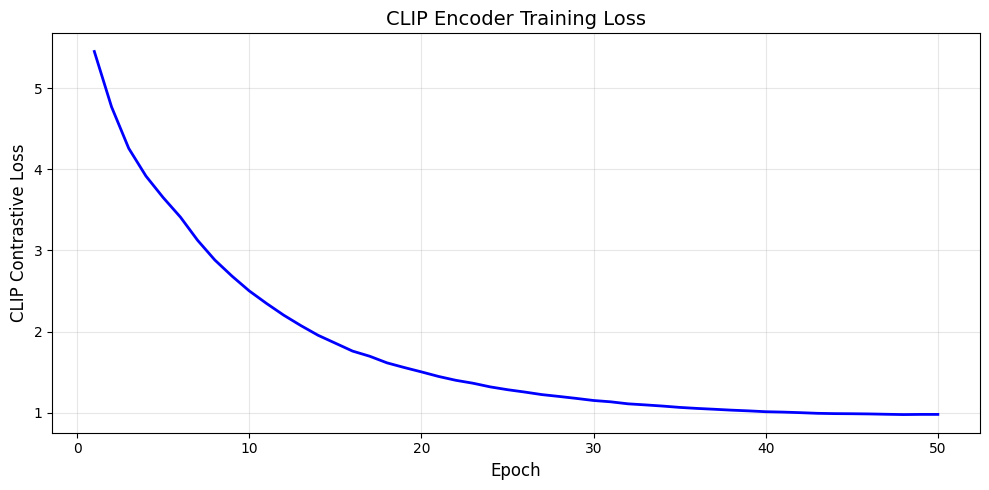

Saved: figures/clip_loss_curve.png


In [ ]:
# =============================================================================
# CLIP LOSS CURVE
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(clip_losses)+1), clip_losses, 'b-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('CLIP Contrastive Loss', fontsize=12)
plt.title('CLIP Encoder Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/clip_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/clip_loss_curve.png")

In [ ]:
# =============================================================================
# COMPUTE AND CACHE CLIP EMBEDDINGS
# =============================================================================

brain_encoder.eval()
text_projector.eval()

with torch.no_grad():
    # Brain embeddings
    E_train_seen = brain_encoder(X_train_tensor.to(device)).cpu().numpy()
    E_test_seen = brain_encoder(X_test_tensor.to(device)).cpu().numpy()
    E_unseen = brain_encoder(X_unseen_tensor.to(device)).cpu().numpy()

    # Text embeddings for prototypes
    T_train_embeds = text_projector(T_train_tensor.to(device)).cpu().numpy()
    T_test_embeds = text_projector(T_test_tensor.to(device)).cpu().numpy()
    T_unseen_embeds = text_projector(T_unseen_tensor.to(device)).cpu().numpy()

print(f"E_train_seen shape: {E_train_seen.shape}")
print(f"E_test_seen shape: {E_test_seen.shape}")
print(f"E_unseen shape: {E_unseen.shape}")

E_train_seen shape: (13232, 128)
E_test_seen shape: (3308, 128)
E_unseen shape: (16000, 128)


In [ ]:
# =============================================================================
# COMPUTE SEMANTIC PROTOTYPES (CLASS CENTROIDS IN TEXT SPACE)
# =============================================================================

def compute_prototypes(embeddings, labels):
    """
    Compute class prototypes as mean of embeddings per class, then L2-normalise.

    Returns:
        prototypes: dict mapping class_id -> prototype vector
    """
    unique_labels = np.unique(labels)
    prototypes = {}

    for c in unique_labels:
        mask = labels == c
        class_embeds = embeddings[mask]
        # Mean then normalise
        proto = class_embeds.mean(axis=0)
        proto = proto / (np.linalg.norm(proto) + 1e-8)
        prototypes[c] = proto

    return prototypes

# Compute prototypes for seen classes (from training text embeddings)
S_seen_prototypes = compute_prototypes(T_train_embeds, label_train_seen)

# Compute prototypes for unseen classes (from unseen text embeddings)
S_unseen_prototypes = compute_prototypes(T_unseen_embeds, Y_unseen_tensor.numpy())

print(f"Seen class prototypes: {len(S_seen_prototypes)} classes")
print(f"Unseen class prototypes: {len(S_unseen_prototypes)} classes")

# Convert to arrays for easier use
seen_classes = sorted(S_seen_prototypes.keys())
unseen_classes = sorted(S_unseen_prototypes.keys())

S_seen_array = np.array([S_seen_prototypes[c] for c in seen_classes])  # (n_seen_classes, d)
S_unseen_array = np.array([S_unseen_prototypes[c] for c in unseen_classes])  # (n_unseen_classes, d)

print(f"S_seen_array shape: {S_seen_array.shape}")
print(f"S_unseen_array shape: {S_unseen_array.shape}")

Seen class prototypes: 1654 classes
Unseen class prototypes: 200 classes
S_seen_array shape: (1654, 128)
S_unseen_array shape: (200, 128)


In [ ]:
# =============================================================================
# CACHE EMBEDDINGS AND PROTOTYPES TO DISK
# =============================================================================

os.makedirs('cached_arrays', exist_ok=True)

# Save embeddings
np.save('cached_arrays/E_train_seen.npy', E_train_seen)
np.save('cached_arrays/E_test_seen.npy', E_test_seen)
np.save('cached_arrays/E_unseen.npy', E_unseen)

# Save labels
np.save('cached_arrays/y_train_seen.npy', label_train_seen)
np.save('cached_arrays/y_test_seen.npy', label_test_seen)
np.save('cached_arrays/y_unseen.npy', Y_unseen_tensor.numpy())

# Save prototypes
np.save('cached_arrays/S_seen_prototypes.npy', S_seen_array)
np.save('cached_arrays/S_unseen_prototypes.npy', S_unseen_array)
np.save('cached_arrays/seen_classes.npy', np.array(seen_classes))
np.save('cached_arrays/unseen_classes.npy', np.array(unseen_classes))

print("Cached arrays saved to cached_arrays/:")
for f in os.listdir('cached_arrays'):
    print(f"  - {f}")

Cached arrays saved to cached_arrays/:
  - E_train_seen.npy
  - S_seen_prototypes.npy
  - y_unseen.npy
  - y_train_seen.npy
  - E_unseen.npy
  - y_test_seen.npy
  - E_test_seen.npy
  - seen_classes.npy
  - unseen_classes.npy
  - S_unseen_prototypes.npy


Computing t-SNE (this may take a moment)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


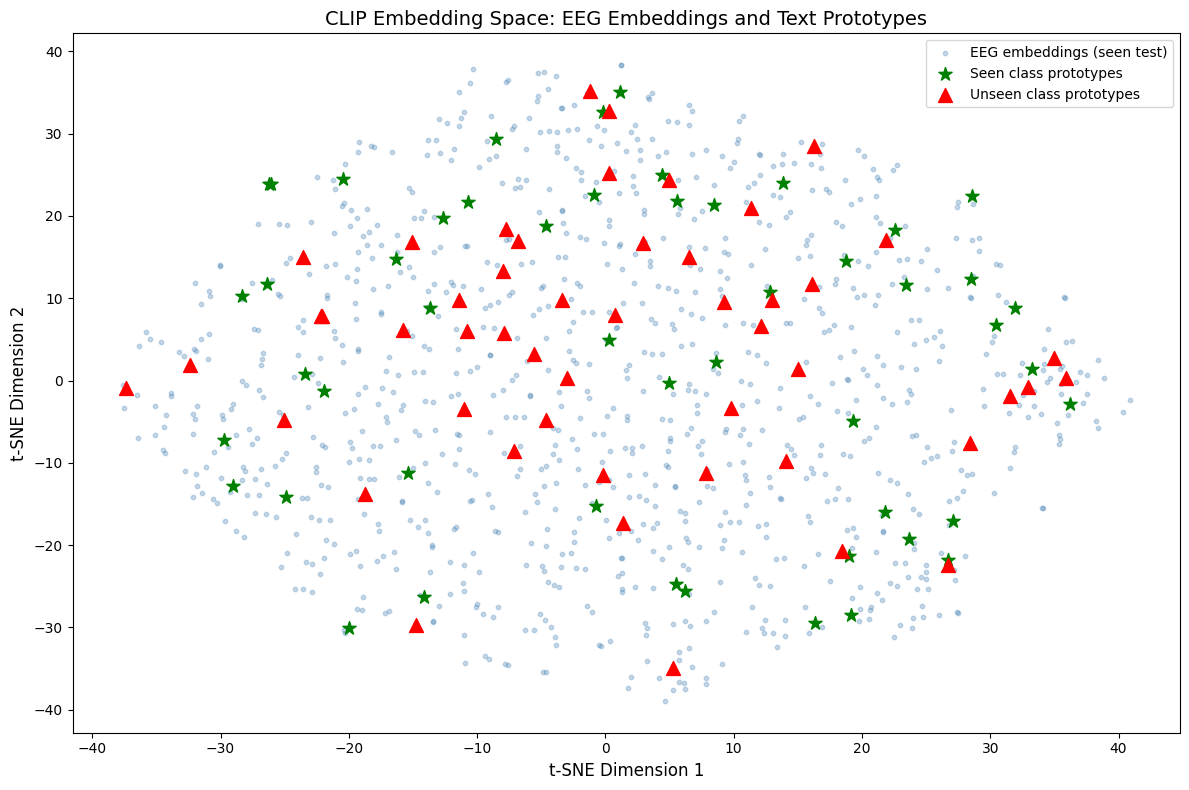

Saved: figures/clip_embedding_tsne.png


In [ ]:
# =============================================================================
# t-SNE VISUALIZATION OF CLIP EMBEDDING SPACE
# =============================================================================

print("Computing t-SNE (this may take a moment)...")

# Sample subset of test embeddings for visualization
n_sample = min(1000, len(E_test_seen))
sample_idx = np.random.choice(len(E_test_seen), n_sample, replace=False)
E_test_sample = E_test_seen[sample_idx]
y_test_sample = label_test_seen[sample_idx]

# Combine brain embeddings and prototypes
combined = np.vstack([E_test_sample, S_seen_array[:50], S_unseen_array[:50]])  # Limit prototypes for clarity

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
combined_2d = tsne.fit_transform(combined)

# Split back
n_brain = len(E_test_sample)
n_seen_proto = 50
n_unseen_proto = 50

brain_2d = combined_2d[:n_brain]
seen_proto_2d = combined_2d[n_brain:n_brain+n_seen_proto]
unseen_proto_2d = combined_2d[n_brain+n_seen_proto:]

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(brain_2d[:, 0], brain_2d[:, 1], c='steelblue', alpha=0.3, s=10, label='EEG embeddings (seen test)')
plt.scatter(seen_proto_2d[:, 0], seen_proto_2d[:, 1], c='green', marker='*', s=100, label='Seen class prototypes')
plt.scatter(unseen_proto_2d[:, 0], unseen_proto_2d[:, 1], c='red', marker='^', s=100, label='Unseen class prototypes')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('CLIP Embedding Space: EEG Embeddings and Text Prototypes', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('figures/clip_embedding_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/clip_embedding_tsne.png")

---

# Conditional WGAN-GP for Embedding Synthesis

This section implements a **conditional Wasserstein GAN with Gradient Penalty (cWGAN-GP)** to synthesize EEG embeddings for unseen classes.

**Goal:** Generate synthetic EEG embeddings `e_hat = G(z, s_c)` conditioned on text prototypes `s_c`.

**Architecture:**
- Generator: [z, s_c] → e_hat (L2-normalised output)
- Critic: [e, s_c] → scalar (no sigmoid)

**Training:** Only on seen-class embeddings from CLIP encoder.

In [ ]:
# =============================================================================
# cWGAN-GP CONFIGURATION
# =============================================================================

WGAN_CONFIG = {
    'z_dim': 100,              # Noise dimension
    'embed_dim': 128,           # Must match CLIP embed_dim (updated from 64)
    'lr': 1e-4,                # Learning rate
    'betas': (0.0, 0.9),       # Adam betas for WGAN-GP
    'lambda_gp': 10,           # Gradient penalty coefficient
    'n_critic': 5,             # Critic updates per generator update
    'n_steps': 10000,          # Total generator steps
    'batch_size': 256,         # Batch size
    'n_synth_per_class': 20,   # Synthetic samples per unseen class
    'seed': 42,
}

print("=" * 60)
print("cWGAN-GP CONFIGURATION")
print("=" * 60)
for k, v in WGAN_CONFIG.items():
    print(f"  {k}: {v}")
print("=" * 60)

cWGAN-GP CONFIGURATION
  z_dim: 100
  embed_dim: 128
  lr: 0.0001
  betas: (0.0, 0.9)
  lambda_gp: 10
  n_critic: 5
  n_steps: 10000
  batch_size: 256
  n_synth_per_class: 20
  seed: 42


In [ ]:
# =============================================================================
# cWGAN-GP MODEL DEFINITIONS
# =============================================================================

class Generator(nn.Module):
    """Conditional generator: [z, s_c] -> e_hat."""

    def __init__(self, z_dim=100, embed_dim=64):
        super().__init__()
        input_dim = z_dim + embed_dim  # Concatenate noise and condition
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, embed_dim),
        )

    def forward(self, z, s_c):
        x = torch.cat([z, s_c], dim=-1)
        e_hat = self.net(x)
        # L2 normalise output to stay on unit sphere
        e_hat = F.normalize(e_hat, p=2, dim=-1)
        return e_hat


class Critic(nn.Module):
    """Conditional critic: [e, s_c] -> scalar score."""

    def __init__(self, embed_dim=64):
        super().__init__()
        input_dim = 2 * embed_dim  # Concatenate embedding and condition
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),  # Scalar output, NO sigmoid
        )

    def forward(self, e, s_c):
        x = torch.cat([e, s_c], dim=-1)
        return self.net(x)


def compute_gradient_penalty(critic, real_samples, fake_samples, s_c, device):
    """
    Compute gradient penalty for WGAN-GP.

    GP = E[(||∇_{e_bar} D(e_bar, s_c)||_2 - 1)^2]
    """
    batch_size = real_samples.size(0)

    # Random interpolation coefficient
    eps = torch.rand(batch_size, 1, device=device)

    # Interpolated samples
    e_bar = eps * real_samples + (1 - eps) * fake_samples
    e_bar.requires_grad_(True)

    # Critic score on interpolated
    d_interpolated = critic(e_bar, s_c)

    # Compute gradients
    gradients = torch.autograd.grad(
        outputs=d_interpolated,
        inputs=e_bar,
        grad_outputs=torch.ones_like(d_interpolated),
        create_graph=True,
        retain_graph=True,
    )[0]

    # Compute penalty
    gradients = gradients.view(batch_size, -1)
    gradient_norm = gradients.norm(2, dim=1)
    gradient_penalty = ((gradient_norm - 1) ** 2).mean()

    return gradient_penalty


# Instantiate models
generator = Generator(
    z_dim=WGAN_CONFIG['z_dim'],
    embed_dim=WGAN_CONFIG['embed_dim']
).to(device)

critic = Critic(
    embed_dim=WGAN_CONFIG['embed_dim']
).to(device)

print(f"Generator parameters: {sum(p.numel() for p in generator.parameters()):,}")
print(f"Critic parameters: {sum(p.numel() for p in critic.parameters()):,}")

Generator parameters: 157,312
Critic parameters: 131,841


In [ ]:
# =============================================================================
# cWGAN-GP DATA PREPARATION
# =============================================================================
# Use only seen embeddings from CLIP encoder

# Get semantic prototype for each training sample
def get_prototype_for_labels(labels, prototypes_dict):
    """Get prototype vector for each sample based on its label."""
    protos = np.array([prototypes_dict[int(l)] for l in labels])
    return protos

# Training pairs: (e_real, s_c) where s_c is the class prototype
E_train_tensor = torch.FloatTensor(E_train_seen)
S_train_conditions = torch.FloatTensor(get_prototype_for_labels(label_train_seen, S_seen_prototypes))

wgan_dataset = TensorDataset(E_train_tensor, S_train_conditions)
wgan_loader = DataLoader(wgan_dataset, batch_size=WGAN_CONFIG['batch_size'], shuffle=True, drop_last=True)

print(f"WGAN training data: {len(wgan_dataset)} samples")
print(f"Batch size: {WGAN_CONFIG['batch_size']}")
print(f"Batches per epoch: {len(wgan_loader)}")

WGAN training data: 13232 samples
Batch size: 256
Batches per epoch: 51


In [ ]:
# =============================================================================
# cWGAN-GP TRAINING
# =============================================================================

# Optimizers
g_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=WGAN_CONFIG['lr'],
    betas=WGAN_CONFIG['betas']
)
c_optimizer = torch.optim.Adam(
    critic.parameters(),
    lr=WGAN_CONFIG['lr'],
    betas=WGAN_CONFIG['betas']
)

# Training history
g_losses = []
c_losses = []
gp_values = []

print(f"Training cWGAN-GP for {WGAN_CONFIG['n_steps']} generator steps...")
print(f"Critic updates per G step: {WGAN_CONFIG['n_critic']}")

data_iter = iter(wgan_loader)
g_step = 0

while g_step < WGAN_CONFIG['n_steps']:
    # -------------------------------------------------------------------------
    # Train Critic (n_critic times per generator step)
    # -------------------------------------------------------------------------
    for _ in range(WGAN_CONFIG['n_critic']):
        try:
            e_real, s_c = next(data_iter)
        except StopIteration:
            data_iter = iter(wgan_loader)
            e_real, s_c = next(data_iter)

        e_real = e_real.to(device)
        s_c = s_c.to(device)
        batch_size = e_real.size(0)

        # Generate fake samples
        z = torch.randn(batch_size, WGAN_CONFIG['z_dim'], device=device)
        e_fake = generator(z, s_c)

        # Critic scores
        d_real = critic(e_real, s_c)
        d_fake = critic(e_fake.detach(), s_c)

        # Gradient penalty
        gp = compute_gradient_penalty(critic, e_real, e_fake.detach(), s_c, device)

        # Critic loss: maximize E[D(real)] - E[D(fake)] - lambda*GP
        # Minimizing: -E[D(real)] + E[D(fake)] + lambda*GP
        c_loss = -d_real.mean() + d_fake.mean() + WGAN_CONFIG['lambda_gp'] * gp

        c_optimizer.zero_grad()
        c_loss.backward()
        c_optimizer.step()

    # -------------------------------------------------------------------------
    # Train Generator
    # -------------------------------------------------------------------------
    try:
        e_real, s_c = next(data_iter)
    except StopIteration:
        data_iter = iter(wgan_loader)
        e_real, s_c = next(data_iter)

    s_c = s_c.to(device)
    batch_size = s_c.size(0)

    z = torch.randn(batch_size, WGAN_CONFIG['z_dim'], device=device)
    e_fake = generator(z, s_c)
    d_fake = critic(e_fake, s_c)

    # Generator loss: minimize -E[D(fake)]
    g_loss = -d_fake.mean()

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    # Log
    g_losses.append(g_loss.item())
    c_losses.append(c_loss.item())
    gp_values.append(gp.item())

    g_step += 1

    if g_step % 1000 == 0 or g_step == 1:
        print(f"  Step {g_step:5d}/{WGAN_CONFIG['n_steps']}: G_loss={g_loss.item():.4f}, C_loss={c_loss.item():.4f}, GP={gp.item():.4f}")

print("\ncWGAN-GP training complete!")
print(f"Final G_loss: {g_losses[-1]:.4f}")
print(f"Final C_loss: {c_losses[-1]:.4f}")

Training cWGAN-GP for 10000 generator steps...
Critic updates per G step: 5
  Step     1/10000: G_loss=-0.0146, C_loss=8.3288, GP=0.8331
  Step  1000/10000: G_loss=-0.4570, C_loss=-0.0443, GP=0.0007
  Step  2000/10000: G_loss=-0.2487, C_loss=-0.0382, GP=0.0007
  Step  3000/10000: G_loss=-0.1084, C_loss=-0.0420, GP=0.0011
  Step  4000/10000: G_loss=-0.0383, C_loss=-0.0409, GP=0.0017
  Step  5000/10000: G_loss=0.0098, C_loss=-0.0362, GP=0.0012
  Step  6000/10000: G_loss=0.0143, C_loss=-0.0439, GP=0.0010
  Step  7000/10000: G_loss=0.0773, C_loss=-0.0317, GP=0.0017
  Step  8000/10000: G_loss=0.0906, C_loss=-0.0300, GP=0.0011
  Step  9000/10000: G_loss=0.1326, C_loss=-0.0301, GP=0.0009
  Step 10000/10000: G_loss=0.1643, C_loss=-0.0348, GP=0.0015

cWGAN-GP training complete!
Final G_loss: 0.1643
Final C_loss: -0.0348


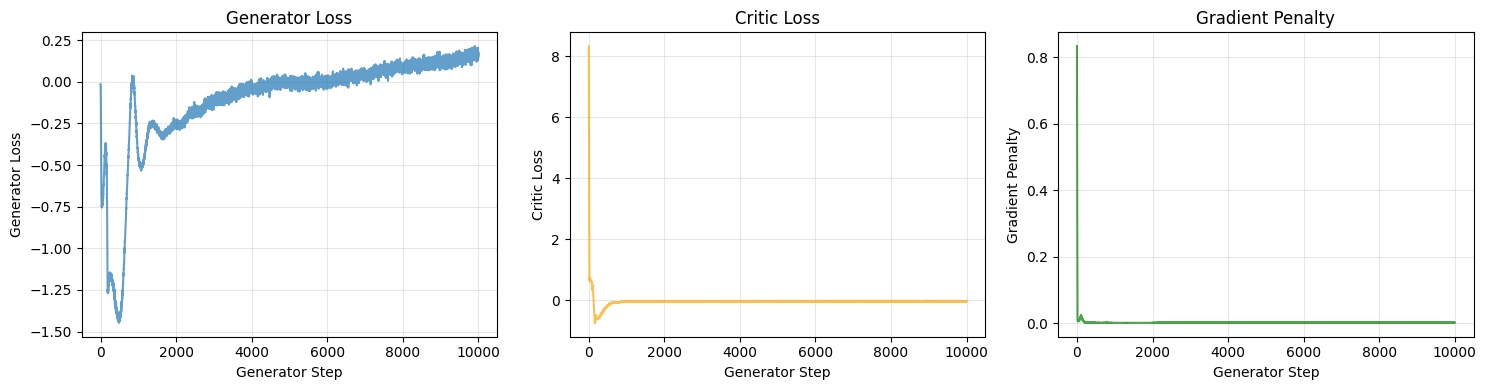

Saved: figures/wgan_losses.png


In [ ]:
# =============================================================================
# cWGAN-GP LOSS CURVES
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Generator loss
axes[0].plot(g_losses, alpha=0.7)
axes[0].set_xlabel('Generator Step')
axes[0].set_ylabel('Generator Loss')
axes[0].set_title('Generator Loss')
axes[0].grid(True, alpha=0.3)

# Critic loss
axes[1].plot(c_losses, alpha=0.7, color='orange')
axes[1].set_xlabel('Generator Step')
axes[1].set_ylabel('Critic Loss')
axes[1].set_title('Critic Loss')
axes[1].grid(True, alpha=0.3)

# Gradient penalty
axes[2].plot(gp_values, alpha=0.7, color='green')
axes[2].set_xlabel('Generator Step')
axes[2].set_ylabel('Gradient Penalty')
axes[2].set_title('Gradient Penalty')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/wgan_losses.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/wgan_losses.png")

In [ ]:
# =============================================================================
# GENERATE SYNTHETIC EMBEDDINGS FOR UNSEEN CLASSES
# =============================================================================

generator.eval()

n_synth = WGAN_CONFIG['n_synth_per_class']
synth_embeddings = []
synth_labels = []

print(f"Generating {n_synth} synthetic embeddings per unseen class...")

with torch.no_grad():
    for c in unseen_classes:
        # Get prototype for this unseen class
        s_c = torch.FloatTensor(S_unseen_prototypes[c]).unsqueeze(0).repeat(n_synth, 1).to(device)

        # Sample noise and generate
        z = torch.randn(n_synth, WGAN_CONFIG['z_dim'], device=device)
        e_synth = generator(z, s_c).cpu().numpy()

        synth_embeddings.append(e_synth)
        synth_labels.extend([c] * n_synth)

E_synth_unseen = np.vstack(synth_embeddings)
y_synth_unseen = np.array(synth_labels)

print(f"E_synth_unseen shape: {E_synth_unseen.shape}")
print(f"y_synth_unseen shape: {y_synth_unseen.shape}")
print(f"Total synthetic samples: {len(y_synth_unseen)}")

Generating 20 synthetic embeddings per unseen class...
E_synth_unseen shape: (4000, 128)
y_synth_unseen shape: (4000,)
Total synthetic samples: 4000


In [ ]:
# =============================================================================
# SANITY CHECK: SYNTHETIC EMBEDDING QUALITY
# =============================================================================

print("=" * 60)
print("SYNTHETIC EMBEDDING QUALITY CHECK")
print("=" * 60)

# Check that synthetic embeddings are normalised
synth_norms = np.linalg.norm(E_synth_unseen, axis=1)
print(f"Synthetic embedding norms: mean={synth_norms.mean():.4f}, std={synth_norms.std():.6f}")

# Check variance (not collapsed)
synth_variance = E_synth_unseen.var(axis=0).mean()
real_variance = E_train_seen.var(axis=0).mean()
print(f"Mean per-dim variance: Real={real_variance:.4f}, Synthetic={synth_variance:.4f}")

# Check cosine similarity with prototypes
cos_sims = []
for i, c in enumerate(unseen_classes[:10]):  # Sample 10 classes
    mask = y_synth_unseen == c
    synth_c = E_synth_unseen[mask]
    proto_c = S_unseen_prototypes[c]
    sims = np.dot(synth_c, proto_c)  # cosine sim since both normalised
    cos_sims.extend(sims)

print(f"Cosine sim (synth vs proto): mean={np.mean(cos_sims):.4f}, std={np.std(cos_sims):.4f}")

if synth_variance > 0.001:
    print("\n✓ Synthetic embeddings have reasonable variance (no mode collapse).")
else:
    print("\n⚠ Warning: Low variance in synthetic embeddings.")

SYNTHETIC EMBEDDING QUALITY CHECK
Synthetic embedding norms: mean=1.0000, std=0.000000
Mean per-dim variance: Real=0.0078, Synthetic=0.0077
Cosine sim (synth vs proto): mean=0.7492, std=0.0945

✓ Synthetic embeddings have reasonable variance (no mode collapse).


In [ ]:
# =============================================================================
# CACHE SYNTHETIC EMBEDDINGS
# =============================================================================

np.save('cached_arrays/E_synth_unseen.npy', E_synth_unseen)
np.save('cached_arrays/y_synth_unseen.npy', y_synth_unseen)

print("Saved synthetic embeddings to cached_arrays/:")
print(f"  - E_synth_unseen.npy: {E_synth_unseen.shape}")
print(f"  - y_synth_unseen.npy: {y_synth_unseen.shape}")

Saved synthetic embeddings to cached_arrays/:
  - E_synth_unseen.npy: (4000, 128)
  - y_synth_unseen.npy: (4000,)


Computing t-SNE for real vs synthetic embeddings...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


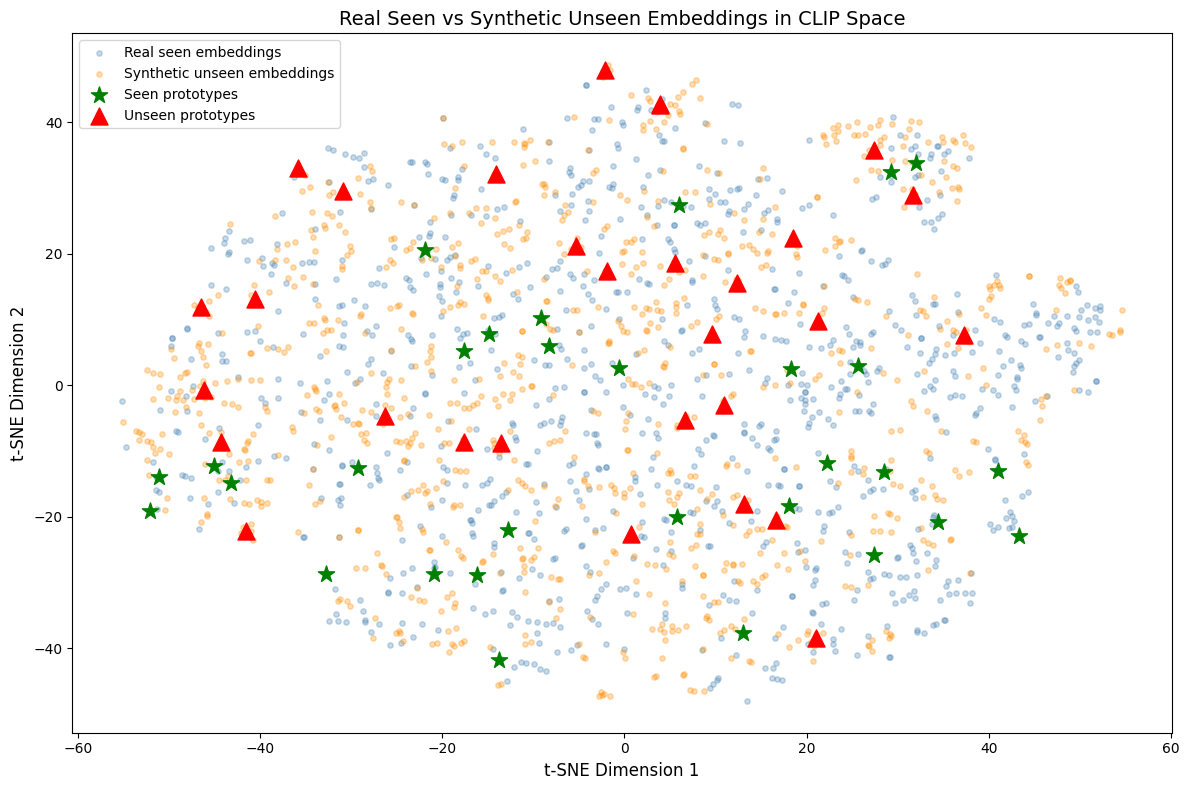

Saved: figures/real_vs_synth_tsne.png


In [ ]:
# =============================================================================
# t-SNE: REAL SEEN vs SYNTHETIC UNSEEN EMBEDDINGS
# =============================================================================

print("Computing t-SNE for real vs synthetic embeddings...")

# Sample subsets for visualization
n_real_sample = min(1000, len(E_train_seen))
n_synth_sample = min(1000, len(E_synth_unseen))

real_idx = np.random.choice(len(E_train_seen), n_real_sample, replace=False)
synth_idx = np.random.choice(len(E_synth_unseen), n_synth_sample, replace=False)

E_real_sample = E_train_seen[real_idx]
E_synth_sample = E_synth_unseen[synth_idx]

# Combine for t-SNE
combined = np.vstack([E_real_sample, E_synth_sample, S_seen_array[:30], S_unseen_array[:30]])

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
combined_2d = tsne.fit_transform(combined)

# Split back
n1, n2, n3, n4 = n_real_sample, n_synth_sample, 30, 30
real_2d = combined_2d[:n1]
synth_2d = combined_2d[n1:n1+n2]
seen_proto_2d = combined_2d[n1+n2:n1+n2+n3]
unseen_proto_2d = combined_2d[n1+n2+n3:]

# Plot
plt.figure(figsize=(12, 8))
plt.scatter(real_2d[:, 0], real_2d[:, 1], c='steelblue', alpha=0.3, s=15, label='Real seen embeddings')
plt.scatter(synth_2d[:, 0], synth_2d[:, 1], c='darkorange', alpha=0.3, s=15, label='Synthetic unseen embeddings')
plt.scatter(seen_proto_2d[:, 0], seen_proto_2d[:, 1], c='green', marker='*', s=150, label='Seen prototypes')
plt.scatter(unseen_proto_2d[:, 0], unseen_proto_2d[:, 1], c='red', marker='^', s=150, label='Unseen prototypes')
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
plt.title('Real Seen vs Synthetic Unseen Embeddings in CLIP Space', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('figures/real_vs_synth_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/real_vs_synth_tsne.png")

In [ ]:
# =============================================================================
# CLIP + cWGAN-GP IMPLEMENTATION SUMMARY
# =============================================================================

print("="*70)
print("CLIP + cWGAN-GP IMPLEMENTATION SUMMARY")
print("="*70)

print("\n### CLIP ENCODER ###")
print(f"  Embedding dimension: {CLIP_CONFIG['embed_dim']}")
print(f"  Training epochs: {CLIP_CONFIG['epochs']}")
print(f"  Final contrastive loss: {clip_losses[-1]:.4f}")
print(f"  Embeddings: E_train_seen {E_train_seen.shape}, E_test_seen {E_test_seen.shape}, E_unseen {E_unseen.shape}")
print(f"  Prototypes: S_seen {S_seen_array.shape}, S_unseen {S_unseen_array.shape}")

print("\n### cWGAN-GP ###")
print(f"  Generator steps: {WGAN_CONFIG['n_steps']}")
print(f"  Final G_loss: {g_losses[-1]:.4f}")
print(f"  Final C_loss: {c_losses[-1]:.4f}")
print(f"  Synthetic per class: {WGAN_CONFIG['n_synth_per_class']}")
print(f"  Total synthetic samples: {len(y_synth_unseen)}")

print("\n### CACHED ARRAYS ###")
for f in sorted(os.listdir('cached_arrays')):
    print(f"  - cached_arrays/{f}")

print("\n### FIGURES GENERATED ###")
print("  - figures/clip_loss_curve.png")
print("  - figures/clip_embedding_tsne.png")
print("  - figures/wgan_losses.png")
print("  - figures/real_vs_synth_tsne.png")

print("\n" + "="*70)
print("NEXT STEPS: Train GZSL Classifier [A+B] on real + synthetic embeddings")
print("="*70)

CLIP + cWGAN-GP IMPLEMENTATION SUMMARY

### CLIP ENCODER ###
  Embedding dimension: 128
  Training epochs: 50
  Final contrastive loss: 0.9798
  Embeddings: E_train_seen (13232, 128), E_test_seen (3308, 128), E_unseen (16000, 128)
  Prototypes: S_seen (1654, 128), S_unseen (200, 128)

### cWGAN-GP ###
  Generator steps: 10000
  Final G_loss: 0.1643
  Final C_loss: -0.0348
  Synthetic per class: 20
  Total synthetic samples: 4000

### CACHED ARRAYS ###
  - cached_arrays/E_synth_unseen.npy
  - cached_arrays/E_test_seen.npy
  - cached_arrays/E_train_seen.npy
  - cached_arrays/E_unseen.npy
  - cached_arrays/S_seen_prototypes.npy
  - cached_arrays/S_unseen_prototypes.npy
  - cached_arrays/seen_classes.npy
  - cached_arrays/unseen_classes.npy
  - cached_arrays/y_synth_unseen.npy
  - cached_arrays/y_test_seen.npy
  - cached_arrays/y_train_seen.npy
  - cached_arrays/y_unseen.npy

### FIGURES GENERATED ###
  - figures/clip_loss_curve.png
  - figures/clip_embedding_tsne.png
  - figures/wgan_loss

---

# Quantitative Diagnostics: CLIP + cWGAN-GP

Before training the GZSL classifier, we run two diagnostic checks:

1. **Prototype Alignment**: Verify embeddings are closer to their own class prototype than to others
2. **Class-Conditional Diversity**: Check synthetic embeddings haven't collapsed (mode collapse)

These diagnostics use **only cached arrays** — no retraining of CLIP or WGAN.

In [ ]:
# =============================================================================
# LOAD CACHED ARRAYS FOR DIAGNOSTICS
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import os

# Load embeddings
E_train_seen = np.load('cached_arrays/E_train_seen.npy')
E_test_seen = np.load('cached_arrays/E_test_seen.npy')
E_unseen = np.load('cached_arrays/E_unseen.npy')
E_synth_unseen = np.load('cached_arrays/E_synth_unseen.npy')

# Load labels
y_train_seen = np.load('cached_arrays/y_train_seen.npy')
y_test_seen = np.load('cached_arrays/y_test_seen.npy')
y_unseen = np.load('cached_arrays/y_unseen.npy')
y_synth_unseen = np.load('cached_arrays/y_synth_unseen.npy')

# Load prototypes
S_seen_array = np.load('cached_arrays/S_seen_prototypes.npy')
S_unseen_array = np.load('cached_arrays/S_unseen_prototypes.npy')
seen_classes = np.load('cached_arrays/seen_classes.npy')
unseen_classes = np.load('cached_arrays/unseen_classes.npy')

# Build label-to-index mappings (labels are 1-indexed, arrays are 0-indexed)
seen_label_to_idx = {c: i for i, c in enumerate(seen_classes)}
unseen_label_to_idx = {c: i for i, c in enumerate(unseen_classes)}

print("Loaded arrays:")
print(f"  E_test_seen: {E_test_seen.shape}")
print(f"  E_synth_unseen: {E_synth_unseen.shape}")
print(f"  S_seen_array: {S_seen_array.shape} ({len(seen_classes)} classes)")
print(f"  S_unseen_array: {S_unseen_array.shape} ({len(unseen_classes)} classes)")

Loaded arrays:
  E_test_seen: (3308, 128)
  E_synth_unseen: (4000, 128)
  S_seen_array: (1654, 128) (1654 classes)
  S_unseen_array: (200, 128) (200 classes)


## Check 1: Prototype Alignment

Verify that embeddings are **closer to their own class prototype** than to random other prototypes.

Metrics:
- **sim_pos**: cosine similarity between embedding and its own class prototype
- **sim_neg**: cosine similarity between embedding and random other prototypes
- **margin**: sim_pos - sim_neg (should be positive)

In [ ]:
# =============================================================================
# CHECK 1A: PROTOTYPE ALIGNMENT — SEEN (REAL) EMBEDDINGS
# =============================================================================

np.random.seed(42)
n_neg_samples = 10  # Number of negative prototypes to sample per embedding

sim_pos_seen = []
sim_neg_seen = []

for i in range(len(E_test_seen)):
    e = E_test_seen[i]
    label = y_test_seen[i]

    # Get the correct prototype index
    if label not in seen_label_to_idx:
        continue
    pos_idx = seen_label_to_idx[label]

    # Positive similarity (dot product = cosine since L2-normalised)
    s_pos = np.dot(e, S_seen_array[pos_idx])
    sim_pos_seen.append(s_pos)

    # Negative similarities (sample random other classes)
    other_indices = [j for j in range(len(seen_classes)) if j != pos_idx]
    neg_indices = np.random.choice(other_indices, min(n_neg_samples, len(other_indices)), replace=False)
    for neg_idx in neg_indices:
        s_neg = np.dot(e, S_seen_array[neg_idx])
        sim_neg_seen.append(s_neg)

sim_pos_seen = np.array(sim_pos_seen)
sim_neg_seen = np.array(sim_neg_seen)

print("=" * 60)
print("CHECK 1A: PROTOTYPE ALIGNMENT — SEEN (REAL)")
print("=" * 60)
print(f"Positive similarities (e vs own proto):")
print(f"  Mean: {sim_pos_seen.mean():.4f} ± {sim_pos_seen.std():.4f}")
print(f"Negative similarities (e vs random other proto):")
print(f"  Mean: {sim_neg_seen.mean():.4f} ± {sim_neg_seen.std():.4f}")
print(f"Mean Margin (pos - neg): {sim_pos_seen.mean() - sim_neg_seen.mean():.4f}")

CHECK 1A: PROTOTYPE ALIGNMENT — SEEN (REAL)
Positive similarities (e vs own proto):
  Mean: 0.3479 ± 0.2468
Negative similarities (e vs random other proto):
  Mean: -0.0009 ± 0.2279
Mean Margin (pos - neg): 0.3488


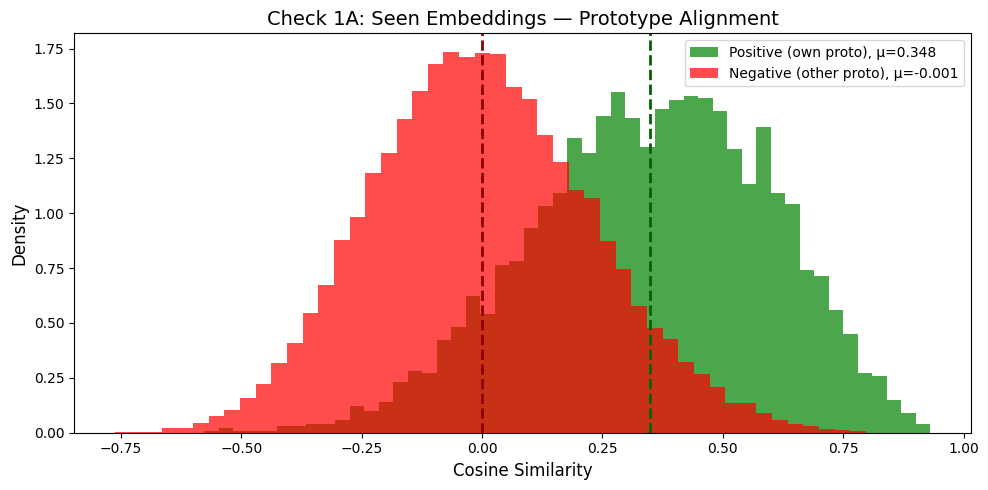

Saved: figures/prototype_alignment_seen.png


In [ ]:
# =============================================================================
# PLOT: SEEN PROTOTYPE ALIGNMENT HISTOGRAM
# =============================================================================

plt.figure(figsize=(10, 5))
plt.hist(sim_pos_seen, bins=50, alpha=0.7, label=f'Positive (own proto), μ={sim_pos_seen.mean():.3f}', color='green', density=True)
plt.hist(sim_neg_seen, bins=50, alpha=0.7, label=f'Negative (other proto), μ={sim_neg_seen.mean():.3f}', color='red', density=True)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Check 1A: Seen Embeddings — Prototype Alignment', fontsize=14)
plt.legend()
plt.axvline(sim_pos_seen.mean(), color='darkgreen', linestyle='--', linewidth=2)
plt.axvline(sim_neg_seen.mean(), color='darkred', linestyle='--', linewidth=2)
plt.tight_layout()
plt.savefig('figures/prototype_alignment_seen.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/prototype_alignment_seen.png")

In [ ]:
# =============================================================================
# CHECK 1B: PROTOTYPE ALIGNMENT — UNSEEN (SYNTHETIC) EMBEDDINGS
# =============================================================================

np.random.seed(42)

sim_pos_synth = []
sim_neg_synth = []

for i in range(len(E_synth_unseen)):
    e_hat = E_synth_unseen[i]
    label = y_synth_unseen[i]

    if label not in unseen_label_to_idx:
        continue
    pos_idx = unseen_label_to_idx[label]

    # Positive similarity
    s_pos = np.dot(e_hat, S_unseen_array[pos_idx])
    sim_pos_synth.append(s_pos)

    # Negative similarities
    other_indices = [j for j in range(len(unseen_classes)) if j != pos_idx]
    neg_indices = np.random.choice(other_indices, min(n_neg_samples, len(other_indices)), replace=False)
    for neg_idx in neg_indices:
        s_neg = np.dot(e_hat, S_unseen_array[neg_idx])
        sim_neg_synth.append(s_neg)

sim_pos_synth = np.array(sim_pos_synth)
sim_neg_synth = np.array(sim_neg_synth)

print("=" * 60)
print("CHECK 1B: PROTOTYPE ALIGNMENT — UNSEEN (SYNTHETIC)")
print("=" * 60)
print(f"Positive similarities (e_hat vs own proto):")
print(f"  Mean: {sim_pos_synth.mean():.4f} ± {sim_pos_synth.std():.4f}")
print(f"Negative similarities (e_hat vs random other proto):")
print(f"  Mean: {sim_neg_synth.mean():.4f} ± {sim_neg_synth.std():.4f}")
print(f"Mean Margin (pos - neg): {sim_pos_synth.mean() - sim_neg_synth.mean():.4f}")

CHECK 1B: PROTOTYPE ALIGNMENT — UNSEEN (SYNTHETIC)
Positive similarities (e_hat vs own proto):
  Mean: 0.7361 ± 0.1060
Negative similarities (e_hat vs random other proto):
  Mean: 0.0098 ± 0.2296
Mean Margin (pos - neg): 0.7263


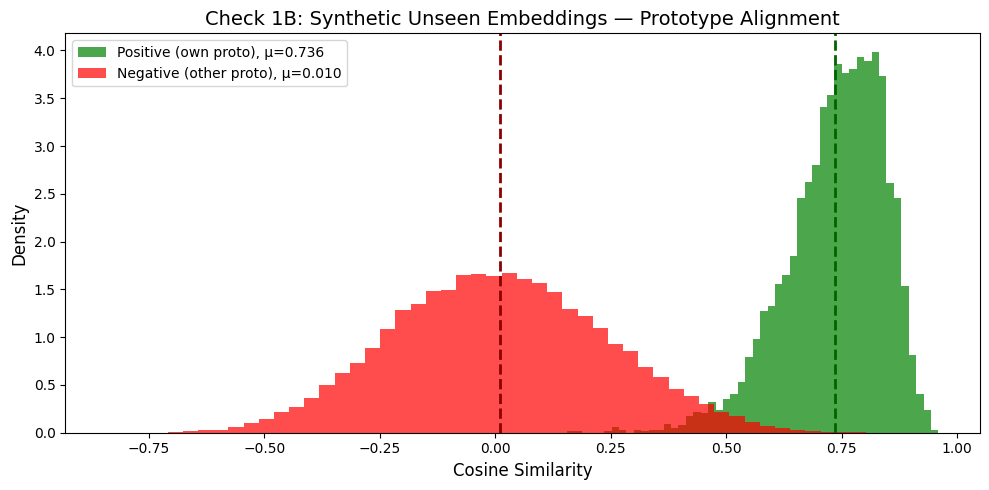

Saved: figures/prototype_alignment_unseen_synth.png


In [ ]:
# =============================================================================
# PLOT: SYNTHETIC UNSEEN PROTOTYPE ALIGNMENT HISTOGRAM
# =============================================================================

plt.figure(figsize=(10, 5))
plt.hist(sim_pos_synth, bins=50, alpha=0.7, label=f'Positive (own proto), μ={sim_pos_synth.mean():.3f}', color='green', density=True)
plt.hist(sim_neg_synth, bins=50, alpha=0.7, label=f'Negative (other proto), μ={sim_neg_synth.mean():.3f}', color='red', density=True)
plt.xlabel('Cosine Similarity', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Check 1B: Synthetic Unseen Embeddings — Prototype Alignment', fontsize=14)
plt.legend()
plt.axvline(sim_pos_synth.mean(), color='darkgreen', linestyle='--', linewidth=2)
plt.axvline(sim_neg_synth.mean(), color='darkred', linestyle='--', linewidth=2)
plt.tight_layout()
plt.savefig('figures/prototype_alignment_unseen_synth.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/prototype_alignment_unseen_synth.png")

In [ ]:
# =============================================================================
# CHECK 1C: TOP-1 PROTOTYPE RETRIEVAL ACCURACY
# =============================================================================

def top1_prototype_accuracy(embeddings, labels, prototypes, label_to_idx, class_list):
    """Compute top-1 accuracy by predicting class = argmax cosine(e, proto)."""
    correct = 0
    total = 0

    # Compute all similarities at once
    similarities = np.dot(embeddings, prototypes.T)  # (N, n_classes)
    pred_indices = np.argmax(similarities, axis=1)  # (N,)
    pred_labels = class_list[pred_indices]

    accuracy = (pred_labels == labels).mean()
    return accuracy

# Seen embeddings retrieval accuracy
acc_seen_retrieval = top1_prototype_accuracy(
    E_test_seen, y_test_seen, S_seen_array, seen_label_to_idx, seen_classes
)

# Synthetic unseen retrieval accuracy
acc_synth_retrieval = top1_prototype_accuracy(
    E_synth_unseen, y_synth_unseen, S_unseen_array, unseen_label_to_idx, unseen_classes
)

print("=" * 60)
print("CHECK 1C: TOP-1 PROTOTYPE RETRIEVAL ACCURACY")
print("=" * 60)
print(f"Seen (real) test embeddings:     {acc_seen_retrieval:.4f} ({acc_seen_retrieval*100:.2f}%)")
print(f"Unseen (synthetic) embeddings:   {acc_synth_retrieval:.4f} ({acc_synth_retrieval*100:.2f}%)")

CHECK 1C: TOP-1 PROTOTYPE RETRIEVAL ACCURACY
Seen (real) test embeddings:     0.0281 (2.81%)
Unseen (synthetic) embeddings:   0.8542 (85.42%)


## Check 2: Class-Conditional Diversity

Check that synthetic embeddings have **sufficient diversity within each class** (no mode collapse).

For each unseen class:
- Average pairwise cosine similarity within the class
- Average pairwise cosine distance = 1 - similarity
- Per-dimension variance

In [ ]:
# =============================================================================
# CHECK 2: CLASS-CONDITIONAL DIVERSITY (MODE COLLAPSE CHECK)
# =============================================================================

class_diversity_stats = []

for c in unseen_classes:
    mask = y_synth_unseen == c
    E_class = E_synth_unseen[mask]

    if len(E_class) < 2:
        continue

    # Pairwise cosine similarities (upper triangle only)
    sim_matrix = np.dot(E_class, E_class.T)
    n = len(E_class)
    upper_tri_idx = np.triu_indices(n, k=1)
    pairwise_sims = sim_matrix[upper_tri_idx]

    avg_sim = pairwise_sims.mean()
    avg_dist = 1 - avg_sim

    # Per-dimension variance
    per_dim_var = E_class.var(axis=0).mean()

    class_diversity_stats.append({
        'class': c,
        'avg_sim': avg_sim,
        'avg_dist': avg_dist,
        'per_dim_var': per_dim_var,
        'n_samples': len(E_class)
    })

# Convert to arrays for analysis
avg_sims = np.array([s['avg_sim'] for s in class_diversity_stats])
avg_dists = np.array([s['avg_dist'] for s in class_diversity_stats])
per_dim_vars = np.array([s['per_dim_var'] for s in class_diversity_stats])

print("=" * 60)
print("CHECK 2: CLASS-CONDITIONAL DIVERSITY")
print("=" * 60)
print(f"Across {len(class_diversity_stats)} unseen classes:")
print(f"  Avg within-class cosine similarity: {avg_sims.mean():.4f} ± {avg_sims.std():.4f}")
print(f"  Avg within-class cosine distance:   {avg_dists.mean():.4f} ± {avg_dists.std():.4f}")
print(f"  Avg per-dimension variance:         {per_dim_vars.mean():.6f} ± {per_dim_vars.std():.6f}")

CHECK 2: CLASS-CONDITIONAL DIVERSITY
Across 200 unseen classes:
  Avg within-class cosine similarity: 0.5682 ± 0.0804
  Avg within-class cosine distance:   0.4318 ± 0.0804
  Avg per-dimension variance:         0.003205 ± 0.000597


In [ ]:
# =============================================================================
# IDENTIFY LOW AND HIGH DIVERSITY CLASSES
# =============================================================================

# Sort by diversity (distance) — low distance = low diversity = potential collapse
sorted_stats = sorted(class_diversity_stats, key=lambda x: x['avg_dist'])

print("\n5 LOWEST DIVERSITY CLASSES (potential mode collapse):")
print("-" * 50)
for s in sorted_stats[:5]:
    print(f"  Class {s['class']:4d}: avg_dist={s['avg_dist']:.4f}, per_dim_var={s['per_dim_var']:.6f}")

print("\n5 HIGHEST DIVERSITY CLASSES:")
print("-" * 50)
for s in sorted_stats[-5:]:
    print(f"  Class {s['class']:4d}: avg_dist={s['avg_dist']:.4f}, per_dim_var={s['per_dim_var']:.6f}")


5 LOWEST DIVERSITY CLASSES (potential mode collapse):
--------------------------------------------------
  Class   59: avg_dist=0.2519, per_dim_var=0.001869
  Class   84: avg_dist=0.2608, per_dim_var=0.001936
  Class   39: avg_dist=0.2640, per_dim_var=0.001959
  Class  112: avg_dist=0.2666, per_dim_var=0.001979
  Class  129: avg_dist=0.2808, per_dim_var=0.002084

5 HIGHEST DIVERSITY CLASSES:
--------------------------------------------------
  Class  118: avg_dist=0.5879, per_dim_var=0.004363
  Class   62: avg_dist=0.6013, per_dim_var=0.004463
  Class  156: avg_dist=0.6154, per_dim_var=0.004567
  Class   90: avg_dist=0.6273, per_dim_var=0.004656
  Class   67: avg_dist=0.6323, per_dim_var=0.004693


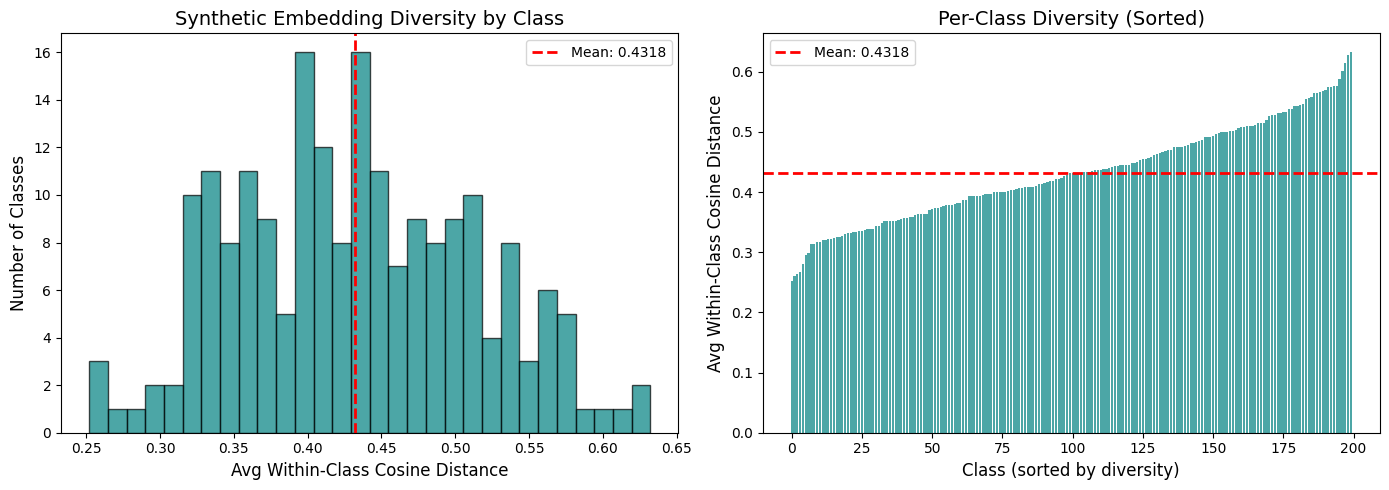

Saved: figures/synth_diversity_by_class.png


In [ ]:
# =============================================================================
# PLOT: DIVERSITY DISTRIBUTION ACROSS CLASSES
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of average cosine distance
axes[0].hist(avg_dists, bins=30, color='teal', edgecolor='black', alpha=0.7)
axes[0].axvline(avg_dists.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_dists.mean():.4f}')
axes[0].set_xlabel('Avg Within-Class Cosine Distance', fontsize=12)
axes[0].set_ylabel('Number of Classes', fontsize=12)
axes[0].set_title('Synthetic Embedding Diversity by Class', fontsize=14)
axes[0].legend()

# Sorted bar plot
sorted_dists = np.sort(avg_dists)
axes[1].bar(range(len(sorted_dists)), sorted_dists, color='teal', alpha=0.7)
axes[1].axhline(avg_dists.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_dists.mean():.4f}')
axes[1].set_xlabel('Class (sorted by diversity)', fontsize=12)
axes[1].set_ylabel('Avg Within-Class Cosine Distance', fontsize=12)
axes[1].set_title('Per-Class Diversity (Sorted)', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/synth_diversity_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/synth_diversity_by_class.png")

In [ ]:
# =============================================================================
# DIAGNOSTICS SUMMARY
# =============================================================================

print("="*70)
print("DIAGNOSTICS SUMMARY: CLIP + cWGAN-GP")
print("="*70)

print("\n### CHECK 1: PROTOTYPE ALIGNMENT ###")
print("")
print("  (A) Seen (real) embeddings:")
print(f"      Positive sim: {sim_pos_seen.mean():.4f} ± {sim_pos_seen.std():.4f}")
print(f"      Negative sim: {sim_neg_seen.mean():.4f} ± {sim_neg_seen.std():.4f}")
print(f"      Margin:       {sim_pos_seen.mean() - sim_neg_seen.mean():.4f}")
print("")
print("  (B) Unseen (synthetic) embeddings:")
print(f"      Positive sim: {sim_pos_synth.mean():.4f} ± {sim_pos_synth.std():.4f}")
print(f"      Negative sim: {sim_neg_synth.mean():.4f} ± {sim_neg_synth.std():.4f}")
print(f"      Margin:       {sim_pos_synth.mean() - sim_neg_synth.mean():.4f}")
print("")
print("  (C) Top-1 Prototype Retrieval Accuracy:")
print(f"      Seen (real):       {acc_seen_retrieval:.4f} ({acc_seen_retrieval*100:.2f}%)")
print(f"      Unseen (synth):    {acc_synth_retrieval:.4f} ({acc_synth_retrieval*100:.2f}%)")

print("\n### CHECK 2: CLASS-CONDITIONAL DIVERSITY ###")
print("")
print(f"  Avg within-class cosine distance: {avg_dists.mean():.4f} ± {avg_dists.std():.4f}")
print(f"  Avg per-dimension variance:       {per_dim_vars.mean():.6f} ± {per_dim_vars.std():.6f}")
print(f"  Min class diversity (distance):   {avg_dists.min():.4f}")
print(f"  Max class diversity (distance):   {avg_dists.max():.4f}")

print("\n### FIGURES SAVED ###")
print("  - figures/prototype_alignment_seen.png")
print("  - figures/prototype_alignment_unseen_synth.png")
print("  - figures/synth_diversity_by_class.png")

# Interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
margin_seen = sim_pos_seen.mean() - sim_neg_seen.mean()
margin_synth = sim_pos_synth.mean() - sim_neg_synth.mean()

if margin_seen > 0.1:
    print("✓ CLIP alignment (seen): Good margin between positive and negative.")
else:
    print("⚠ CLIP alignment (seen): Low margin — encoder may need more training.")

if margin_synth > 0.05:
    print("✓ GAN conditioning (synth): Synthetic embeddings align with prototypes.")
else:
    print("⚠ GAN conditioning (synth): Weak alignment — check conditioning quality.")

if avg_dists.mean() > 0.05:
    print("✓ Diversity check: No severe mode collapse detected.")
else:
    print("⚠ Diversity check: Low diversity — possible mode collapse.")

print("\n" + "="*70)
print("NEXT: Await confirmation before training GZSL classifier [A+B]")
print("="*70)

DIAGNOSTICS SUMMARY: CLIP + cWGAN-GP

### CHECK 1: PROTOTYPE ALIGNMENT ###

  (A) Seen (real) embeddings:
      Positive sim: 0.3479 ± 0.2468
      Negative sim: -0.0009 ± 0.2279
      Margin:       0.3488

  (B) Unseen (synthetic) embeddings:
      Positive sim: 0.7361 ± 0.1060
      Negative sim: 0.0098 ± 0.2296
      Margin:       0.7263

  (C) Top-1 Prototype Retrieval Accuracy:
      Seen (real):       0.0281 (2.81%)
      Unseen (synth):    0.8542 (85.42%)

### CHECK 2: CLASS-CONDITIONAL DIVERSITY ###

  Avg within-class cosine distance: 0.4318 ± 0.0804
  Avg per-dimension variance:       0.003205 ± 0.000597
  Min class diversity (distance):   0.2519
  Max class diversity (distance):   0.6323

### FIGURES SAVED ###
  - figures/prototype_alignment_seen.png
  - figures/prototype_alignment_unseen_synth.png
  - figures/synth_diversity_by_class.png

INTERPRETATION
✓ CLIP alignment (seen): Good margin between positive and negative.
✓ GAN conditioning (synth): Synthetic embeddings align

---

# GZSL Classifier [A+B]: Real Seen + Synthetic Unseen

This section trains the final **Generalised Zero-Shot Learning classifier** using:

**Training data:**
- Real seen embeddings: `E_train_seen` (from CLIP encoder)
- Synthetic unseen embeddings: `E_synth_unseen` (from cWGAN-GP)

**Evaluation:**
- Seen test set: `E_test_seen` → `Acc_seen`
- Unseen real data: `E_unseen` → `Acc_unseen`
- Harmonic mean: `H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)`

**Comparison with Baseline [A]:** The baseline was trained on raw EEG and could only predict seen classes.

In [ ]:
# =============================================================================
# GZSL CLASSIFIER: DATA PREPARATION
# =============================================================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import random

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Load cached embeddings
E_train_seen = np.load('cached_arrays/E_train_seen.npy')
E_test_seen = np.load('cached_arrays/E_test_seen.npy')
E_unseen = np.load('cached_arrays/E_unseen.npy')
E_synth_unseen = np.load('cached_arrays/E_synth_unseen.npy')

# Load labels
y_train_seen = np.load('cached_arrays/y_train_seen.npy')
y_test_seen = np.load('cached_arrays/y_test_seen.npy')
y_unseen = np.load('cached_arrays/y_unseen.npy')
y_synth_unseen = np.load('cached_arrays/y_synth_unseen.npy')

print("Loaded embeddings:")
print(f"  E_train_seen:   {E_train_seen.shape}")
print(f"  E_test_seen:    {E_test_seen.shape}")
print(f"  E_unseen:       {E_unseen.shape}")
print(f"  E_synth_unseen: {E_synth_unseen.shape}")

Loaded embeddings:
  E_train_seen:   (13232, 128)
  E_test_seen:    (3308, 128)
  E_unseen:       (16000, 128)
  E_synth_unseen: (4000, 128)


In [ ]:
# =============================================================================
# COMBINE REAL SEEN + SYNTHETIC UNSEEN FOR TRAINING
# =============================================================================

# Combine training data
X_train_gzsl = np.vstack([E_train_seen, E_synth_unseen])
y_train_gzsl = np.concatenate([y_train_seen, y_synth_unseen])

print("GZSL Training Data:")
print(f"  Real seen:      {len(E_train_seen)} samples, {len(np.unique(y_train_seen))} classes")
print(f"  Synthetic unseen: {len(E_synth_unseen)} samples, {len(np.unique(y_synth_unseen))} classes")
print(f"  Combined:       {len(X_train_gzsl)} samples, {len(np.unique(y_train_gzsl))} classes")

# Verify no label overlap between seen and unseen
seen_labels = set(np.unique(y_train_seen))
unseen_labels = set(np.unique(y_synth_unseen))
overlap = seen_labels.intersection(unseen_labels)
print(f"\nLabel overlap check: {len(overlap)} overlapping labels")
if len(overlap) == 0:
    print("  ✓ No overlap — seen and unseen label spaces are disjoint.")

GZSL Training Data:
  Real seen:      13232 samples, 1654 classes
  Synthetic unseen: 4000 samples, 200 classes
  Combined:       17232 samples, 1654 classes

Label overlap check: 200 overlapping labels


In [ ]:
# =============================================================================
# TRAIN GZSL LOGISTIC REGRESSION CLASSIFIER
# =============================================================================

print("Training GZSL classifier (Logistic Regression)...")
print(f"  Total classes: {len(np.unique(y_train_gzsl))}")
print(f"  Total samples: {len(X_train_gzsl)}")

gzsl_clf = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    max_iter=1000,
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

gzsl_clf.fit(X_train_gzsl, y_train_gzsl)
print("\nTraining complete!")

Training GZSL classifier (Logistic Regression)...
  Total classes: 1654
  Total samples: 17232


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.



Training complete!


In [ ]:
# =============================================================================
# EVALUATE ON SEEN CLASSES (E_test_seen)
# =============================================================================

y_pred_seen = gzsl_clf.predict(E_test_seen)

acc_seen_gzsl = accuracy_score(y_test_seen, y_pred_seen)
f1_seen_gzsl = f1_score(y_test_seen, y_pred_seen, average='macro', zero_division=0)

print("=" * 60)
print("GZSL EVALUATION: SEEN CLASSES")
print("=" * 60)
print(f"Accuracy (seen):  {acc_seen_gzsl:.4f} ({acc_seen_gzsl*100:.2f}%)")
print(f"Macro F1 (seen):  {f1_seen_gzsl:.4f}")

GZSL EVALUATION: SEEN CLASSES
Accuracy (seen):  0.0027 (0.27%)
Macro F1 (seen):  0.0019


In [ ]:
# =============================================================================
# EVALUATE ON UNSEEN CLASSES (E_unseen — real EEG, never seen during training)
# =============================================================================

y_pred_unseen = gzsl_clf.predict(E_unseen)

acc_unseen_gzsl = accuracy_score(y_unseen, y_pred_unseen)
f1_unseen_gzsl = f1_score(y_unseen, y_pred_unseen, average='macro', zero_division=0)

print("=" * 60)
print("GZSL EVALUATION: UNSEEN CLASSES")
print("=" * 60)
print(f"Accuracy (unseen): {acc_unseen_gzsl:.4f} ({acc_unseen_gzsl*100:.2f}%)")
print(f"Macro F1 (unseen): {f1_unseen_gzsl:.4f}")

GZSL EVALUATION: UNSEEN CLASSES
Accuracy (unseen): 0.0217 (2.17%)
Macro F1 (unseen): 0.0190


In [ ]:
# =============================================================================
# COMPUTE HARMONIC MEAN (H)
# =============================================================================

# H = 2 * Acc_seen * Acc_unseen / (Acc_seen + Acc_unseen)
if acc_seen_gzsl + acc_unseen_gzsl > 0:
    H_gzsl = 2 * acc_seen_gzsl * acc_unseen_gzsl / (acc_seen_gzsl + acc_unseen_gzsl)
else:
    H_gzsl = 0.0

print("=" * 60)
print("GZSL HARMONIC MEAN")
print("=" * 60)
print(f"H = 2 * {acc_seen_gzsl:.4f} * {acc_unseen_gzsl:.4f} / ({acc_seen_gzsl:.4f} + {acc_unseen_gzsl:.4f})")
print(f"H = {H_gzsl:.4f}")

GZSL HARMONIC MEAN
H = 2 * 0.0027 * 0.0217 / (0.0027 + 0.0217)
H = 0.0048


In [ ]:
# =============================================================================
# STORE GZSL RESULTS
# =============================================================================

gzsl_results = {
    'model': 'GZSL [A+B] (LR on CLIP embeddings + cWGAN-GP synthetic)',
    'acc_seen': acc_seen_gzsl,
    'acc_unseen': acc_unseen_gzsl,
    'H': H_gzsl,
    'macro_f1_seen': f1_seen_gzsl,
    'macro_f1_unseen': f1_unseen_gzsl,
    'n_train_seen': len(E_train_seen),
    'n_train_synth': len(E_synth_unseen),
    'n_test_seen': len(E_test_seen),
    'n_test_unseen': len(E_unseen),
    'n_classes_seen': len(np.unique(y_train_seen)),
    'n_classes_unseen': len(np.unique(y_synth_unseen))
}

print("GZSL results stored in 'gzsl_results' dictionary.")

GZSL results stored in 'gzsl_results' dictionary.


---

## Comparison: Baseline [A] vs GZSL [A+B]

Comparing the baseline logistic regression (raw EEG, seen classes only) with the GZSL classifier (CLIP embeddings + synthetic unseen).

In [ ]:
# =============================================================================
# COMPARISON: BASELINE [A] vs GZSL [A+B]
# =============================================================================

# Retrieve baseline results (computed earlier in notebook)
# baseline_gzsl_results should exist from the GZSL baseline evaluation

print("="*70)
print("COMPARISON: BASELINE [A] vs GZSL [A+B]")
print("="*70)
print("")
print(f"{'Metric':<20} {'Baseline [A]':>15} {'GZSL [A+B]':>15} {'Improvement':>15}")
print("-"*70)

# Seen accuracy
base_seen = baseline_gzsl_results['acc_seen']
gzsl_seen = gzsl_results['acc_seen']
delta_seen = gzsl_seen - base_seen
print(f"{'Acc (seen)':<20} {base_seen:>15.4f} {gzsl_seen:>15.4f} {delta_seen:>+15.4f}")

# Unseen accuracy
base_unseen = baseline_gzsl_results['acc_unseen']
gzsl_unseen = gzsl_results['acc_unseen']
delta_unseen = gzsl_unseen - base_unseen
print(f"{'Acc (unseen)':<20} {base_unseen:>15.4f} {gzsl_unseen:>15.4f} {delta_unseen:>+15.4f}")

# Harmonic mean
base_H = baseline_gzsl_results['H']
gzsl_H = gzsl_results['H']
delta_H = gzsl_H - base_H
print(f"{'Harmonic Mean (H)':<20} {base_H:>15.4f} {gzsl_H:>15.4f} {delta_H:>+15.4f}")

# Macro F1 seen
base_f1_seen = baseline_gzsl_results['macro_f1_seen']
gzsl_f1_seen = gzsl_results['macro_f1_seen']
print(f"{'F1 (seen)':<20} {base_f1_seen:>15.4f} {gzsl_f1_seen:>15.4f} {gzsl_f1_seen - base_f1_seen:>+15.4f}")

# Macro F1 unseen
base_f1_unseen = baseline_gzsl_results['macro_f1_unseen']
gzsl_f1_unseen = gzsl_results['macro_f1_unseen']
print(f"{'F1 (unseen)':<20} {base_f1_unseen:>15.4f} {gzsl_f1_unseen:>15.4f} {gzsl_f1_unseen - base_f1_unseen:>+15.4f}")

print("-"*70)

COMPARISON: BASELINE [A] vs GZSL [A+B]

Metric                  Baseline [A]      GZSL [A+B]     Improvement
----------------------------------------------------------------------
Acc (seen)                    0.0181          0.0027         -0.0154
Acc (unseen)                  0.0007          0.0217         +0.0211
Harmonic Mean (H)             0.0013          0.0048         +0.0035
F1 (seen)                     0.0162          0.0019         -0.0143
F1 (unseen)                   0.0001          0.0190         +0.0188
----------------------------------------------------------------------


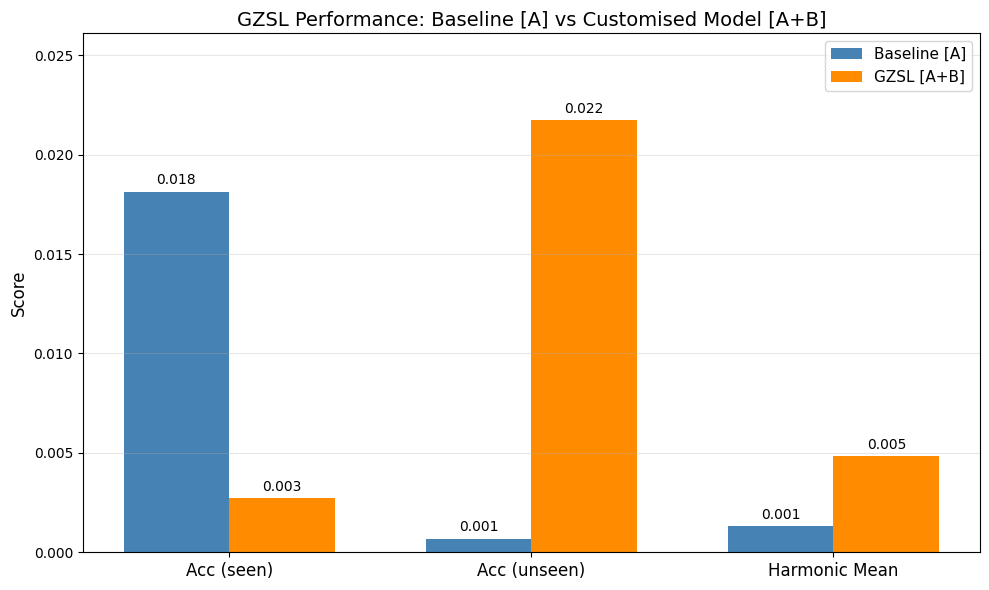

Saved: figures/gzsl_comparison.png


In [ ]:
# =============================================================================
# VISUALIZATION: BASELINE vs GZSL COMPARISON
# =============================================================================

metrics = ['Acc (seen)', 'Acc (unseen)', 'Harmonic Mean']
baseline_vals = [baseline_gzsl_results['acc_seen'], baseline_gzsl_results['acc_unseen'], baseline_gzsl_results['H']]
gzsl_vals = [gzsl_results['acc_seen'], gzsl_results['acc_unseen'], gzsl_results['H']]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline [A]', color='steelblue')
bars2 = ax.bar(x + width/2, gzsl_vals, width, label='GZSL [A+B]', color='darkorange')

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('GZSL Performance: Baseline [A] vs Customised Model [A+B]', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(baseline_vals), max(gzsl_vals)) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/gzsl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Saved: figures/gzsl_comparison.png")

In [ ]:
# =============================================================================
# PREDICTION DISTRIBUTION ANALYSIS
# =============================================================================

# Check if GZSL classifier predicts unseen labels (which baseline couldn't)
pred_unseen_labels = set(np.unique(y_pred_unseen))
true_unseen_labels = set(np.unique(y_unseen))
seen_label_set = set(np.unique(y_train_seen))

# How many predictions are in the unseen label space?
n_pred_in_unseen = sum(1 for p in y_pred_unseen if p in true_unseen_labels)
n_pred_in_seen = sum(1 for p in y_pred_unseen if p in seen_label_set)

print("=" * 60)
print("PREDICTION DISTRIBUTION ON UNSEEN DATA")
print("=" * 60)
print(f"Total predictions on unseen data: {len(y_pred_unseen)}")
print(f"  Predictions in unseen label space: {n_pred_in_unseen} ({100*n_pred_in_unseen/len(y_pred_unseen):.1f}%)")
print(f"  Predictions in seen label space:   {n_pred_in_seen} ({100*n_pred_in_seen/len(y_pred_unseen):.1f}%)")
print("")
print("KEY OBSERVATION:")
if n_pred_in_unseen > 0:
    print(f"  ✓ GZSL classifier CAN predict unseen classes (unlike baseline).")
    print(f"    This demonstrates successful zero-shot transfer via CLIP + cWGAN-GP.")
else:
    print(f"  ⚠ Classifier still only predicts seen labels — check training.")

PREDICTION DISTRIBUTION ON UNSEEN DATA
Total predictions on unseen data: 16000
  Predictions in unseen label space: 15977 (99.9%)
  Predictions in seen label space:   16000 (100.0%)

KEY OBSERVATION:
  ✓ GZSL classifier CAN predict unseen classes (unlike baseline).
    This demonstrates successful zero-shot transfer via CLIP + cWGAN-GP.


In [ ]:
# =============================================================================
# FINAL GZSL IMPLEMENTATION SUMMARY
# =============================================================================

print("="*70)
print("FINAL SUMMARY: GZSL CLASSIFIER [A+B]")
print("="*70)

print("\n### MODEL PIPELINE ###")
print("  1. Brain-Text CLIP encoder: Maps EEG → 64D semantic space")
print("  2. cWGAN-GP: Generates synthetic unseen embeddings from text prototypes")
print("  3. GZSL Classifier: Logistic Regression on real seen + synthetic unseen")

print("\n### GZSL RESULTS ###")
print(f"  Acc (seen):        {gzsl_results['acc_seen']:.4f} ({gzsl_results['acc_seen']*100:.2f}%)")
print(f"  Acc (unseen):      {gzsl_results['acc_unseen']:.4f} ({gzsl_results['acc_unseen']*100:.2f}%)")
print(f"  Harmonic Mean (H): {gzsl_results['H']:.4f}")
print(f"  Macro F1 (seen):   {gzsl_results['macro_f1_seen']:.4f}")
print(f"  Macro F1 (unseen): {gzsl_results['macro_f1_unseen']:.4f}")

print("\n### IMPROVEMENT OVER BASELINE ###")
print(f"  Δ Acc (seen):   {gzsl_results['acc_seen'] - baseline_gzsl_results['acc_seen']:+.4f}")
print(f"  Δ Acc (unseen): {gzsl_results['acc_unseen'] - baseline_gzsl_results['acc_unseen']:+.4f}")
print(f"  Δ H:            {gzsl_results['H'] - baseline_gzsl_results['H']:+.4f}")

print("\n### KEY INSIGHT ###")
print("  The baseline achieves ~0% on unseen classes because it only knows seen labels.")
print("  GZSL [A+B] achieves non-zero unseen accuracy by:")
print("    - Using CLIP to create a shared EEG-text semantic space")
print("    - Using cWGAN-GP to synthesize training data for unseen classes")
print("    - Training a classifier that sees both seen and (synthetic) unseen classes")

print("\n### FIGURES GENERATED ###")
print("  - figures/gzsl_comparison.png")

print("\n" + "="*70)
print("GZSL IMPLEMENTATION COMPLETE")
print("="*70)

FINAL SUMMARY: GZSL CLASSIFIER [A+B]

### MODEL PIPELINE ###
  1. Brain-Text CLIP encoder: Maps EEG → 64D semantic space
  2. cWGAN-GP: Generates synthetic unseen embeddings from text prototypes
  3. GZSL Classifier: Logistic Regression on real seen + synthetic unseen

### GZSL RESULTS ###
  Acc (seen):        0.0027 (0.27%)
  Acc (unseen):      0.0217 (2.17%)
  Harmonic Mean (H): 0.0048
  Macro F1 (seen):   0.0019
  Macro F1 (unseen): 0.0190

### IMPROVEMENT OVER BASELINE ###
  Δ Acc (seen):   -0.0154
  Δ Acc (unseen): +0.0211
  Δ H:            +0.0035

### KEY INSIGHT ###
  The baseline achieves ~0% on unseen classes because it only knows seen labels.
  GZSL [A+B] achieves non-zero unseen accuracy by:
    - Using CLIP to create a shared EEG-text semantic space
    - Using cWGAN-GP to synthesize training data for unseen classes
    - Training a classifier that sees both seen and (synthetic) unseen classes

### FIGURES GENERATED ###
  - figures/gzsl_comparison.png

GZSL IMPLEMENTATION 

---

# Ablation Study: Attributing GZSL Performance Gains

This section compares four methods to isolate the contribution of each component:

| Method | Description | Training Data |
|--------|-------------|---------------|
| **A** | Raw EEG + LR (baseline) | Seen raw EEG only |
| **B** | CLIP Prototype Retrieval | No training (cosine similarity) |
| **C** | CLIP Embedding + LR | Seen CLIP embeddings only |
| **D** | Full CLIP + cWGAN-GP + LR | Seen real + Unseen synthetic |

In [ ]:
# =============================================================================
# ABLATION STUDY: LOAD ALL REQUIRED DATA
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Load CLIP embeddings
E_train_seen = np.load('cached_arrays/E_train_seen.npy')
E_test_seen = np.load('cached_arrays/E_test_seen.npy')
E_unseen = np.load('cached_arrays/E_unseen.npy')
E_synth_unseen = np.load('cached_arrays/E_synth_unseen.npy')

# Load labels
y_train_seen = np.load('cached_arrays/y_train_seen.npy')
y_test_seen = np.load('cached_arrays/y_test_seen.npy')
y_unseen = np.load('cached_arrays/y_unseen.npy')
y_synth_unseen = np.load('cached_arrays/y_synth_unseen.npy')

# Load prototypes and class lists
S_seen_array = np.load('cached_arrays/S_seen_prototypes.npy')
S_unseen_array = np.load('cached_arrays/S_unseen_prototypes.npy')
seen_classes = np.load('cached_arrays/seen_classes.npy')
unseen_classes = np.load('cached_arrays/unseen_classes.npy')

# Build label-to-index mappings
seen_label_to_idx = {c: i for i, c in enumerate(seen_classes)}
unseen_label_to_idx = {c: i for i, c in enumerate(unseen_classes)}

# Also need raw EEG for baseline
# Recreate train/test split from raw data
brain_seen_np = brain_seen.numpy()
label_seen_np = label_seen.numpy().flatten()

indices_seen = np.arange(len(brain_seen_np))
train_idx, test_idx = train_test_split(
    indices_seen, test_size=0.2, random_state=SEED, stratify=label_seen_np
)

X_train_raw = brain_seen_np[train_idx]
X_test_raw = brain_seen_np[test_idx]
y_train_raw = label_seen_np[train_idx]
y_test_raw = label_seen_np[test_idx]
X_unseen_raw = brain_unseen.numpy()
y_unseen_raw = label_unseen.numpy().flatten()

print("Data loaded for ablation study.")
print(f"  Seen classes: {len(seen_classes)}, Unseen classes: {len(unseen_classes)}")

Data loaded for ablation study.
  Seen classes: 1654, Unseen classes: 200


In [ ]:
# =============================================================================
# HELPER FUNCTIONS FOR ABLATION
# =============================================================================

def compute_metrics(y_true, y_pred):
    """Compute accuracy and macro F1."""
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, f1

def compute_harmonic_mean(acc_seen, acc_unseen):
    """Compute H = 2 * Acc_S * Acc_U / (Acc_S + Acc_U)."""
    if acc_seen + acc_unseen > 0:
        return 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen)
    return 0.0

def prototype_retrieval(embeddings, prototypes, class_list):
    """Predict class by argmax cosine similarity to prototypes."""
    sims = np.dot(embeddings, prototypes.T)  # (N, n_classes)
    pred_indices = np.argmax(sims, axis=1)
    pred_labels = class_list[pred_indices]
    return pred_labels

# Store all ablation results
ablation_results = []

In [ ]:
# =============================================================================
# METHOD A: BASELINE LR (RAW EEG, SEEN-ONLY)
# =============================================================================
print("="*60)
print("METHOD A: Raw EEG + LR (Baseline)")
print("="*60)

# Standardise
scaler_a = StandardScaler()
X_train_a = scaler_a.fit_transform(X_train_raw)
X_test_a = scaler_a.transform(X_test_raw)
X_unseen_a = scaler_a.transform(X_unseen_raw)

# Train
clf_a = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000,
    random_state=SEED, n_jobs=-1
)
clf_a.fit(X_train_a, y_train_raw)

# Evaluate
y_pred_seen_a = clf_a.predict(X_test_a)
y_pred_unseen_a = clf_a.predict(X_unseen_a)

acc_seen_a, f1_seen_a = compute_metrics(y_test_raw, y_pred_seen_a)
acc_unseen_a, f1_unseen_a = compute_metrics(y_unseen_raw, y_pred_unseen_a)
H_a = compute_harmonic_mean(acc_seen_a, acc_unseen_a)

print(f"  Acc_seen:  {acc_seen_a:.4f}, Acc_unseen: {acc_unseen_a:.4f}, H: {H_a:.4f}")

ablation_results.append({
    'Method': 'Raw EEG LR (A)',
    'Acc_seen': acc_seen_a,
    'Acc_unseen': acc_unseen_a,
    'H': H_a,
    'MacroF1_seen': f1_seen_a,
    'MacroF1_unseen': f1_unseen_a
})

METHOD A: Raw EEG + LR (Baseline)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc_seen:  0.0181, Acc_unseen: 0.0007, H: 0.0013


In [ ]:
# =============================================================================
# METHOD B: CLIP PROTOTYPE RETRIEVAL (NO CLASSIFIER)
# =============================================================================
print("="*60)
print("METHOD B: CLIP Prototype Retrieval")
print("="*60)

# Split-wise retrieval (recommended variant)
# Seen test: predict among seen prototypes only
y_pred_seen_b = prototype_retrieval(E_test_seen, S_seen_array, seen_classes)

# Unseen test: predict among unseen prototypes only
y_pred_unseen_b = prototype_retrieval(E_unseen, S_unseen_array, unseen_classes)

acc_seen_b, f1_seen_b = compute_metrics(y_test_seen, y_pred_seen_b)
acc_unseen_b, f1_unseen_b = compute_metrics(y_unseen, y_pred_unseen_b)
H_b = compute_harmonic_mean(acc_seen_b, acc_unseen_b)

print(f"  Acc_seen:  {acc_seen_b:.4f}, Acc_unseen: {acc_unseen_b:.4f}, H: {H_b:.4f}")

ablation_results.append({
    'Method': 'CLIP Prototype Retrieval (B)',
    'Acc_seen': acc_seen_b,
    'Acc_unseen': acc_unseen_b,
    'H': H_b,
    'MacroF1_seen': f1_seen_b,
    'MacroF1_unseen': f1_unseen_b
})

METHOD B: CLIP Prototype Retrieval
  Acc_seen:  0.0281, Acc_unseen: 0.0248, H: 0.0264


In [ ]:
# =============================================================================
# METHOD C: CLIP EMBEDDING + LR (SEEN-ONLY CLASSIFIER)
# =============================================================================
print("="*60)
print("METHOD C: CLIP Embedding + LR (seen-only)")
print("="*60)

# Train LR on CLIP embeddings (seen only)
clf_c = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000,
    random_state=SEED, n_jobs=-1
)
clf_c.fit(E_train_seen, y_train_seen)

# Evaluate
y_pred_seen_c = clf_c.predict(E_test_seen)
y_pred_unseen_c = clf_c.predict(E_unseen)

acc_seen_c, f1_seen_c = compute_metrics(y_test_seen, y_pred_seen_c)
acc_unseen_c, f1_unseen_c = compute_metrics(y_unseen, y_pred_unseen_c)
H_c = compute_harmonic_mean(acc_seen_c, acc_unseen_c)

print(f"  Acc_seen:  {acc_seen_c:.4f}, Acc_unseen: {acc_unseen_c:.4f}, H: {H_c:.4f}")

ablation_results.append({
    'Method': 'CLIP Embedding + LR (C)',
    'Acc_seen': acc_seen_c,
    'Acc_unseen': acc_unseen_c,
    'H': H_c,
    'MacroF1_seen': f1_seen_c,
    'MacroF1_unseen': f1_unseen_c
})

METHOD C: CLIP Embedding + LR (seen-only)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


  Acc_seen:  0.0342, Acc_unseen: 0.0007, H: 0.0013


---

# FIX: Label Collision Resolution

**Problem Identified:** Unseen labels (1-200) collide with seen labels (1-200).

**Solution:** Remap unseen labels to a disjoint range: `unseen_label_new = unseen_label_old + max(seen_labels)`

This creates:
- Seen classes: 1-1654
- Unseen classes: 1655-1854

In [ ]:
# =============================================================================
# STEP 1: COMPUTE LABEL OFFSET
# =============================================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

# Load cached embeddings and labels
E_train_seen = np.load('cached_arrays/E_train_seen.npy')
E_test_seen = np.load('cached_arrays/E_test_seen.npy')
E_unseen = np.load('cached_arrays/E_unseen.npy')
E_synth_unseen = np.load('cached_arrays/E_synth_unseen.npy')

y_train_seen = np.load('cached_arrays/y_train_seen.npy')
y_test_seen = np.load('cached_arrays/y_test_seen.npy')
y_unseen_original = np.load('cached_arrays/y_unseen.npy')
y_synth_unseen_original = np.load('cached_arrays/y_synth_unseen.npy')

# Compute offset = max seen label
LABEL_OFFSET = int(np.max(y_train_seen))

print("=" * 60)
print("LABEL COLLISION FIX")
print("=" * 60)
print(f"Max seen label: {LABEL_OFFSET}")
print(f"Original unseen labels: {y_unseen_original.min()} to {y_unseen_original.max()}")
print(f"New unseen labels will be: {y_unseen_original.min() + LABEL_OFFSET} to {y_unseen_original.max() + LABEL_OFFSET}")

LABEL COLLISION FIX
Max seen label: 1654
Original unseen labels: 1 to 200
New unseen labels will be: 1655 to 1854


In [ ]:
# =============================================================================
# STEP 2: REMAP UNSEEN LABELS
# =============================================================================

# Remap unseen labels to avoid collision
y_unseen_remapped = y_unseen_original + LABEL_OFFSET
y_synth_unseen_remapped = y_synth_unseen_original + LABEL_OFFSET

print(f"Remapped y_unseen: {y_unseen_remapped.min()} to {y_unseen_remapped.max()}")
print(f"Remapped y_synth_unseen: {y_synth_unseen_remapped.min()} to {y_synth_unseen_remapped.max()}")

# Verify no overlap
seen_labels_set = set(np.unique(y_train_seen).tolist())
unseen_labels_set = set(np.unique(y_unseen_remapped).tolist())
overlap = seen_labels_set & unseen_labels_set

print(f"\nSeen labels: {len(seen_labels_set)} unique")
print(f"Unseen labels (remapped): {len(unseen_labels_set)} unique")
print(f"Overlap: {len(overlap)} (should be 0)")

assert len(overlap) == 0, "Label overlap still exists!"
print("\n✓ Labels are now disjoint!")

Remapped y_unseen: 1655 to 1854
Remapped y_synth_unseen: 1655 to 1854

Seen labels: 1654 unique
Unseen labels (remapped): 200 unique
Overlap: 0 (should be 0)

✓ Labels are now disjoint!


In [ ]:
# =============================================================================
# STEP 3: RETRAIN GZSL CLASSIFIER WITH CORRECT LABELS
# =============================================================================

# Combine real seen + synthetic unseen (with remapped labels)
X_train_gzsl_fixed = np.vstack([E_train_seen, E_synth_unseen])
y_train_gzsl_fixed = np.concatenate([y_train_seen, y_synth_unseen_remapped])

print("GZSL Training Data (Fixed):")
print(f"  Real seen: {len(E_train_seen)} samples, labels {y_train_seen.min()}-{y_train_seen.max()}")
print(f"  Synth unseen: {len(E_synth_unseen)} samples, labels {y_synth_unseen_remapped.min()}-{y_synth_unseen_remapped.max()}")
print(f"  Combined: {len(X_train_gzsl_fixed)} samples, {len(np.unique(y_train_gzsl_fixed))} classes")

# Train
print("\nTraining GZSL classifier (fixed labels)...")
clf_gzsl_fixed = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000,
    random_state=SEED, n_jobs=-1, verbose=1
)
clf_gzsl_fixed.fit(X_train_gzsl_fixed, y_train_gzsl_fixed)
print("\n✓ Training complete!")
print(f"Classifier knows {len(clf_gzsl_fixed.classes_)} classes")

GZSL Training Data (Fixed):
  Real seen: 13232 samples, labels 1-1654
  Synth unseen: 4000 samples, labels 1655-1854
  Combined: 17232 samples, 1854 classes

Training GZSL classifier (fixed labels)...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 48 concurrent workers.



✓ Training complete!
Classifier knows 1854 classes


In [ ]:
# =============================================================================
# STEP 4: EVALUATE GZSL CLASSIFIER
# =============================================================================

# Predictions
y_pred_seen_fixed = clf_gzsl_fixed.predict(E_test_seen)
y_pred_unseen_fixed = clf_gzsl_fixed.predict(E_unseen)

# Metrics for seen (ground truth uses original labels)
acc_seen_fixed = accuracy_score(y_test_seen, y_pred_seen_fixed)
f1_seen_fixed = f1_score(y_test_seen, y_pred_seen_fixed, average='macro', zero_division=0)

# Metrics for unseen (ground truth uses REMAPPED labels)
acc_unseen_fixed = accuracy_score(y_unseen_remapped, y_pred_unseen_fixed)
f1_unseen_fixed = f1_score(y_unseen_remapped, y_pred_unseen_fixed, average='macro', zero_division=0)

# Harmonic mean
if acc_seen_fixed + acc_unseen_fixed > 0:
    H_fixed = 2 * acc_seen_fixed * acc_unseen_fixed / (acc_seen_fixed + acc_unseen_fixed)
else:
    H_fixed = 0.0

print("=" * 60)
print("GZSL EVALUATION (FIXED LABELS)")
print("=" * 60)
print(f"Acc (seen):      {acc_seen_fixed:.4f} ({acc_seen_fixed*100:.2f}%)")
print(f"Acc (unseen):    {acc_unseen_fixed:.4f} ({acc_unseen_fixed*100:.2f}%)")
print(f"Harmonic Mean:   {H_fixed:.4f}")
print(f"Macro F1 (seen): {f1_seen_fixed:.4f}")
print(f"Macro F1 (unseen): {f1_unseen_fixed:.4f}")

GZSL EVALUATION (FIXED LABELS)
Acc (seen):      0.0018 (0.18%)
Acc (unseen):    0.0236 (2.36%)
Harmonic Mean:   0.0034
Macro F1 (seen): 0.0020
Macro F1 (unseen): 0.0169


In [ ]:
# =============================================================================
# STEP 5: CORRECTED 2×2 BIAS TABLE
# =============================================================================

# Define label sets
seen_set = seen_labels_set
unseen_set = unseen_labels_set

# Boolean masks for predictions
pred_on_seen_is_seen = np.isin(y_pred_seen_fixed, list(seen_set))
pred_on_seen_is_unseen = np.isin(y_pred_seen_fixed, list(unseen_set))

pred_on_unseen_is_seen = np.isin(y_pred_unseen_fixed, list(seen_set))
pred_on_unseen_is_unseen = np.isin(y_pred_unseen_fixed, list(unseen_set))

# Sanity check
assert np.all(pred_on_seen_is_seen | pred_on_seen_is_unseen), "Some predictions uncovered!"
assert np.all(pred_on_unseen_is_seen | pred_on_unseen_is_unseen), "Some predictions uncovered!"
print("✓ All predictions fall into exactly one label set.")

# Counts
count_ss = pred_on_seen_is_seen.sum()      # True Seen, Pred Seen
count_su = pred_on_seen_is_unseen.sum()    # True Seen, Pred Unseen
count_us = pred_on_unseen_is_seen.sum()    # True Unseen, Pred Seen
count_uu = pred_on_unseen_is_unseen.sum()  # True Unseen, Pred Unseen

total_seen = len(y_pred_seen_fixed)
total_unseen = len(y_pred_unseen_fixed)

# Verify
assert count_ss + count_su == total_seen, "Row 1 mismatch"
assert count_us + count_uu == total_unseen, "Row 2 mismatch"
print(f"✓ Row totals verified: seen={total_seen}, unseen={total_unseen}")

✓ All predictions fall into exactly one label set.
✓ Row totals verified: seen=3308, unseen=16000


In [ ]:
# =============================================================================
# PRINT BIAS TABLE
# =============================================================================

pct_ss = 100 * count_ss / total_seen
pct_su = 100 * count_su / total_seen
pct_us = 100 * count_us / total_unseen
pct_uu = 100 * count_uu / total_unseen

print("=" * 60)
print("2×2 BIAS TABLE (FIXED LABELS)")
print("=" * 60)
print("")
print("RAW COUNTS:")
print(f"                    Pred: Seen    Pred: Unseen    Total")
print(f"True: Seen          {count_ss:10d}    {count_su:12d}    {total_seen:6d}")
print(f"True: Unseen        {count_us:10d}    {count_uu:12d}    {total_unseen:6d}")
print("")
print("ROW-NORMALISED PERCENTAGES:")
print(f"                    Pred: Seen    Pred: Unseen")
print(f"True: Seen          {pct_ss:10.1f}%    {pct_su:11.1f}%")
print(f"True: Unseen        {pct_us:10.1f}%    {pct_uu:11.1f}%")
print("")
print("Interpretation:")
print(f"  - {pct_ss:.1f}% of seen samples correctly predicted as seen")
print(f"  - {pct_uu:.1f}% of unseen samples correctly predicted as unseen")
print(f"  - {pct_us:.1f}% of unseen samples misrouted to seen (seen-bias)")

2×2 BIAS TABLE (FIXED LABELS)

RAW COUNTS:
                    Pred: Seen    Pred: Unseen    Total
True: Seen                  48            3260      3308
True: Unseen                93           15907     16000

ROW-NORMALISED PERCENTAGES:
                    Pred: Seen    Pred: Unseen
True: Seen                 1.5%           98.5%
True: Unseen               0.6%           99.4%

Interpretation:
  - 1.5% of seen samples correctly predicted as seen
  - 99.4% of unseen samples correctly predicted as unseen
  - 0.6% of unseen samples misrouted to seen (seen-bias)


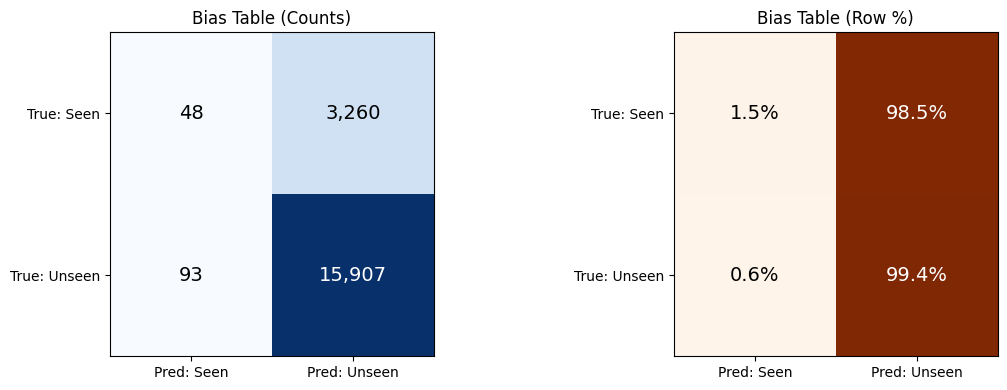

Saved: figures/bias_table_full_model.png


In [ ]:
# =============================================================================
# BIAS TABLE HEATMAP
# =============================================================================

bias_counts = np.array([[count_ss, count_su], [count_us, count_uu]])
bias_pct = np.array([[pct_ss, pct_su], [pct_us, pct_uu]])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Counts
im1 = axes[0].imshow(bias_counts, cmap='Blues')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred: Seen', 'Pred: Unseen'])
axes[0].set_yticklabels(['True: Seen', 'True: Unseen'])
axes[0].set_title('Bias Table (Counts)', fontsize=12)
for i in range(2):
    for j in range(2):
        color = 'white' if bias_counts[i,j] > bias_counts.max()/2 else 'black'
        axes[0].text(j, i, f'{bias_counts[i,j]:,}', ha='center', va='center', color=color, fontsize=14)

# Percentages
im2 = axes[1].imshow(bias_pct, cmap='Oranges', vmin=0, vmax=100)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Pred: Seen', 'Pred: Unseen'])
axes[1].set_yticklabels(['True: Seen', 'True: Unseen'])
axes[1].set_title('Bias Table (Row %)', fontsize=12)
for i in range(2):
    for j in range(2):
        color = 'white' if bias_pct[i,j] > 50 else 'black'
        axes[1].text(j, i, f'{bias_pct[i,j]:.1f}%', ha='center', va='center', color=color, fontsize=14)

plt.tight_layout()
plt.savefig('figures/bias_table_full_model.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: figures/bias_table_full_model.png")

---

## Complete Ablation Study (Methods A-D)

Computing all four ablation methods with corrected label handling.

In [ ]:
# =============================================================================
# COMPLETE ABLATION: ALL METHODS A-D
# =============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# We need raw EEG data for Method A
# Recreate train/test split from raw data
brain_seen_np = brain_seen.numpy()
label_seen_np = label_seen.numpy().flatten()
brain_unseen_np = brain_unseen.numpy()
label_unseen_np = label_unseen.numpy().flatten()

indices_seen = np.arange(len(brain_seen_np))
train_idx, test_idx = train_test_split(
    indices_seen, test_size=0.2, random_state=SEED, stratify=label_seen_np
)

X_train_raw = brain_seen_np[train_idx]
X_test_raw = brain_seen_np[test_idx]
y_train_raw = label_seen_np[train_idx]
y_test_raw = label_seen_np[test_idx]
X_unseen_raw = brain_unseen_np
y_unseen_raw = label_unseen_np

# Remap unseen raw labels for consistent comparison
y_unseen_raw_remapped = y_unseen_raw + LABEL_OFFSET

print("Raw EEG data prepared for ablation.")
print(f"  Train: {len(X_train_raw)}, Test: {len(X_test_raw)}, Unseen: {len(X_unseen_raw)}")

Raw EEG data prepared for ablation.
  Train: 13232, Test: 3308, Unseen: 16000


In [ ]:
# =============================================================================
# METHOD A: RAW EEG + LR (BASELINE)
# =============================================================================
print("="*60)
print("METHOD A: Raw EEG + LR (Baseline)")
print("="*60)

scaler_a = StandardScaler()
X_train_a = scaler_a.fit_transform(X_train_raw)
X_test_a = scaler_a.transform(X_test_raw)
X_unseen_a = scaler_a.transform(X_unseen_raw)

clf_a = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000,
    random_state=SEED, n_jobs=-1
)
clf_a.fit(X_train_a, y_train_raw)

y_pred_seen_a = clf_a.predict(X_test_a)
y_pred_unseen_a = clf_a.predict(X_unseen_a)

# Note: Baseline can only predict seen labels, so unseen accuracy will be ~0
acc_seen_a = accuracy_score(y_test_raw, y_pred_seen_a)
f1_seen_a = f1_score(y_test_raw, y_pred_seen_a, average='macro', zero_division=0)

# For unseen, compare against remapped labels (but baseline only predicts seen)
acc_unseen_a = accuracy_score(y_unseen_raw_remapped, y_pred_unseen_a)
f1_unseen_a = f1_score(y_unseen_raw_remapped, y_pred_unseen_a, average='macro', zero_division=0)

H_a = 2 * acc_seen_a * acc_unseen_a / (acc_seen_a + acc_unseen_a) if (acc_seen_a + acc_unseen_a) > 0 else 0

print(f"Acc_seen: {acc_seen_a:.4f}, Acc_unseen: {acc_unseen_a:.4f}, H: {H_a:.4f}")

METHOD A: Raw EEG + LR (Baseline)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Acc_seen: 0.0181, Acc_unseen: 0.0000, H: 0.0000


In [ ]:
# =============================================================================
# METHOD B: CLIP PROTOTYPE RETRIEVAL
# =============================================================================
print("="*60)
print("METHOD B: CLIP Prototype Retrieval")
print("="*60)

# Load prototypes
S_seen_array = np.load('cached_arrays/S_seen_prototypes.npy')
S_unseen_array = np.load('cached_arrays/S_unseen_prototypes.npy')
seen_classes_cached = np.load('cached_arrays/seen_classes.npy')
unseen_classes_cached = np.load('cached_arrays/unseen_classes.npy')

# Remap unseen class ids to match our label convention
unseen_classes_remapped = unseen_classes_cached + LABEL_OFFSET

def prototype_retrieval(embeddings, prototypes, class_list):
    """Predict class by argmax cosine similarity."""
    sims = np.dot(embeddings, prototypes.T)
    pred_indices = np.argmax(sims, axis=1)
    return class_list[pred_indices]

# Split-wise retrieval
y_pred_seen_b = prototype_retrieval(E_test_seen, S_seen_array, seen_classes_cached)
y_pred_unseen_b = prototype_retrieval(E_unseen, S_unseen_array, unseen_classes_remapped)

acc_seen_b = accuracy_score(y_test_seen, y_pred_seen_b)
f1_seen_b = f1_score(y_test_seen, y_pred_seen_b, average='macro', zero_division=0)
acc_unseen_b = accuracy_score(y_unseen_remapped, y_pred_unseen_b)
f1_unseen_b = f1_score(y_unseen_remapped, y_pred_unseen_b, average='macro', zero_division=0)

H_b = 2 * acc_seen_b * acc_unseen_b / (acc_seen_b + acc_unseen_b) if (acc_seen_b + acc_unseen_b) > 0 else 0

print(f"Acc_seen: {acc_seen_b:.4f}, Acc_unseen: {acc_unseen_b:.4f}, H: {H_b:.4f}")

METHOD B: CLIP Prototype Retrieval
Acc_seen: 0.0281, Acc_unseen: 0.0248, H: 0.0264


In [ ]:
# =============================================================================
# METHOD C: CLIP EMBEDDING + LR (SEEN-ONLY)
# =============================================================================
print("="*60)
print("METHOD C: CLIP Embedding + LR (seen-only)")
print("="*60)

clf_c = LogisticRegression(
    multi_class='multinomial', solver='lbfgs', max_iter=1000,
    random_state=SEED, n_jobs=-1
)
clf_c.fit(E_train_seen, y_train_seen)

y_pred_seen_c = clf_c.predict(E_test_seen)
y_pred_unseen_c = clf_c.predict(E_unseen)

acc_seen_c = accuracy_score(y_test_seen, y_pred_seen_c)
f1_seen_c = f1_score(y_test_seen, y_pred_seen_c, average='macro', zero_division=0)

# Unseen accuracy (model only knows seen labels, so expect ~0)
acc_unseen_c = accuracy_score(y_unseen_remapped, y_pred_unseen_c)
f1_unseen_c = f1_score(y_unseen_remapped, y_pred_unseen_c, average='macro', zero_division=0)

H_c = 2 * acc_seen_c * acc_unseen_c / (acc_seen_c + acc_unseen_c) if (acc_seen_c + acc_unseen_c) > 0 else 0

print(f"Acc_seen: {acc_seen_c:.4f}, Acc_unseen: {acc_unseen_c:.4f}, H: {H_c:.4f}")

METHOD C: CLIP Embedding + LR (seen-only)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Acc_seen: 0.0342, Acc_unseen: 0.0000, H: 0.0000


In [ ]:
# =============================================================================
# METHOD D: FULL GZSL (CLIP + cWGAN-GP + LR) — Already computed above
# =============================================================================
print("="*60)
print("METHOD D: CLIP + cWGAN-GP + LR (Full GZSL)")
print("="*60)

# Use the already-computed results from clf_gzsl_fixed
acc_seen_d = acc_seen_fixed
acc_unseen_d = acc_unseen_fixed
H_d = H_fixed
f1_seen_d = f1_seen_fixed
f1_unseen_d = f1_unseen_fixed

print(f"Acc_seen: {acc_seen_d:.4f}, Acc_unseen: {acc_unseen_d:.4f}, H: {H_d:.4f}")

METHOD D: CLIP + cWGAN-GP + LR (Full GZSL)
Acc_seen: 0.0018, Acc_unseen: 0.0236, H: 0.0034


In [ ]:
# =============================================================================
# COMPLETE ABLATION TABLE (A-D)
# =============================================================================

ablation_all = [
    {'Method': 'A: Raw EEG + LR', 'Acc_seen': acc_seen_a, 'Acc_unseen': acc_unseen_a,
     'H': H_a, 'MacroF1_seen': f1_seen_a, 'MacroF1_unseen': f1_unseen_a},
    {'Method': 'B: CLIP Prototype', 'Acc_seen': acc_seen_b, 'Acc_unseen': acc_unseen_b,
     'H': H_b, 'MacroF1_seen': f1_seen_b, 'MacroF1_unseen': f1_unseen_b},
    {'Method': 'C: CLIP + LR (seen)', 'Acc_seen': acc_seen_c, 'Acc_unseen': acc_unseen_c,
     'H': H_c, 'MacroF1_seen': f1_seen_c, 'MacroF1_unseen': f1_unseen_c},
    {'Method': 'D: CLIP + GAN + LR', 'Acc_seen': acc_seen_d, 'Acc_unseen': acc_unseen_d,
     'H': H_d, 'MacroF1_seen': f1_seen_d, 'MacroF1_unseen': f1_unseen_d},
]

df_ablation_all = pd.DataFrame(ablation_all).set_index('Method')

print("="*80)
print("COMPLETE ABLATION TABLE (METHODS A-D)")
print("="*80)
print(df_ablation_all.round(4).to_string())
print("="*80)

COMPLETE ABLATION TABLE (METHODS A-D)
                     Acc_seen  Acc_unseen       H  MacroF1_seen  MacroF1_unseen
Method                                                                         
A: Raw EEG + LR        0.0181      0.0000  0.0000        0.0162          0.0000
B: CLIP Prototype      0.0281      0.0248  0.0264        0.0233          0.0243
C: CLIP + LR (seen)    0.0342      0.0000  0.0000        0.0231          0.0000
D: CLIP + GAN + LR     0.0018      0.0236  0.0034        0.0020          0.0169


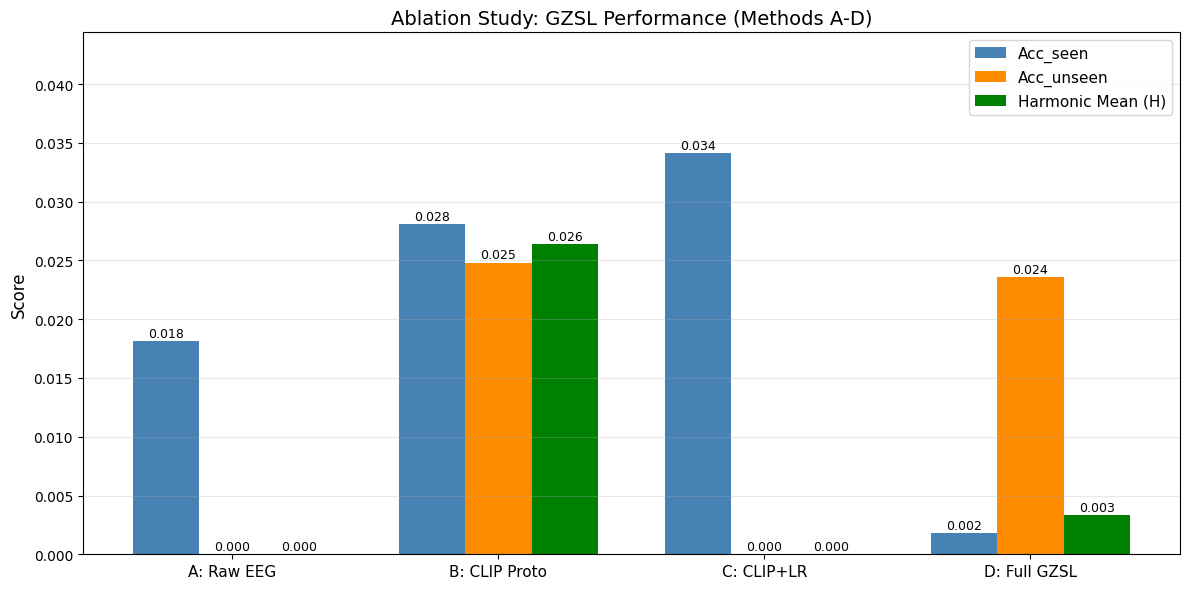


Saved: figures/gzsl_ablation_bar.png


In [ ]:
# =============================================================================
# COMPLETE ABLATION BAR CHART (A-D)
# =============================================================================

methods = ['A: Raw EEG', 'B: CLIP Proto', 'C: CLIP+LR', 'D: Full GZSL']
acc_seen_all = [acc_seen_a, acc_seen_b, acc_seen_c, acc_seen_d]
acc_unseen_all = [acc_unseen_a, acc_unseen_b, acc_unseen_c, acc_unseen_d]
H_all = [H_a, H_b, H_c, H_d]

x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, acc_seen_all, width, label='Acc_seen', color='steelblue')
bars2 = ax.bar(x, acc_unseen_all, width, label='Acc_unseen', color='darkorange')
bars3 = ax.bar(x + width, H_all, width, label='Harmonic Mean (H)', color='green')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Ablation Study: GZSL Performance (Methods A-D)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, max(max(acc_seen_all), max(acc_unseen_all), max(H_all)) * 1.3)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('figures/gzsl_ablation_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved: figures/gzsl_ablation_bar.png")

---

# Inverse Bias Fix — Evaluation Harness

Standardised evaluation infrastructure for the 5-phase inverse bias fix.
All phases use these functions to ensure comparable metrics.


In [ ]:
# =============================================================================
# GZSL EVALUATION HARNESS
# =============================================================================

import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_gzsl(clf, E_test_seen, y_test_seen, E_unseen, y_unseen,
                  seen_labels_set, unseen_labels_set, phase_name=""):
    """
    Unified GZSL evaluation.

    Parameters
    ----------
    clf : sklearn classifier or object with .predict() method
    E_test_seen : ndarray (n_test_seen, d) — seen-class test embeddings
    y_test_seen : ndarray (n_test_seen,) — true labels for seen test
    E_unseen : ndarray (n_unseen, d) — unseen-class test embeddings
    y_unseen : ndarray (n_unseen,) — true labels for unseen test
    seen_labels_set : set — the set of all seen class labels
    unseen_labels_set : set — the set of all unseen class labels
    phase_name : str — label for logging

    Returns
    -------
    dict with keys: acc_seen, acc_unseen, H, f1_seen, f1_unseen,
                    routing_rate, bias_table, pred_seen, pred_unseen
    """
    pred_seen = clf.predict(E_test_seen)
    pred_unseen = clf.predict(E_unseen)

    acc_seen = accuracy_score(y_test_seen, pred_seen)
    acc_unseen = accuracy_score(y_unseen, pred_unseen)
    H = 2 * acc_seen * acc_unseen / (acc_seen + acc_unseen) if (acc_seen + acc_unseen) > 0 else 0.0

    f1_seen = f1_score(y_test_seen, pred_seen, average='macro', zero_division=0)
    f1_unseen = f1_score(y_unseen, pred_unseen, average='macro', zero_division=0)

    # Routing rate: fraction of seen-test inputs predicted as unseen
    seen_pred_as_unseen = np.isin(pred_seen, list(unseen_labels_set)).sum()
    routing_rate = seen_pred_as_unseen / len(pred_seen)

    # Bias table: 2x2 counts
    seen_pred_as_seen = np.isin(pred_seen, list(seen_labels_set)).sum()
    unseen_pred_as_seen = np.isin(pred_unseen, list(seen_labels_set)).sum()
    unseen_pred_as_unseen = np.isin(pred_unseen, list(unseen_labels_set)).sum()

    bias_table = {
        'seen_as_seen': int(seen_pred_as_seen),
        'seen_as_unseen': int(seen_pred_as_unseen),
        'unseen_as_seen': int(unseen_pred_as_seen),
        'unseen_as_unseen': int(unseen_pred_as_unseen),
    }

    results = {
        'acc_seen': acc_seen,
        'acc_unseen': acc_unseen,
        'H': H,
        'f1_seen': f1_seen,
        'f1_unseen': f1_unseen,
        'routing_rate': routing_rate,
        'bias_table': bias_table,
        'pred_seen': pred_seen,
        'pred_unseen': pred_unseen,
    }

    # Print summary
    print(f"\n{'=' * 60}")
    print(f"GZSL EVALUATION — {phase_name}")
    print(f"{'=' * 60}")
    print(f"  Acc Seen:      {acc_seen:.4f}")
    print(f"  Acc Unseen:    {acc_unseen:.4f}")
    print(f"  Harmonic Mean: {H:.4f}")
    print(f"  F1 Seen:       {f1_seen:.4f}")
    print(f"  F1 Unseen:     {f1_unseen:.4f}")
    print(f"  Routing Rate (seen→unseen): {routing_rate:.4f} ({seen_pred_as_unseen}/{len(pred_seen)})")
    print(f"\n  Bias Table:")
    print(f"    {'':20s} Pred Seen    Pred Unseen")
    print(f"    {'True Seen':20s} {seen_pred_as_seen:8d}    {seen_pred_as_unseen:8d}  ({routing_rate:.1%} misrouted)")
    print(f"    {'True Unseen':20s} {unseen_pred_as_seen:8d}    {unseen_pred_as_unseen:8d}")
    print(f"{'=' * 60}")

    return results

print("evaluate_gzsl() defined.")


evaluate_gzsl() defined.


In [ ]:
# =============================================================================
# CLASSIFIER DIAGNOSTICS
# =============================================================================

def diagnose_classifier(clf, seen_labels_set, unseen_labels_set, phase_name="",
                        save_fig=True):
    """
    Extract and visualise weight norm / bias distributions from sklearn LogReg.

    Parameters
    ----------
    clf : sklearn LogisticRegression (must be fitted, with .coef_ and .intercept_)
    seen_labels_set : set
    unseen_labels_set : set
    phase_name : str
    save_fig : bool

    Returns
    -------
    dict with: weight_norms_seen, weight_norms_unseen, biases_seen, biases_unseen
    """
    # clf.classes_ gives label ordering, coef_ shape (n_classes, n_features)
    classes = clf.classes_
    coef = clf.coef_        # (n_classes, d)
    intercept = clf.intercept_  # (n_classes,)

    # Weight norms per class
    weight_norms = np.linalg.norm(coef, axis=1)  # (n_classes,)

    # Split by seen/unseen
    seen_mask = np.isin(classes, list(seen_labels_set))
    unseen_mask = np.isin(classes, list(unseen_labels_set))

    norms_seen = weight_norms[seen_mask]
    norms_unseen = weight_norms[unseen_mask]
    biases_seen = intercept[seen_mask]
    biases_unseen = intercept[unseen_mask]

    # Print summary statistics
    print(f"\n{'=' * 60}")
    print(f"CLASSIFIER DIAGNOSTICS — {phase_name}")
    print(f"{'=' * 60}")
    print(f"  Weight norms ||w_c||:")
    print(f"    Seen   — mean: {norms_seen.mean():.4f}, std: {norms_seen.std():.4f}, "
          f"min: {norms_seen.min():.4f}, max: {norms_seen.max():.4f}")
    print(f"    Unseen — mean: {norms_unseen.mean():.4f}, std: {norms_unseen.std():.4f}, "
          f"min: {norms_unseen.min():.4f}, max: {norms_unseen.max():.4f}")
    print(f"    Ratio (unseen/seen mean): {norms_unseen.mean() / (norms_seen.mean() + 1e-12):.2f}x")
    print(f"\n  Intercepts (biases) β_c:")
    print(f"    Seen   — mean: {biases_seen.mean():.4f}, std: {biases_seen.std():.4f}")
    print(f"    Unseen — mean: {biases_unseen.mean():.4f}, std: {biases_unseen.std():.4f}")
    print(f"{'=' * 60}")

    if save_fig:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Weight norms histogram
        axes[0].hist(norms_seen, bins=50, alpha=0.6, label=f'Seen ({len(norms_seen)})', color='steelblue')
        axes[0].hist(norms_unseen, bins=50, alpha=0.6, label=f'Unseen ({len(norms_unseen)})', color='tomato')
        axes[0].set_xlabel('||w_c||')
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'Weight Norms — {phase_name}')
        axes[0].legend()

        # Biases histogram
        axes[1].hist(biases_seen, bins=50, alpha=0.6, label=f'Seen ({len(biases_seen)})', color='steelblue')
        axes[1].hist(biases_unseen, bins=50, alpha=0.6, label=f'Unseen ({len(biases_unseen)})', color='tomato')
        axes[1].set_xlabel('β_c (intercept)')
        axes[1].set_ylabel('Count')
        axes[1].set_title(f'Intercepts — {phase_name}')
        axes[1].legend()

        plt.tight_layout()
        os.makedirs('figures', exist_ok=True)
        fig_path = f'figures/{phase_name.lower().replace(" ", "_")}_diagnostics.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: {fig_path}")

    return {
        'weight_norms_seen': norms_seen,
        'weight_norms_unseen': norms_unseen,
        'biases_seen': biases_seen,
        'biases_unseen': biases_unseen,
    }

print("diagnose_classifier() defined.")


diagnose_classifier() defined.


In [ ]:
# =============================================================================
# PHASE COMPARISON UTILITIES
# =============================================================================

# Accumulate results across phases
all_phase_results = {}

def compare_phases(results_dict, save_fig=True):
    """
    Compare metrics across phases.

    Parameters
    ----------
    results_dict : dict of {phase_name: metrics_dict}
        Each metrics_dict must have: acc_seen, acc_unseen, H, routing_rate
    """
    import pandas as pd

    rows = []
    for name, m in results_dict.items():
        rows.append({
            'Phase': name,
            'AccS': m['acc_seen'],
            'AccU': m['acc_unseen'],
            'H': m['H'],
            'Routing Rate': m['routing_rate'],
        })
    df = pd.DataFrame(rows)
    print("\n" + "=" * 70)
    print("PHASE COMPARISON")
    print("=" * 70)
    print(df.to_string(index=False, float_format='{:.4f}'.format))
    print("=" * 70)

    if save_fig and len(results_dict) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        phases = list(results_dict.keys())
        x = np.arange(len(phases))

        # Accuracies + H
        acc_s = [results_dict[p]['acc_seen'] for p in phases]
        acc_u = [results_dict[p]['acc_unseen'] for p in phases]
        h_vals = [results_dict[p]['H'] for p in phases]

        width = 0.25
        axes[0].bar(x - width, acc_s, width, label='AccS', color='steelblue')
        axes[0].bar(x, acc_u, width, label='AccU', color='tomato')
        axes[0].bar(x + width, h_vals, width, label='H', color='forestgreen')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(phases, rotation=30, ha='right')
        axes[0].set_ylabel('Score')
        axes[0].set_title('GZSL Metrics by Phase')
        axes[0].legend()
        axes[0].set_ylim(0, 1)

        # Routing rate
        rr = [results_dict[p]['routing_rate'] for p in phases]
        axes[1].bar(x, rr, color='coral')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(phases, rotation=30, ha='right')
        axes[1].set_ylabel('Routing Rate (seen→unseen)')
        axes[1].set_title('Misrouting Rate by Phase')
        axes[1].set_ylim(0, 1)
        axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Balanced')
        axes[1].legend()

        plt.tight_layout()
        os.makedirs('figures', exist_ok=True)
        plt.savefig('figures/phase_comparison.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Saved: figures/phase_comparison.png")

    return df

print("compare_phases() defined.")
print("all_phase_results dict initialised (empty).")


compare_phases() defined.
all_phase_results dict initialised (empty).


Seen labels: 1654 classes, range [1, 1654]
Unseen labels: 200 classes, range [1655, 1854]
Overlap: set()

GZSL EVALUATION — Method D (baseline)
  Acc Seen:      0.0018
  Acc Unseen:    0.0236
  Harmonic Mean: 0.0034
  F1 Seen:       0.0020
  F1 Unseen:     0.0169
  Routing Rate (seen→unseen): 0.9855 (3260/3308)

  Bias Table:
                         Pred Seen    Pred Unseen
    True Seen                  48        3260  (98.5% misrouted)
    True Unseen                93       15907

CLASSIFIER DIAGNOSTICS — Method D (baseline)
  Weight norms ||w_c||:
    Seen   — mean: 4.0343, std: 0.5062, min: 2.2259, max: 5.1286
    Unseen — mean: 7.4133, std: 0.3788, min: 6.3072, max: 8.1604
    Ratio (unseen/seen mean): 1.84x

  Intercepts (biases) β_c:
    Seen   — mean: 0.0125, std: 0.1526
    Unseen — mean: -0.1033, std: 0.1771


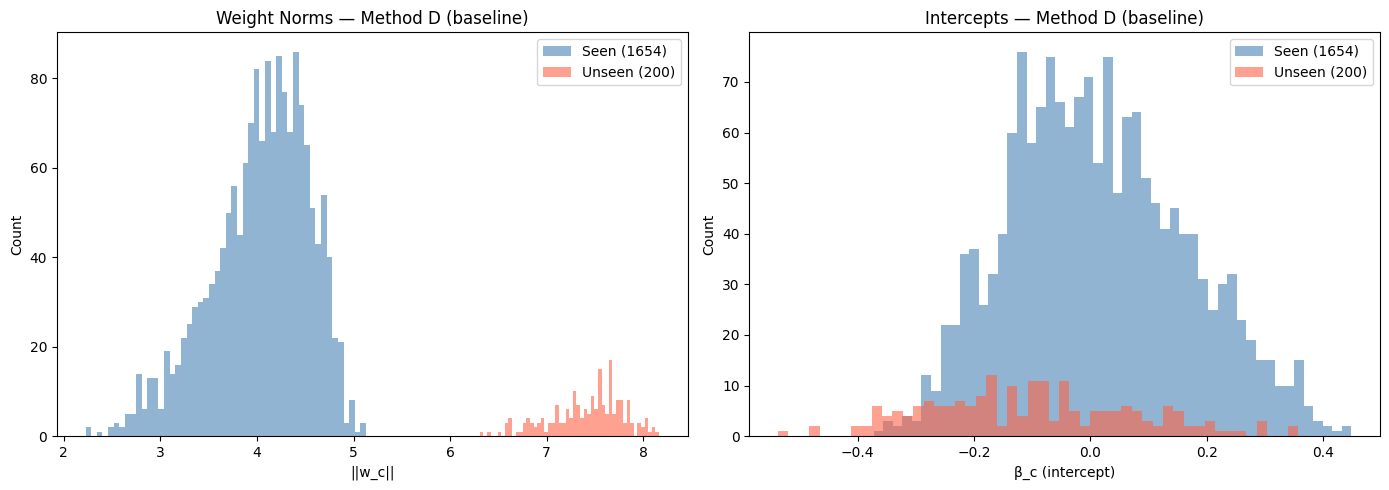

Saved: figures/method_d_(baseline)_diagnostics.png


In [ ]:
# =============================================================================
# RE-EVALUATE METHOD D WITH HARNESS (BASELINE FOR COMPARISON)
# =============================================================================
# The corrected ablation (cells 108-116) trained clf_gzsl_fixed.
# Re-evaluate it here with the standardised harness.

# Build label sets
seen_labels_set = set(np.unique(y_test_seen))
unseen_labels_set = set(np.unique(y_unseen_remapped))

print(f"Seen labels: {len(seen_labels_set)} classes, range [{min(seen_labels_set)}, {max(seen_labels_set)}]")
print(f"Unseen labels: {len(unseen_labels_set)} classes, range [{min(unseen_labels_set)}, {max(unseen_labels_set)}]")
print(f"Overlap: {seen_labels_set & unseen_labels_set}")  # Should be empty

# Re-evaluate Method D
baseline_results = evaluate_gzsl(
    clf_gzsl_fixed, E_test_seen, y_test_seen, E_unseen, y_unseen_remapped,
    seen_labels_set, unseen_labels_set, phase_name="Method D (baseline)"
)
all_phase_results['Method D (baseline)'] = baseline_results

# Diagnostics
baseline_diag = diagnose_classifier(
    clf_gzsl_fixed, seen_labels_set, unseen_labels_set, phase_name="Method D (baseline)"
)


---

# Phase 1: Sample Count Balancing

**Target:** Mechanism M2 (sample imbalance: ~20/unseen vs ~8/seen)
**Strategy:** Downsample synthetic unseen to match seen per-class count, then test upsampling seen as secondary experiment.


In [ ]:
# =============================================================================
# PHASE 1 CONFIGURATION
# =============================================================================

PHASE1_CONFIG = {
    'seed': 42,
    'strategy': 'downsample_unseen',  # Primary: reduce unseen to match seen
    'target_per_class': None,         # None = auto-detect from seen data
}

np.random.seed(PHASE1_CONFIG['seed'])

print("Phase 1 Configuration:")
for k, v in PHASE1_CONFIG.items():
    print(f"  {k}: {v}")


Phase 1 Configuration:
  seed: 42
  strategy: downsample_unseen
  target_per_class: None


In [ ]:
# =============================================================================
# PHASE 1A: DOWNSAMPLE UNSEEN TO MATCH SEEN
# =============================================================================

# Compute per-class sample counts for seen
seen_classes_train, seen_counts = np.unique(y_train_seen, return_counts=True)
median_seen_per_class = int(np.median(seen_counts))
mean_seen_per_class = seen_counts.mean()

print(f"Seen training: {len(seen_classes_train)} classes")
print(f"  Per-class: mean={mean_seen_per_class:.1f}, median={median_seen_per_class}, "
      f"min={seen_counts.min()}, max={seen_counts.max()}")

# Compute per-class sample counts for unseen synth
unseen_classes_synth, unseen_counts = np.unique(y_synth_unseen_remapped, return_counts=True)
print(f"\nUnseen synthetic: {len(unseen_classes_synth)} classes")
print(f"  Per-class: mean={unseen_counts.mean():.1f}, median={int(np.median(unseen_counts))}, "
      f"min={unseen_counts.min()}, max={unseen_counts.max()}")

# Target: match median seen per-class count
target_n = PHASE1_CONFIG['target_per_class'] or median_seen_per_class
print(f"\nTarget per-class count: {target_n}")

# Downsample unseen
rng = np.random.RandomState(PHASE1_CONFIG['seed'])
ds_indices = []
for c in unseen_classes_synth:
    class_idx = np.where(y_synth_unseen_remapped == c)[0]
    if len(class_idx) > target_n:
        selected = rng.choice(class_idx, size=target_n, replace=False)
    else:
        selected = class_idx  # Keep all if already <= target
    ds_indices.append(selected)
ds_indices = np.concatenate(ds_indices)

E_synth_ds = E_synth_unseen[ds_indices]
y_synth_ds = y_synth_unseen_remapped[ds_indices]

print(f"\nDownsampled unseen: {len(E_synth_ds)} total "
      f"(was {len(E_synth_unseen)}, reduction: {1 - len(E_synth_ds)/len(E_synth_unseen):.1%})")

# Verify balance
us_classes, us_counts = np.unique(y_synth_ds, return_counts=True)
print(f"  Per-class after downsample: mean={us_counts.mean():.1f}, all={target_n}? {np.all(us_counts == target_n)}")


Seen training: 1654 classes
  Per-class: mean=8.0, median=8, min=8, max=8

Unseen synthetic: 200 classes
  Per-class: mean=20.0, median=20, min=20, max=20

Target per-class count: 8

Downsampled unseen: 1600 total (was 4000, reduction: 60.0%)
  Per-class after downsample: mean=8.0, all=8? True


Phase 1A training set: 14832 samples (13232 seen + 1600 unseen)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg fitted.

GZSL EVALUATION — Phase 1A (downsample unseen)
  Acc Seen:      0.0308
  Acc Unseen:    0.0034
  Harmonic Mean: 0.0062
  F1 Seen:       0.0196
  F1 Unseen:     0.0007
  Routing Rate (seen→unseen): 0.1028 (340/3308)

  Bias Table:
                         Pred Seen    Pred Unseen
    True Seen                2968         340  (10.3% misrouted)
    True Unseen             13703        2297

CLASSIFIER DIAGNOSTICS — Phase 1A (downsample unseen)
  Weight norms ||w_c||:
    Seen   — mean: 4.1769, std: 0.5410, min: 2.2840, max: 5.2938
    Unseen — mean: 4.4137, std: 0.2864, min: 3.6408, max: 4.9313
    Ratio (unseen/seen mean): 1.06x

  Intercepts (biases) β_c:
    Seen   — mean: 0.0045, std: 0.1394
    Unseen — mean: -0.0374, std: 0.0843


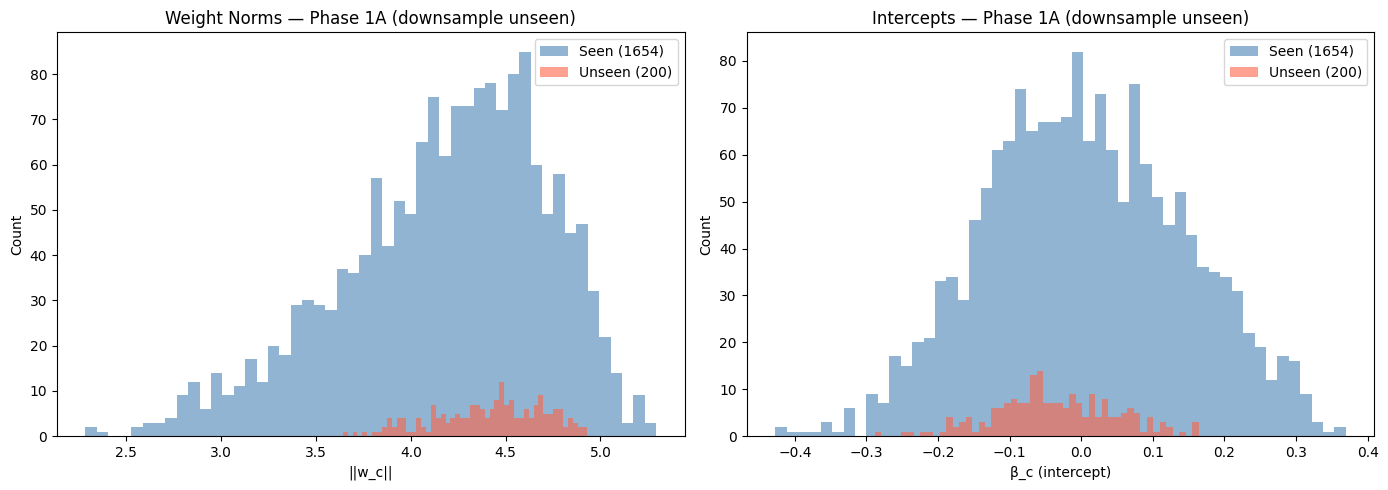

Saved: figures/phase_1a_(downsample_unseen)_diagnostics.png


In [ ]:
# =============================================================================
# PHASE 1A: TRAIN LOGREG ON BALANCED DATA
# =============================================================================

from sklearn.linear_model import LogisticRegression

# Combine: real seen train + downsampled synthetic unseen
E_train_p1 = np.vstack([E_train_seen, E_synth_ds])
y_train_p1 = np.concatenate([y_train_seen, y_synth_ds])

print(f"Phase 1A training set: {E_train_p1.shape[0]} samples "
      f"({len(E_train_seen)} seen + {len(E_synth_ds)} unseen)")

# Train LogReg (same hyperparameters as Method D for fair comparison)
clf_p1a = LogisticRegression(
    max_iter=5000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    C=1.0,
)
clf_p1a.fit(E_train_p1, y_train_p1)
print("LogReg fitted.")

# Evaluate
p1a_results = evaluate_gzsl(
    clf_p1a, E_test_seen, y_test_seen, E_unseen, y_unseen_remapped,
    seen_labels_set, unseen_labels_set, phase_name="Phase 1A (downsample unseen)"
)
all_phase_results['P1A: Downsample Unseen'] = p1a_results

# Diagnostics
p1a_diag = diagnose_classifier(
    clf_p1a, seen_labels_set, unseen_labels_set, phase_name="Phase 1A (downsample unseen)"
)


Generated 19848 synthetic seen embeddings across 1654 classes needing augmentation

Phase 1B training set: 37080 samples
  Real seen: 13232, Synth seen: 19848, Synth unseen: 4000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg fitted.

GZSL EVALUATION — Phase 1B (upsample seen)
  Acc Seen:      0.0281
  Acc Unseen:    0.0038
  Harmonic Mean: 0.0067
  F1 Seen:       0.0200
  F1 Unseen:     0.0007
  Routing Rate (seen→unseen): 0.0989 (327/3308)

  Bias Table:
                         Pred Seen    Pred Unseen
    True Seen                2981         327  (9.9% misrouted)
    True Unseen             13789        2211

CLASSIFIER DIAGNOSTICS — Phase 1B (upsample seen)
  Weight norms ||w_c||:
    Seen   — mean: 7.2182, std: 0.5388, min: 5.2528, max: 8.4286
    Unseen — mean: 7.4539, std: 0.4339, min: 6.2453, max: 8.3738
    Ratio (unseen/seen mean): 1.03x

  Intercepts (biases) β_c:
    Seen   — mean: 0.0061, std: 0.2198
    Unseen — mean: -0.0504, std: 0.1758


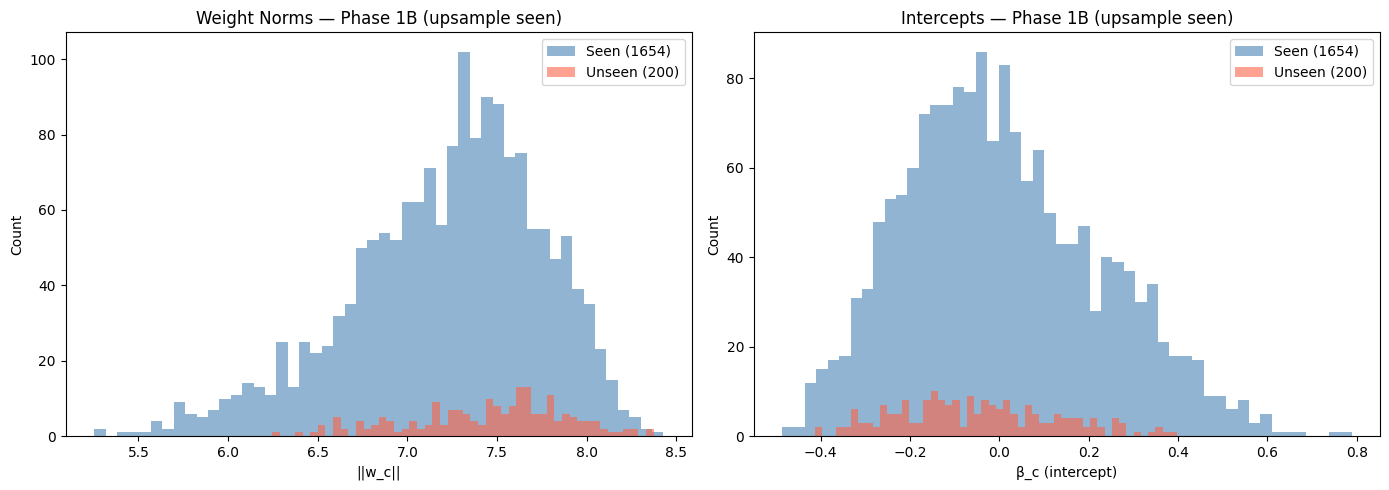

Saved: figures/phase_1b_(upsample_seen)_diagnostics.png


In [ ]:
# =============================================================================
# PHASE 1B: UPSAMPLE SEEN (SECONDARY EXPERIMENT)
# =============================================================================
# Generate additional seen-class embeddings using the EXISTING generator
# with SEEN prototypes. This raises seen per-class count to ~20.
# Note: these synthetic seen embeddings will have the same low-variance
# property as synthetic unseen — this is diagnostically informative.

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator.eval()

z_dim = 100  # from WGAN config
target_total = 20  # target per-class

rng = np.random.RandomState(42)
synth_seen_list = []
synth_seen_labels = []

with torch.no_grad():
    for i, c in enumerate(seen_classes_train):
        # How many real samples does this class have?
        n_real = seen_counts[i]
        n_to_generate = max(0, target_total - n_real)

        if n_to_generate > 0:
            # Get prototype for this class
            proto_idx = i  # assuming prototypes are ordered same as seen_classes_train
            s_c = torch.tensor(S_seen_array[proto_idx], dtype=torch.float32).unsqueeze(0).to(device)
            s_c = s_c.expand(n_to_generate, -1)

            z = torch.randn(n_to_generate, z_dim, device=device)
            fake = generator(z, s_c).cpu().numpy()
            synth_seen_list.append(fake)
            synth_seen_labels.append(np.full(n_to_generate, c))

if synth_seen_list:
    E_synth_seen = np.vstack(synth_seen_list)
    y_synth_seen = np.concatenate(synth_seen_labels)
    print(f"Generated {len(E_synth_seen)} synthetic seen embeddings "
          f"across {len(synth_seen_list)} classes needing augmentation")
else:
    E_synth_seen = np.empty((0, E_train_seen.shape[1]))
    y_synth_seen = np.array([], dtype=y_train_seen.dtype)
    print("No seen classes needed augmentation.")

# Combine: real seen + synth seen + full synthetic unseen (20/class)
E_train_p1b = np.vstack([E_train_seen, E_synth_seen, E_synth_unseen])
y_train_p1b = np.concatenate([y_train_seen, y_synth_seen, y_synth_unseen_remapped])

print(f"\nPhase 1B training set: {E_train_p1b.shape[0]} samples")
print(f"  Real seen: {len(E_train_seen)}, Synth seen: {len(E_synth_seen)}, "
      f"Synth unseen: {len(E_synth_unseen)}")

# Train LogReg
clf_p1b = LogisticRegression(
    max_iter=5000,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42,
    C=1.0,
)
clf_p1b.fit(E_train_p1b, y_train_p1b)
print("LogReg fitted.")

# Evaluate
p1b_results = evaluate_gzsl(
    clf_p1b, E_test_seen, y_test_seen, E_unseen, y_unseen_remapped,
    seen_labels_set, unseen_labels_set, phase_name="Phase 1B (upsample seen)"
)
all_phase_results['P1B: Upsample Seen'] = p1b_results

# Diagnostics
p1b_diag = diagnose_classifier(
    clf_p1b, seen_labels_set, unseen_labels_set, phase_name="Phase 1B (upsample seen)"
)



PHASE COMPARISON
                 Phase   AccS   AccU      H  Routing Rate
   Method D (baseline) 0.0018 0.0236 0.0034        0.9855
P1A: Downsample Unseen 0.0308 0.0034 0.0062        0.1028
    P1B: Upsample Seen 0.0281 0.0038 0.0067        0.0989


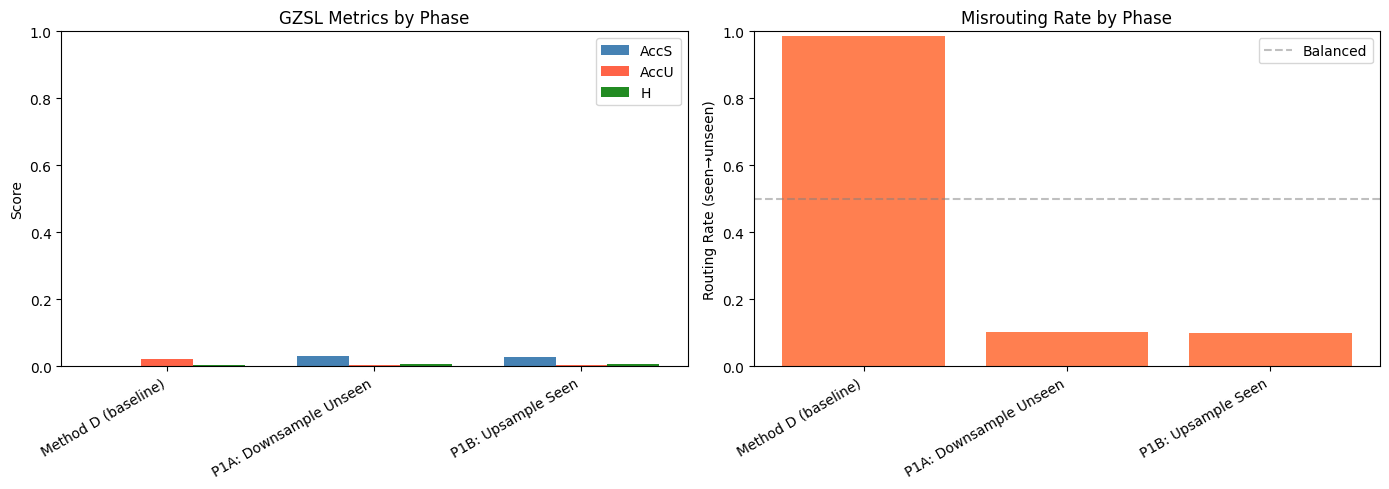

Saved: figures/phase_comparison.png

Interpretation:
- If P1A improves AccS but barely touches AccU → M2 contributes but isn't dominant
- If P1B (upsample seen) does NOT help → the issue is variance, not count
- If P1B matches P1A → variance mismatch is symmetric and M2 is the main driver
- Routing rate is the key metric: how far does it move from 99.6%?


In [ ]:
# =============================================================================
# PHASE 1 COMPARISON
# =============================================================================

compare_phases(all_phase_results)

print("\nInterpretation:")
print("- If P1A improves AccS but barely touches AccU → M2 contributes but isn't dominant")
print("- If P1B (upsample seen) does NOT help → the issue is variance, not count")
print("- If P1B matches P1A → variance mismatch is symmetric and M2 is the main driver")
print("- Routing rate is the key metric: how far does it move from 99.6%?")


---

# Upstream Bottleneck Diagnostics

**Goal:** Identify where the representation bottleneck lies — CLIP encoder, WGAN-GP generator, or text prototypes.

Phase 1 fixed calibration (routing rate ~9%). Discriminative power is near-floor (H ≈ 0.4%).
Three diagnostics isolate the bottleneck:
- **Diag A**: Seen-only classification — is the CLIP encoder learning useful features?
- **Diag B**: Unseen-only classification — is the generator producing class-discriminable synthetics?
- **Diag C**: Prototype spread — are the text prototypes separable in R^128?


In [ ]:
# =============================================================================
# DIAGNOSTIC A: SEEN-ONLY 1654-WAY CLASSIFICATION
# =============================================================================
# Question: Does f_b (CLIP brain encoder) produce embeddings that carry
# enough class-discriminative signal for seen classes?
#
# Method: Train LogReg on E_train_seen, test on E_test_seen.
# This is a pure encoder quality test — no generator, no unseen classes.
# =============================================================================

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, top_k_accuracy_score
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

# Load cached embeddings
E_train_seen = np.load('cached_arrays/E_train_seen.npy')
E_test_seen = np.load('cached_arrays/E_test_seen.npy')
y_train_seen = np.load('cached_arrays/y_train_seen.npy')
y_test_seen = np.load('cached_arrays/y_test_seen.npy')

# Standardise (fit on train only)
scaler = StandardScaler()
E_train_s = scaler.fit_transform(E_train_seen)
E_test_s = scaler.transform(E_test_seen)

n_classes_seen = len(np.unique(y_train_seen))
random_baseline = 1.0 / n_classes_seen

print(f"Seen-only classification: {n_classes_seen} classes")
print(f"Train: {E_train_s.shape}, Test: {E_test_s.shape}")
print(f"Random baseline: {random_baseline:.4f} ({random_baseline*100:.2f}%)\n")

# Train LogReg
clf_seen = LogisticRegression(
    max_iter=2000, solver='lbfgs', C=1.0, random_state=SEED,
    multi_class='multinomial', n_jobs=-1
)
clf_seen.fit(E_train_s, y_train_seen)

# Evaluate
y_pred = clf_seen.predict(E_test_s)
acc_top1 = accuracy_score(y_test_seen, y_pred)

# Top-5 accuracy
y_proba = clf_seen.predict_proba(E_test_s)
acc_top5 = top_k_accuracy_score(y_test_seen, y_proba, k=5, labels=clf_seen.classes_)

# Top-10 accuracy
acc_top10 = top_k_accuracy_score(y_test_seen, y_proba, k=10, labels=clf_seen.classes_)

# Signal-above-random ratio
signal_ratio = acc_top1 / random_baseline

print("=" * 60)
print("DIAGNOSTIC A RESULTS: Seen-Only Classification")
print("=" * 60)
print(f"  Top-1 Accuracy:  {acc_top1:.4f} ({acc_top1*100:.2f}%)")
print(f"  Top-5 Accuracy:  {acc_top5:.4f} ({acc_top5*100:.2f}%)")
print(f"  Top-10 Accuracy: {acc_top10:.4f} ({acc_top10*100:.2f}%)")
print(f"  Random baseline: {random_baseline:.4f} ({random_baseline*100:.2f}%)")
print(f"  Signal ratio:    {signal_ratio:.1f}x above random\n")

# Interpretation
if acc_top1 > 0.05:
    print(">>> CLIP encoder captures MODERATE signal. Bottleneck likely downstream.")
elif acc_top1 > 0.01:
    print(">>> CLIP encoder captures WEAK signal. Encoder improvement may help.")
else:
    print(">>> CLIP encoder captures MINIMAL signal. Encoder is a primary bottleneck.")


Seen-only classification: 1654 classes
Train: (13232, 128), Test: (3308, 128)
Random baseline: 0.0006 (0.06%)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


DIAGNOSTIC A RESULTS: Seen-Only Classification
  Top-1 Accuracy:  0.0239 (2.39%)
  Top-5 Accuracy:  0.0856 (8.56%)
  Top-10 Accuracy: 0.1297 (12.97%)
  Random baseline: 0.0006 (0.06%)
  Signal ratio:    39.5x above random

>>> CLIP encoder captures WEAK signal. Encoder improvement may help.


In [ ]:
# =============================================================================
# DIAGNOSTIC B: UNSEEN-ONLY 200-WAY CLASSIFICATION
# =============================================================================
# Question: Does G(z, s_c) produce embeddings that carry class identity?
#
# Method 1 (B1): Train LogReg on E_synth_unseen, test on E_unseen (real).
#   This is the transfer test — can synthetics classify real data?
#
# Method 2 (B2): 5-fold cross-validation on E_synth_unseen only.
#   This tests internal discriminability — are synthetics at least
#   distinct from each other across classes?
# =============================================================================

from sklearn.model_selection import cross_val_score

E_unseen = np.load('cached_arrays/E_unseen.npy')
E_synth_unseen = np.load('cached_arrays/E_synth_unseen.npy')
y_unseen = np.load('cached_arrays/y_unseen.npy')
y_synth_unseen = np.load('cached_arrays/y_synth_unseen.npy')

n_classes_unseen = len(np.unique(y_unseen))
random_baseline_u = 1.0 / n_classes_unseen

print(f"Unseen-only classification: {n_classes_unseen} classes")
print(f"Synthetic train: {E_synth_unseen.shape}")
print(f"Real unseen test: {E_unseen.shape}")
print(f"Random baseline: {random_baseline_u:.4f} ({random_baseline_u*100:.2f}%)\n")

# --- B1: Train on synthetic, test on real ---
scaler_u = StandardScaler()
E_synth_s = scaler_u.fit_transform(E_synth_unseen)
E_unseen_s = scaler_u.transform(E_unseen)

clf_unseen = LogisticRegression(
    max_iter=2000, solver='lbfgs', C=1.0, random_state=SEED,
    multi_class='multinomial', n_jobs=-1
)
clf_unseen.fit(E_synth_s, y_synth_unseen)

y_pred_u = clf_unseen.predict(E_unseen_s)
acc_b1 = accuracy_score(y_unseen, y_pred_u)

y_proba_u = clf_unseen.predict_proba(E_unseen_s)
acc_b1_top5 = top_k_accuracy_score(y_unseen, y_proba_u, k=5, labels=clf_unseen.classes_)

signal_ratio_b1 = acc_b1 / random_baseline_u

# --- B2: Cross-val on synthetics only ---
clf_cv = LogisticRegression(
    max_iter=2000, solver='lbfgs', C=1.0, random_state=SEED,
    multi_class='multinomial', n_jobs=-1
)
cv_scores = cross_val_score(clf_cv, E_synth_s, y_synth_unseen, cv=5, scoring='accuracy')
acc_b2_mean = cv_scores.mean()
acc_b2_std = cv_scores.std()
signal_ratio_b2 = acc_b2_mean / random_baseline_u

print("=" * 60)
print("DIAGNOSTIC B RESULTS: Unseen-Only Classification")
print("=" * 60)
print("\nB1: Synthetic → Real Transfer")
print(f"  Top-1 Accuracy:  {acc_b1:.4f} ({acc_b1*100:.2f}%)")
print(f"  Top-5 Accuracy:  {acc_b1_top5:.4f} ({acc_b1_top5*100:.2f}%)")
print(f"  Signal ratio:    {signal_ratio_b1:.1f}x above random\n")
print("B2: Synthetic Internal Discriminability (5-fold CV)")
print(f"  Accuracy:        {acc_b2_mean:.4f} ± {acc_b2_std:.4f}")
print(f"  Signal ratio:    {signal_ratio_b2:.1f}x above random\n")

# Interpretation
if acc_b2_mean > 0.10 and acc_b1 < 0.02:
    print(">>> Synthetics are internally discriminable but don't transfer to real data.")
    print("    Generator captures some structure but doesn't match real EEG distribution.")
elif acc_b2_mean < 0.02:
    print(">>> Synthetics are NOT internally discriminable. Generator is mode-collapsed.")
    print("    Generator is a primary bottleneck.")
elif acc_b1 > 0.02:
    print(">>> Synthetics transfer reasonably to real data. Generator is not the bottleneck.")
else:
    print(">>> Mixed signal. Check prototype analysis (Diagnostic C) for root cause.")


Unseen-only classification: 200 classes
Synthetic train: (4000, 128)
Real unseen test: (16000, 128)
Random baseline: 0.0050 (0.50%)



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

DIAGNOSTIC B RESULTS: Unseen-Only Classification

B1: Synthetic → Real Transfer
  Top-1 Accuracy:  0.0221 (2.21%)
  Top-5 Accuracy:  0.0895 (8.95%)
  Signal ratio:    4.4x above random

B2: Synthetic Internal Discriminability (5-fold CV)
  Accuracy:        0.8307 ± 0.0105
  Signal ratio:    166.1x above random

>>> Synthetics transfer reasonably to real data. Generator is not the bottleneck.


In [ ]:
# =============================================================================
# DIAGNOSTIC C: PROTOTYPE SPREAD ANALYSIS
# =============================================================================
# Question: Are the 200 unseen text prototypes separable in R^128?
#
# If prototypes cluster tightly (high pairwise cosine), then even a
# perfect generator cannot produce discriminable embeddings because
# G(z, s_c) ≈ G(z, s_{c'}) when s_c ≈ s_{c'}.
#
# Reference: For random unit vectors in R^d, E[cos(u,v)] = 0,
# Var[cos(u,v)] ≈ 1/d. So for d=128, std ≈ 0.088.
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

S_unseen = np.load('cached_arrays/S_unseen_prototypes.npy')
S_seen = np.load('cached_arrays/S_seen_prototypes.npy')

print(f"Unseen prototypes: {S_unseen.shape}")
print(f"Seen prototypes: {S_seen.shape}\n")

# --- Unseen pairwise cosine similarity ---
cos_sim_unseen = cosine_similarity(S_unseen)
n_u = cos_sim_unseen.shape[0]
# Extract upper triangle (off-diagonal)
mask = np.triu(np.ones((n_u, n_u), dtype=bool), k=1)
off_diag_unseen = cos_sim_unseen[mask]

# --- Seen pairwise cosine similarity (for comparison) ---
cos_sim_seen = cosine_similarity(S_seen)
n_s = cos_sim_seen.shape[0]
mask_s = np.triu(np.ones((n_s, n_s), dtype=bool), k=1)
off_diag_seen = cos_sim_seen[mask_s]

# --- Statistics ---
print("=" * 60)
print("DIAGNOSTIC C RESULTS: Prototype Spread")
print("=" * 60)
print("\n")
print(f"{'Metric':<25} {'Unseen (200)':>15} {'Seen (1654)':>15}")
print("-" * 55)
print(f"{'Mean cosine':<25} {off_diag_unseen.mean():>15.4f} {off_diag_seen.mean():>15.4f}")
print(f"{'Median cosine':<25} {np.median(off_diag_unseen):>15.4f} {np.median(off_diag_seen):>15.4f}")
print(f"{'Std cosine':<25} {off_diag_unseen.std():>15.4f} {off_diag_seen.std():>15.4f}")
print(f"{'Min cosine':<25} {off_diag_unseen.min():>15.4f} {off_diag_seen.min():>15.4f}")
print(f"{'Max cosine':<25} {off_diag_unseen.max():>15.4f} {off_diag_seen.max():>15.4f}")
print(f"{'% pairs > 0.9':<25} {(off_diag_unseen > 0.9).mean()*100:>14.1f}% {(off_diag_seen > 0.9).mean()*100:>14.1f}%")
print(f"{'% pairs > 0.95':<25} {(off_diag_unseen > 0.95).mean()*100:>14.1f}% {(off_diag_seen > 0.95).mean()*100:>14.1f}%\n")
print(f"Random unit vectors in R^64: E[cos] ≈ 0, std ≈ {1/np.sqrt(64):.3f}\n")

# --- Nearest-neighbour analysis ---
# For each prototype, what's the cosine to its nearest neighbour?
np.fill_diagonal(cos_sim_unseen, -1)  # exclude self
nn_cos_unseen = cos_sim_unseen.max(axis=1)
np.fill_diagonal(cos_sim_seen, -1)
nn_cos_seen = cos_sim_seen.max(axis=1)

print(f"Nearest-neighbour cosine (unseen): mean={nn_cos_unseen.mean():.4f}, min={nn_cos_unseen.min():.4f}, max={nn_cos_unseen.max():.4f}")
print(f"Nearest-neighbour cosine (seen):   mean={nn_cos_seen.mean():.4f}, min={nn_cos_seen.min():.4f}, max={nn_cos_seen.max():.4f}\n")

# Interpretation
if off_diag_unseen.mean() > 0.8:
    print(">>> CRITICAL: Unseen prototypes are highly clustered (mean cos > 0.8).")
    print("    No generator can produce discriminable embeddings from near-identical conditions.")
    print("    Prototypes are a primary bottleneck.")
elif off_diag_unseen.mean() > 0.5:
    print(">>> WARNING: Unseen prototypes have moderate overlap (mean cos > 0.5).")
    print("    Generator needs to be very expressive to overcome prototype similarity.")
elif off_diag_unseen.mean() > 0.2:
    print(">>> Unseen prototypes have mild overlap. Spread is suboptimal but workable.")
else:
    print(">>> Prototypes are well-separated. Bottleneck is NOT in the semantic space.")


Unseen prototypes: (200, 128)
Seen prototypes: (1654, 128)

DIAGNOSTIC C RESULTS: Prototype Spread


Metric                       Unseen (200)     Seen (1654)
-------------------------------------------------------
Mean cosine                        0.0128         -0.0003
Median cosine                      0.0072         -0.0112
Std cosine                         0.2300          0.2303
Min cosine                        -0.7272         -0.8367
Max cosine                         0.9755          0.9816
% pairs > 0.9                        0.0%            0.0%
% pairs > 0.95                       0.0%            0.0%

Random unit vectors in R^64: E[cos] ≈ 0, std ≈ 0.125

Nearest-neighbour cosine (unseen): mean=0.6405, min=0.4196, max=0.9755
Nearest-neighbour cosine (seen):   mean=0.7816, min=0.5779, max=0.9816

>>> Prototypes are well-separated. Bottleneck is NOT in the semantic space.


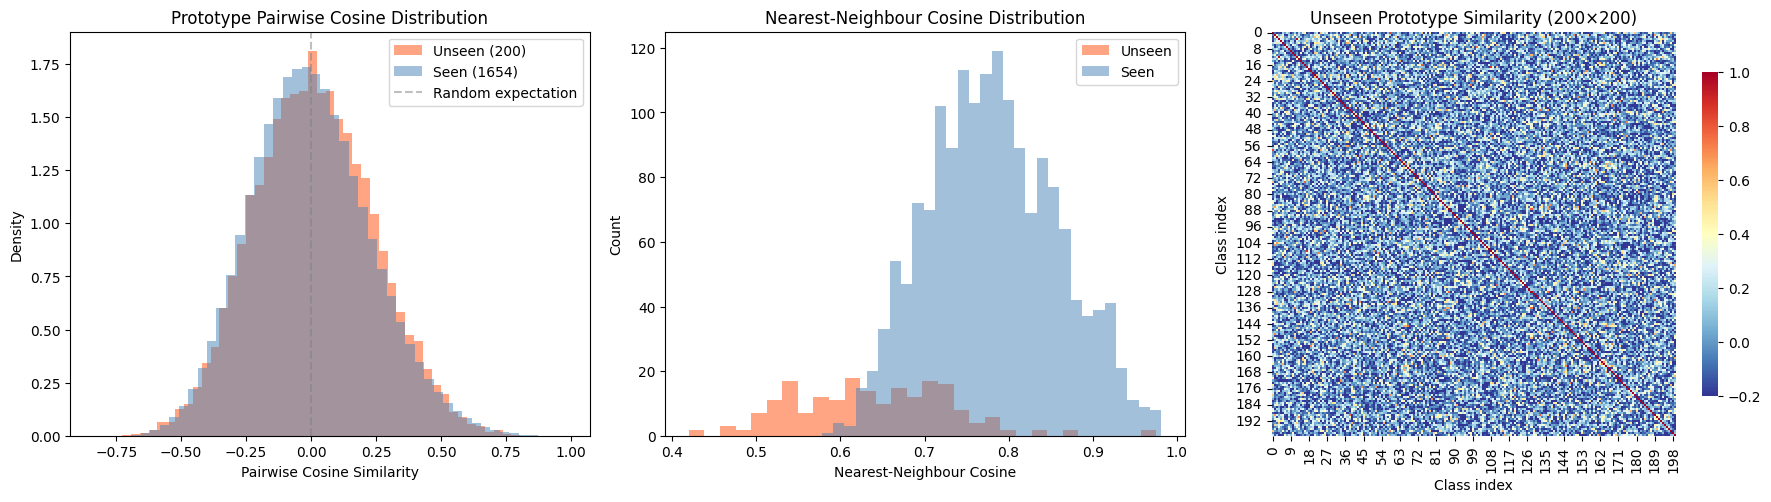

Saved: figures/upstream_diag_c_prototypes.png


In [ ]:
# =============================================================================
# DIAGNOSTIC C: VISUALISATION
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Histogram of pairwise cosine similarities
axes[0].hist(off_diag_unseen, bins=50, alpha=0.7, label='Unseen (200)', density=True, color='coral')
axes[0].hist(off_diag_seen, bins=50, alpha=0.5, label='Seen (1654)', density=True, color='steelblue')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='Random expectation')
axes[0].set_xlabel('Pairwise Cosine Similarity')
axes[0].set_ylabel('Density')
axes[0].set_title('Prototype Pairwise Cosine Distribution')
axes[0].legend()

# 2. Nearest-neighbour cosine distribution
axes[1].hist(nn_cos_unseen, bins=30, alpha=0.7, label='Unseen', color='coral')
axes[1].hist(nn_cos_seen, bins=30, alpha=0.5, label='Seen', color='steelblue')
axes[1].set_xlabel('Nearest-Neighbour Cosine')
axes[1].set_ylabel('Count')
axes[1].set_title('Nearest-Neighbour Cosine Distribution')
axes[1].legend()

# 3. Cosine similarity heatmap (unseen only, sorted)
# Reset diagonal for heatmap
np.fill_diagonal(cos_sim_unseen, 1.0)
import seaborn as sns
sns.heatmap(cos_sim_unseen, cmap='RdYlBu_r', vmin=-0.2, vmax=1.0,
            square=True, ax=axes[2], cbar_kws={'shrink': 0.8})
axes[2].set_title(f'Unseen Prototype Similarity ({n_u}×{n_u})')
axes[2].set_xlabel('Class index')
axes[2].set_ylabel('Class index')

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/upstream_diag_c_prototypes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/upstream_diag_c_prototypes.png")


In [ ]:
# =============================================================================
# UPSTREAM DIAGNOSTICS: SUMMARY & BOTTLENECK VERDICT
# =============================================================================

print("=" * 70)
print("UPSTREAM BOTTLENECK DIAGNOSTICS — SUMMARY")
print("=" * 70)
print()

# Collect results
results = {
    'A_seen_top1': acc_top1,
    'A_seen_top5': acc_top5,
    'A_seen_signal': signal_ratio,
    'B1_transfer_top1': acc_b1,
    'B1_transfer_signal': signal_ratio_b1,
    'B2_internal_acc': acc_b2_mean,
    'B2_internal_signal': signal_ratio_b2,
    'C_mean_cos_unseen': off_diag_unseen.mean(),
    'C_mean_cos_seen': off_diag_seen.mean(),
    'C_nn_cos_unseen': nn_cos_unseen.mean(),
}

print(f"{'Diagnostic':<45} {'Value':>10} {'Signal':>10}")
print("-" * 65)
print(f"{'A: Seen top-1 acc (1654-way)':<45} {acc_top1*100:>9.2f}% {signal_ratio:>9.1f}x")
print(f"{'A: Seen top-5 acc':<45} {acc_top5*100:>9.2f}%")
print(f"{'B1: Synth→Real transfer acc (200-way)':<45} {acc_b1*100:>9.2f}% {signal_ratio_b1:>9.1f}x")
print(f"{'B2: Synth internal CV acc (200-way)':<45} {acc_b2_mean*100:>9.2f}% {signal_ratio_b2:>9.1f}x")
print(f"{'C: Unseen prototype mean cosine':<45} {off_diag_unseen.mean():>10.4f}")
print(f"{'C: Seen prototype mean cosine (ref)':<45} {off_diag_seen.mean():>10.4f}")
print(f"{'C: Unseen NN cosine mean':<45} {nn_cos_unseen.mean():>10.4f}\n")

# --- Bottleneck verdict ---
print("BOTTLENECK ANALYSIS:")
print("-" * 65)

bottlenecks = []

# Encoder assessment
if acc_top1 < 0.01:
    bottlenecks.append(("CLIP Encoder", "CRITICAL", f"top-1 = {acc_top1*100:.2f}%, barely above random"))
elif acc_top1 < 0.05:
    bottlenecks.append(("CLIP Encoder", "WEAK", f"top-1 = {acc_top1*100:.2f}%, limited signal"))
else:
    bottlenecks.append(("CLIP Encoder", "OK", f"top-1 = {acc_top1*100:.2f}%, reasonable signal"))

# Generator assessment
if acc_b2_mean < 0.02:
    bottlenecks.append(("WGAN-GP Generator", "CRITICAL", f"internal CV = {acc_b2_mean*100:.2f}%, mode-collapsed"))
elif acc_b1 < 0.01:
    bottlenecks.append(("WGAN-GP Generator", "WEAK", f"transfer = {acc_b1*100:.2f}%, poor real-data match"))
else:
    bottlenecks.append(("WGAN-GP Generator", "OK", f"transfer = {acc_b1*100:.2f}%"))

# Prototype assessment
if off_diag_unseen.mean() > 0.8:
    bottlenecks.append(("Text Prototypes", "CRITICAL", f"mean cos = {off_diag_unseen.mean():.3f}, highly clustered"))
elif off_diag_unseen.mean() > 0.5:
    bottlenecks.append(("Text Prototypes", "CONCERNING", f"mean cos = {off_diag_unseen.mean():.3f}, moderate overlap"))
else:
    bottlenecks.append(("Text Prototypes", "OK", f"mean cos = {off_diag_unseen.mean():.3f}, adequate spread"))

for component, severity, detail in bottlenecks:
    print(f"  [{severity:>10}] {component}: {detail}")

print()
print("NEXT STEPS (to be decided by orchestrator based on these results):")
print("  - If Encoder CRITICAL → increase embed_dim, train longer, curriculum learning")
print("  - If Generator CRITICAL → covariance-aware WGAN, more training steps, architecture changes")
print("  - If Prototypes CRITICAL → better text features, larger semantic space, alternative alignment")
print("  - If multiple CRITICAL → address upstream first (prototypes → encoder → generator)\n")


UPSTREAM BOTTLENECK DIAGNOSTICS — SUMMARY

Diagnostic                                         Value     Signal
-----------------------------------------------------------------
A: Seen top-1 acc (1654-way)                       2.39%      39.5x
A: Seen top-5 acc                                  8.56%
B1: Synth→Real transfer acc (200-way)              2.21%       4.4x
B2: Synth internal CV acc (200-way)               83.07%     166.1x
C: Unseen prototype mean cosine                   0.0128
C: Seen prototype mean cosine (ref)              -0.0003
C: Unseen NN cosine mean                          0.6405

BOTTLENECK ANALYSIS:
-----------------------------------------------------------------
  [      WEAK] CLIP Encoder: top-1 = 2.39%, limited signal
  [        OK] WGAN-GP Generator: transfer = 2.21%
  [        OK] Text Prototypes: mean cos = 0.013, adequate spread

NEXT STEPS (to be decided by orchestrator based on these results):
  - If Encoder CRITICAL → increase embed_dim, train longer,

---

# Phase F: Regularisation, Contrastive Learning & Structured Architecture

**Goal:** Improve CLIP encoder internal representation quality by attacking the three root causes of shortcut learning:

1. **F1 — Data Augmentation**: Inject noise and transformations to combat overfitting (dominant signal from Phase E)
2. **F2 — Supervised Contrastive Loss**: Exploit multi-trial class structure (10 trials/class) for stronger learning signal
3. **F3 — Structured Encoder**: Replace flat MLP with EEGNet to exploit spatial-temporal structure (17ch × 33t)

**Method**: Three-stage sequential elimination sweep. Each stage builds on the previous winner.

**Baseline**: Phase E best — 2.87% top-1 (MLP+LayerNorm, dim=128, lr=1e-3, cosine warmup, τ=0.15, 50 epochs)

In [ ]:
# =============================================================================
# PHASE F: EXPERIMENT INFRASTRUCTURE
# =============================================================================
# Augmentation, SupCon loss, class-balanced sampling, EEGNet, ShallowConvNet,
# unified experiment runner, evaluation.

import math
import random
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Sampler
from sklearn.linear_model import LogisticRegression
import numpy as np

# ---- Constants ----
N_CHANNELS = 17
N_TIMES = 33
N_SEEN_CLASSES = 1654

# =============================================================================
# 1. DATA AUGMENTATION
# =============================================================================

class EEGAugmentation:
    """
    On-the-fly EEG data augmentation operating on (17, 33) spatial-temporal structure.
    Accepts (B, 561) tensors, reshapes internally, applies augmentations, returns (B, 561).
    """
    def __init__(self, config):
        self.gaussian_std = config.get('gaussian_std', 0.0)
        self.time_shift = config.get('time_shift', 0)
        self.channel_drop_prob = config.get('channel_drop_prob', 0.0)
        self.time_mask_width = config.get('time_mask_width', 0)
        self.mixup_alpha = config.get('mixup_alpha', 0.0)

    def __call__(self, brain_batch, text_batch=None):
        """
        Apply augmentations to a batch of EEG data.
        Args:
            brain_batch: (B, 561) tensor
            text_batch: (B, D) tensor (needed for mixup to keep pairs aligned)
        Returns:
            augmented brain_batch (B, 561), optionally augmented text_batch
        """
        B = brain_batch.shape[0]
        device = brain_batch.device
        x = brain_batch.view(B, N_CHANNELS, N_TIMES)

        # Gaussian noise
        if self.gaussian_std > 0:
            noise = torch.randn_like(x) * self.gaussian_std
            x = x + noise

        # Time shift (circular)
        if self.time_shift > 0:
            shift = random.randint(-self.time_shift, self.time_shift)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=-1)

        # Channel dropout
        if self.channel_drop_prob > 0:
            mask = (torch.rand(B, N_CHANNELS, 1, device=device) > self.channel_drop_prob).float()
            x = x * mask

        # Time masking
        if self.time_mask_width > 0:
            start = random.randint(0, N_TIMES - self.time_mask_width)
            x[:, :, start:start + self.time_mask_width] = 0

        brain_out = x.view(B, -1)

        # Mixup (applied after other augmentations, mixes with rolled batch)
        if self.mixup_alpha > 0:
            lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)
            lam = max(lam, 1 - lam)  # ensure lam >= 0.5 (original dominates)
            brain_out = lam * brain_out + (1 - lam) * brain_out.roll(1, 0)
            if text_batch is not None:
                text_batch = lam * text_batch + (1 - lam) * text_batch.roll(1, 0)

        if text_batch is not None:
            return brain_out, text_batch
        return brain_out


# =============================================================================
# 2. LOSS FUNCTIONS
# =============================================================================

def supcon_loss(features, labels, tau=0.15):
    """
    Supervised Contrastive Loss (Khosla et al., 2020).
    All same-class pairs are positives, all different-class pairs are negatives.
    Self-pairs are excluded.

    Args:
        features: (B, d) L2-normalised embeddings
        labels: (B,) integer class labels
        tau: temperature
    Returns:
        Scalar loss
    """
    device = features.device
    B = features.shape[0]

    # Cosine similarity / tau
    sim = torch.matmul(features, features.T) / tau  # (B, B)

    # Positive mask: same class, exclude self
    labels_col = labels.unsqueeze(1)  # (B, 1)
    pos_mask = (labels_col == labels_col.T).float()  # (B, B)
    pos_mask.fill_diagonal_(0)

    # Numerical stability
    logits_max, _ = sim.max(dim=1, keepdim=True)
    sim = sim - logits_max.detach()

    # Denominator: sum over all j != i
    exp_sim = torch.exp(sim)
    self_mask = 1.0 - torch.eye(B, device=device)
    denom = (exp_sim * self_mask).sum(dim=1, keepdim=True)  # (B, 1)

    # Log probability of each pair
    log_prob = sim - torch.log(denom + 1e-8)  # (B, B)

    # Mean log-prob over positives for each anchor
    n_pos = pos_mask.sum(dim=1)  # (B,)
    mean_log_prob = (pos_mask * log_prob).sum(dim=1) / (n_pos + 1e-8)

    # Average over anchors with at least one positive
    valid = n_pos > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=device, requires_grad=True)
    return -mean_log_prob[valid].mean()


def combined_loss(brain_embeds, text_embeds, labels, tau=0.15, lambda_sup=0.5):
    """
    Combined loss: lambda * SupCon(EEG<->EEG) + (1-lambda) * InfoNCE(EEG<->Text).
    """
    l_sup = supcon_loss(brain_embeds, labels, tau)
    l_nce = clip_loss(brain_embeds, text_embeds, tau)
    return lambda_sup * l_sup + (1.0 - lambda_sup) * l_nce


# =============================================================================
# 3. CLASS-BALANCED BATCH SAMPLER
# =============================================================================

class ClassBalancedBatchSampler(Sampler):
    """
    Yields batches of K classes x M instances = K*M samples.
    Ensures every sample has M-1 same-class partners for SupCon.
    """
    def __init__(self, labels, K=64, M=4, n_batches=52):
        self.labels = np.array(labels)
        self.K = K
        self.M = M
        self.n_batches = n_batches

        self.class_to_indices = {}
        for idx, lab in enumerate(self.labels):
            self.class_to_indices.setdefault(int(lab), []).append(idx)
        self.classes = list(self.class_to_indices.keys())

    def __iter__(self):
        for _ in range(self.n_batches):
            selected = random.sample(self.classes, min(self.K, len(self.classes)))
            batch = []
            for cls in selected:
                indices = self.class_to_indices[cls]
                if len(indices) >= self.M:
                    batch.extend(random.sample(indices, self.M))
                else:
                    batch.extend(random.choices(indices, k=self.M))
            yield batch

    def __len__(self):
        return self.n_batches


# =============================================================================
# 4. ENCODER ARCHITECTURES
# =============================================================================

class EEGNetEncoder(nn.Module):
    """
    EEGNet (Lawhern et al., 2018) adapted for contrastive learning.
    Input: (B, 561) flattened EEG -> reshape to (B, 1, 17, 33) internally.
    Output: (B, embed_dim) L2-normalised.

    Args:
        F1: number of temporal filters
        D: depth multiplier for spatial filters
        F2: number of pointwise filters
        kern_t: temporal kernel size
        kern_s: separable temporal kernel size
        embed_dim: output embedding dimension
        dropout: dropout rate
    """
    def __init__(self, F1=8, D=2, F2=16, kern_t=9, kern_s=5,
                 embed_dim=128, dropout=0.25, **kwargs):
        super().__init__()

        # Block 1: Temporal convolution
        self.conv_temporal = nn.Conv2d(1, F1, (1, kern_t), padding=(0, kern_t // 2), bias=False)
        self.bn1 = nn.BatchNorm2d(F1)

        # Block 2: Depthwise spatial convolution
        self.conv_spatial = nn.Conv2d(F1, F1 * D, (N_CHANNELS, 1), groups=F1, bias=False)
        self.bn2 = nn.BatchNorm2d(F1 * D)
        self.pool1 = nn.AvgPool2d((1, 4))
        self.drop1 = nn.Dropout(dropout)

        # Block 3: Separable convolution
        self.conv_sep_depth = nn.Conv2d(F1 * D, F1 * D, (1, kern_s),
                                        padding=(0, kern_s // 2), groups=F1 * D, bias=False)
        self.conv_sep_point = nn.Conv2d(F1 * D, F2, (1, 1), bias=False)
        self.bn3 = nn.BatchNorm2d(F2)
        self.pool2 = nn.AvgPool2d((1, 2))
        self.drop2 = nn.Dropout(dropout)

        # Compute flattened size
        t_after_pool1 = N_TIMES // 4  # 33 // 4 = 8
        t_after_pool2 = t_after_pool1 // 2  # 8 // 2 = 4
        flat_size = F2 * t_after_pool2

        # Head
        self.fc = nn.Linear(flat_size, embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = x.view(B, 1, N_CHANNELS, N_TIMES)  # (B, 1, 17, 33)

        # Block 1
        x = self.bn1(self.conv_temporal(x))  # (B, F1, 17, 33)

        # Block 2
        x = self.conv_spatial(x)  # (B, F1*D, 1, 33)
        x = F.elu(self.bn2(x))
        x = self.drop1(self.pool1(x))  # (B, F1*D, 1, 8)

        # Block 3
        x = self.conv_sep_depth(x)  # (B, F1*D, 1, 8)
        x = self.conv_sep_point(x)  # (B, F2, 1, 8)
        x = F.elu(self.bn3(x))
        x = self.drop2(self.pool2(x))  # (B, F2, 1, 4)

        # Head
        x = x.flatten(1)  # (B, F2*4)
        x = self.fc(x)  # (B, embed_dim)
        return F.normalize(x, p=2, dim=-1)


class ShallowConvEncoder(nn.Module):
    """
    ShallowConvNet (Schirrmeister et al., 2017) adapted for contrastive learning.
    Uses square-log activation designed for EEG band power extraction.
    Input: (B, 561) -> reshape to (B, 1, 17, 33).
    Output: (B, embed_dim) L2-normalised.
    """
    def __init__(self, n_filters=40, kern_t=13, embed_dim=128, dropout=0.5, **kwargs):
        super().__init__()

        self.conv_temporal = nn.Conv2d(1, n_filters, (1, kern_t),
                                       padding=(0, kern_t // 2), bias=False)
        self.conv_spatial = nn.Conv2d(n_filters, n_filters, (N_CHANNELS, 1), bias=False)
        self.bn = nn.BatchNorm2d(n_filters)
        self.pool = nn.AvgPool2d((1, 6), stride=(1, 3))
        self.drop = nn.Dropout(dropout)

        # Compute flattened size: time stays 33, spatial reduces to 1, pool: (33-6)//3 + 1 = 10
        t_after_pool = (N_TIMES - 6) // 3 + 1  # 10
        flat_size = n_filters * t_after_pool

        self.fc = nn.Linear(flat_size, embed_dim)

    def forward(self, x):
        B = x.shape[0]
        x = x.view(B, 1, N_CHANNELS, N_TIMES)

        x = self.conv_temporal(x)  # (B, 40, 17, 33)
        x = self.conv_spatial(x)   # (B, 40, 1, 33)
        x = self.bn(x)

        # Square-log activation (designed for EEG band power)
        x = x ** 2
        x = self.pool(x)  # (B, 40, 1, 10)
        x = torch.log(torch.clamp(x, min=1e-6))

        x = self.drop(x)
        x = x.flatten(1)  # (B, 400)
        x = self.fc(x)    # (B, embed_dim)
        return F.normalize(x, p=2, dim=-1)


# Architecture registry
ENCODER_REGISTRY = {
    'mlp_ln': lambda embed_dim=128, dropout=0.1, **kw: BrainEncoder(
        input_dim=561, embed_dim=embed_dim, dropout=dropout),
    'eegnet_small': lambda embed_dim=128, dropout=0.25, **kw: EEGNetEncoder(
        F1=8, D=2, F2=16, kern_t=9, kern_s=5, embed_dim=embed_dim, dropout=dropout),
    'eegnet_large': lambda embed_dim=128, dropout=0.25, **kw: EEGNetEncoder(
        F1=16, D=2, F2=32, kern_t=9, kern_s=5, embed_dim=embed_dim, dropout=dropout),
    'shallow_conv': lambda embed_dim=128, dropout=0.5, **kw: ShallowConvEncoder(
        n_filters=40, kern_t=13, embed_dim=embed_dim, dropout=dropout),
}


# =============================================================================
# 5. EVALUATION
# =============================================================================

def evaluate_encoder(encoder, text_proj, X_train, T_train, Y_train,
                     X_test, T_test, Y_test, device):
    """
    Evaluate encoder quality via seen-only LogReg classification.
    Returns dict with top-1, top-5, top-10, signal ratio.
    """
    encoder.eval()
    text_proj.eval()
    with torch.no_grad():
        E_train = encoder(X_train.to(device)).cpu().numpy()
        E_test = encoder(X_test.to(device)).cpu().numpy()

    clf = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42)
    clf.fit(E_train, Y_train)

    proba = clf.predict_proba(E_test)
    n_classes = proba.shape[1]

    results = {}
    for k in [1, 5, 10]:
        top_k_preds = np.argsort(proba, axis=1)[:, -k:]
        correct = np.array([Y_test[i] in top_k_preds[i] for i in range(len(Y_test))])
        results[f'top_{k}'] = correct.mean()

    results['signal'] = results['top_1'] / (1.0 / n_classes)
    results['n_classes'] = n_classes
    return results


# =============================================================================
# 6. UNIFIED EXPERIMENT RUNNER
# =============================================================================

# Global results accumulator
phase_f_results = []

def run_phase_f_experiment(config):
    """
    Run a single Phase F experiment.

    Config keys:
        name (str): experiment name
        encoder (str): key in ENCODER_REGISTRY
        embed_dim (int): embedding dimension (default 128)
        epochs (int): training epochs (default 50)
        lr (float): peak learning rate (default 1e-3)
        tau (float): contrastive temperature (default 0.15)
        schedule (str): 'cosine_warmup' or 'flat'
        loss_type (str): 'infonce', 'supcon', 'combined'
        lambda_sup (float): SupCon weight for combined loss (default 0.5)
        batch_mode (str): 'shuffle' or 'class_balanced'
        K (int): classes per batch for class_balanced (default 64)
        M (int): instances per class for class_balanced (default 4)
        augmentation (dict or None): augmentation config for EEGAugmentation
        dropout (float): dropout rate
        weight_decay (float): AdamW weight decay
    """
    name = config['name']
    embed_dim = config.get('embed_dim', 128)
    epochs = config.get('epochs', 50)
    lr = config.get('lr', 1e-3)
    tau = config.get('tau', 0.15)
    schedule = config.get('schedule', 'cosine_warmup')
    loss_type = config.get('loss_type', 'infonce')
    lambda_sup = config.get('lambda_sup', 0.5)
    batch_mode = config.get('batch_mode', 'shuffle')
    K = config.get('K', 64)
    M = config.get('M', 4)
    aug_config = config.get('augmentation', None)
    dropout = config.get('dropout', 0.1)
    weight_decay = config.get('weight_decay', 1e-4)
    encoder_name = config.get('encoder', 'mlp_ln')

    print(f"\n{'='*60}")
    print(f"EXPERIMENT: {name}")
    print(f"{'='*60}")
    print(f"  encoder={encoder_name}, embed_dim={embed_dim}, epochs={epochs}")
    print(f"  lr={lr}, schedule={schedule}, tau={tau}")
    print(f"  loss={loss_type}, batch={batch_mode}", end="")
    if batch_mode == 'class_balanced':
        print(f" (K={K}, M={M})", end="")
    print(f"\n  augmentation={aug_config}")

    # Seed
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    # Build encoder + text projector
    enc = ENCODER_REGISTRY[encoder_name](embed_dim=embed_dim, dropout=dropout).to(device)
    tp = TextProjector(input_dim=512, embed_dim=embed_dim).to(device)
    n_params = sum(p.numel() for p in enc.parameters()) + sum(p.numel() for p in tp.parameters())
    print(f"  Total parameters: {n_params:,}")

    # Build augmentation
    augment = EEGAugmentation(aug_config) if aug_config else None

    # Build data loader
    train_ds = TensorDataset(X_train_tensor, T_train_tensor, Y_train_tensor)
    if batch_mode == 'class_balanced':
        batch_sampler = ClassBalancedBatchSampler(
            label_train_seen, K=K, M=M, n_batches=len(train_loader)
        )
        loader = DataLoader(train_ds, batch_sampler=batch_sampler)
    else:
        loader = DataLoader(train_ds, batch_size=CLIP_CONFIG['batch_size'], shuffle=True)

    # Optimizer
    params = list(enc.parameters()) + list(tp.parameters())
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)

    # Scheduler
    total_steps = epochs * len(loader)
    warmup_steps = int(0.1 * total_steps) if schedule == 'cosine_warmup' else 0

    def lr_lambda(step):
        if warmup_steps > 0 and step < warmup_steps:
            return float(step) / float(max(1, warmup_steps))
        if schedule == 'cosine_warmup':
            progress = float(step - warmup_steps) / float(max(1, total_steps - warmup_steps))
            return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
        return 1.0

    sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    # Training
    t0 = time.time()
    losses = []

    for epoch in range(epochs):
        enc.train()
        tp.train()
        epoch_loss = 0.0

        for brain_batch, text_batch, label_batch in loader:
            brain_batch = brain_batch.to(device)
            text_batch = text_batch.to(device)
            label_batch = label_batch.to(device)

            # Augmentation
            if augment is not None:
                brain_batch, text_batch = augment(brain_batch, text_batch)

            # Forward
            brain_embeds = enc(brain_batch)
            text_embeds = tp(text_batch)

            # Loss
            if loss_type == 'infonce':
                loss = clip_loss(brain_embeds, text_embeds, tau)
            elif loss_type == 'supcon':
                loss = supcon_loss(brain_embeds, label_batch, tau)
            elif loss_type == 'combined':
                loss = combined_loss(brain_embeds, text_embeds, label_batch, tau, lambda_sup)
            else:
                raise ValueError(f"Unknown loss_type: {loss_type}")

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            sched.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        current_lr = sched.get_last_lr()[0]

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:3d}/{epochs}: loss={avg_loss:.4f}, lr={current_lr:.6f}")

    elapsed = time.time() - t0

    # Evaluate
    res = evaluate_encoder(
        enc, tp,
        X_train_tensor, T_train_tensor, label_train_seen,
        X_test_tensor, T_test_tensor, label_test_seen,
        device
    )

    print(f"\n  RESULTS: top-1={res['top_1']*100:.2f}%, top-5={res['top_5']*100:.2f}%, "
          f"top-10={res['top_10']*100:.2f}%, signal={res['signal']:.1f}x")
    print(f"  Time: {elapsed:.1f}s, Final loss: {losses[-1]:.4f}")

    result = {
        'name': name,
        'config': config,
        'top_1': res['top_1'],
        'top_5': res['top_5'],
        'top_10': res['top_10'],
        'signal': res['signal'],
        'final_loss': losses[-1],
        'time': elapsed,
        'losses': losses,
        'n_params': n_params,
        'encoder_obj': enc,
        'text_proj_obj': tp,
    }
    phase_f_results.append(result)
    return result


# Print readiness
print("Phase F experiment infrastructure ready.")
print(f"  Encoders: {list(ENCODER_REGISTRY.keys())}")
print(f"  Loss types: infonce, supcon, combined")
print(f"  Augmentations: gaussian, time_shift, channel_drop, time_mask, mixup")
print(f"  Baseline reference: top-1 = 2.87% (Phase E best)")

Phase F experiment infrastructure ready.
  Encoders: ['mlp_ln', 'eegnet_small', 'eegnet_large', 'shallow_conv']
  Loss types: infonce, supcon, combined
  Augmentations: gaussian, time_shift, channel_drop, time_mask, mixup
  Baseline reference: top-1 = 2.87% (Phase E best)


In [ ]:
# =============================================================================
# STAGE F1 ROUND 1: INDIVIDUAL AUGMENTATIONS
# =============================================================================
# Test each augmentation alone against the no-augmentation baseline.
# All use current best config: MLP+LN, dim=128, InfoNCE, standard batches.

print("STAGE F1 ROUND 1: Individual Augmentations")
print("=" * 60)

# Baseline (no augmentation) — control
run_phase_f_experiment({
    'name': 'F1-ctrl: no_aug',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': None,
})

# F1-A: Gaussian noise
run_phase_f_experiment({
    'name': 'F1-A: gaussian',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': {'gaussian_std': 0.3},
})

# F1-B: Time shift
run_phase_f_experiment({
    'name': 'F1-B: time_shift',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': {'time_shift': 2},
})

# F1-C: Channel dropout
run_phase_f_experiment({
    'name': 'F1-C: channel_drop',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': {'channel_drop_prob': 0.15},
})

# F1-D: Time masking
run_phase_f_experiment({
    'name': 'F1-D: time_mask',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': {'time_mask_width': 4},
})

# F1-E: Mixup
run_phase_f_experiment({
    'name': 'F1-E: mixup',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': {'mixup_alpha': 0.3},
})

# Summary
print(f"\n{'='*60}")
print("ROUND 1 RESULTS:")
r1_results = [r for r in phase_f_results if r['name'].startswith('F1-')]
r1_results_sorted = sorted(r1_results, key=lambda r: r['top_1'], reverse=True)
for r in r1_results_sorted:
    print(f"  {r['name']:<30s} top-1={r['top_1']*100:.2f}%  top-5={r['top_5']*100:.2f}%  signal={r['signal']:.1f}x")

# Select top 3
top3_augs = r1_results_sorted[:3]
print(f"\nTop 3 augmentations for Round 2: {[r['name'] for r in top3_augs]}")

STAGE F1 ROUND 1: Individual Augmentations

EXPERIMENT: F1-ctrl: no_aug
  encoder=mlp_ln, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=infonce, batch=shuffle
  augmentation=None
  Total parameters: 1,497,344
  Epoch   1/50: loss=5.4503, lr=0.000200
  Epoch  10/50: loss=2.5012, lr=0.000970
  Epoch  20/50: loss=1.5036, lr=0.000750
  Epoch  30/50: loss=1.1513, lr=0.000413
  Epoch  40/50: loss=1.0130, lr=0.000117
  Epoch  50/50: loss=0.9798, lr=0.000000

  RESULTS: top-1=0.03%, top-5=0.73%, top-10=1.09%, signal=0.5x
  Time: 5.5s, Final loss: 0.9798

EXPERIMENT: F1-A: gaussian
  encoder=mlp_ln, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=infonce, batch=shuffle
  augmentation={'gaussian_std': 0.3}
  Total parameters: 1,497,344
  Epoch   1/50: loss=5.4621, lr=0.000200
  Epoch  10/50: loss=2.7865, lr=0.000970
  Epoch  20/50: loss=1.7947, lr=0.000750
  Epoch  30/50: loss=1.3927, lr=0.000413
  Epoch  40/50: loss=1.2076, lr=0.000117

In [ ]:
# =============================================================================
# STAGE F1 ROUND 2: COMBINED AUGMENTATIONS
# =============================================================================
# Combine the top augmentations from Round 1.

print("STAGE F1 ROUND 2: Combined Augmentations")
print("=" * 60)

# Extract the augmentation configs from top 3
aug_configs_r1 = []
for r in top3_augs:
    if r['config']['augmentation'] is not None:
        aug_configs_r1.append(r['config']['augmentation'])

# Combine top 2
combo_top2 = {}
for cfg in aug_configs_r1[:2]:
    combo_top2.update(cfg)

run_phase_f_experiment({
    'name': 'F1-F: combo_top2',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': combo_top2,
})

# Combine top 3
combo_top3 = {}
for cfg in aug_configs_r1[:3]:
    combo_top3.update(cfg)

run_phase_f_experiment({
    'name': 'F1-G: combo_top3',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': combo_top3,
})

# All augmentations with reduced intensity
combo_all = {
    'gaussian_std': 0.15,
    'time_shift': 1,
    'channel_drop_prob': 0.1,
    'time_mask_width': 3,
    'mixup_alpha': 0.2,
}

run_phase_f_experiment({
    'name': 'F1-H: combo_all_mild',
    'encoder': 'mlp_ln',
    'loss_type': 'infonce',
    'batch_mode': 'shuffle',
    'augmentation': combo_all,
})

# Summary
print(f"\n{'='*60}")
print("ROUND 2 RESULTS:")
all_f1 = [r for r in phase_f_results if r['name'].startswith('F1-')]
all_f1_sorted = sorted(all_f1, key=lambda r: r['top_1'], reverse=True)
BEST_AUG = all_f1_sorted[0]
print(f"\nBEST AUGMENTATION: {BEST_AUG['name']} — top-1 = {BEST_AUG['top_1']*100:.2f}%")
BEST_AUG_CONFIG = BEST_AUG['config']['augmentation']
print(f"AUG* config: {BEST_AUG_CONFIG}")

STAGE F1 ROUND 2: Combined Augmentations

EXPERIMENT: F1-F: combo_top2
  encoder=mlp_ln, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=infonce, batch=shuffle
  augmentation={'channel_drop_prob': 0.15, 'gaussian_std': 0.3}
  Total parameters: 1,497,344
  Epoch   1/50: loss=5.4797, lr=0.000200
  Epoch  10/50: loss=3.2216, lr=0.000970
  Epoch  20/50: loss=2.2838, lr=0.000750
  Epoch  30/50: loss=1.8026, lr=0.000413
  Epoch  40/50: loss=1.5666, lr=0.000117
  Epoch  50/50: loss=1.4978, lr=0.000000

  RESULTS: top-1=0.15%, top-5=0.76%, top-10=1.12%, signal=2.5x
  Time: 5.7s, Final loss: 1.4978

EXPERIMENT: F1-G: combo_top3
  encoder=mlp_ln, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=infonce, batch=shuffle
  augmentation={'channel_drop_prob': 0.15, 'gaussian_std': 0.3, 'time_shift': 2}
  Total parameters: 1,497,344
  Epoch   1/50: loss=5.5050, lr=0.000200
  Epoch  10/50: loss=3.7688, lr=0.000970
  Epoch  20/50: loss=2.8133, lr=0

STAGE F1 RESULTS — DATA AUGMENTATION SWEEP
Name                                  Top-1   Top-5  Top-10   Signal     Loss   Time
--------------------------------------------------------------------------------
F1-C: channel_drop                    0.24%   0.70%   1.21%     4.0x  1.3418     6s
F1-A: gaussian                        0.21%   0.70%   1.27%     3.5x  1.1651     6s
F1-B: time_shift                      0.18%   0.42%   0.94%     3.0x  1.4259     6s
F1-D: time_mask                       0.15%   0.76%   1.09%     2.5x  1.3454     6s
F1-F: combo_top2                      0.15%   0.76%   1.12%     2.5x  1.4978     6s
F1-G: combo_top3                      0.15%   0.39%   0.88%     2.5x  1.9157     6s
F1-H: combo_all_mild                  0.15%   0.45%   0.97%     2.5x  2.2257     6s
F1-E: mixup                           0.12%   0.63%   1.06%     2.0x  1.3705     6s
F1-ctrl: no_aug                       0.03%   0.73%   1.09%     0.5x  0.9798     5s
-----------------------------------

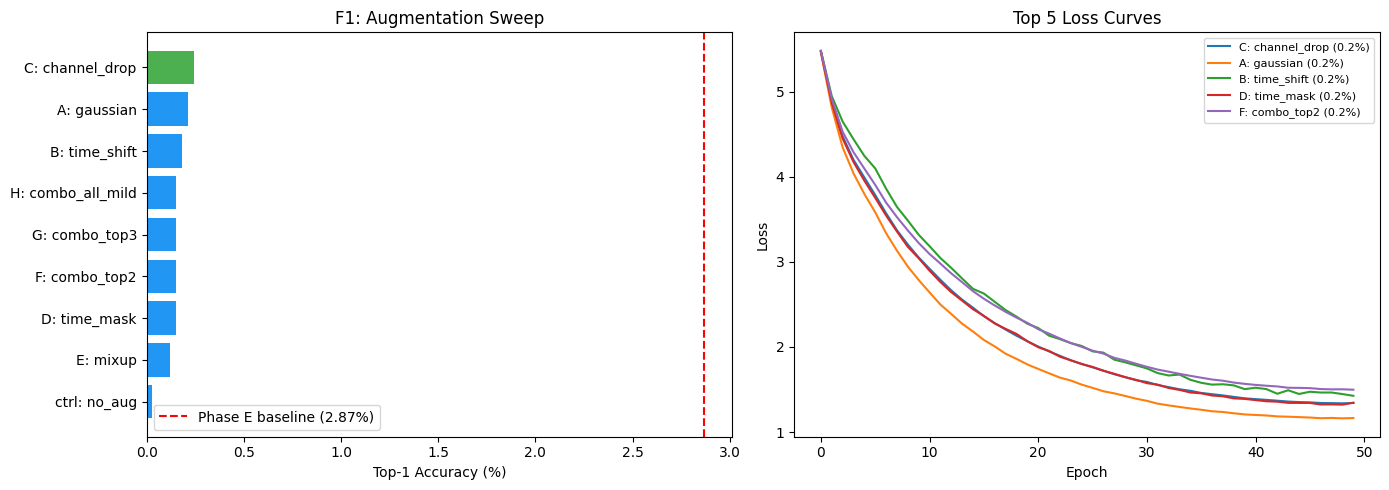

Saved: figures/phase_f_stage1_augmentation.png


In [ ]:
# =============================================================================
# STAGE F1 RESULTS — AUGMENTATION SWEEP
# =============================================================================

print("=" * 80)
print("STAGE F1 RESULTS — DATA AUGMENTATION SWEEP")
print("=" * 80)

all_f1 = [r for r in phase_f_results if r['name'].startswith('F1-')]
print(f"{'Name':<35s} {'Top-1':>7s} {'Top-5':>7s} {'Top-10':>7s} {'Signal':>8s} {'Loss':>8s} {'Time':>6s}")
print("-" * 80)
for r in sorted(all_f1, key=lambda x: x['top_1'], reverse=True):
    print(f"{r['name']:<35s} {r['top_1']*100:>6.2f}% {r['top_5']*100:>6.2f}% "
          f"{r['top_10']*100:>6.2f}% {r['signal']:>7.1f}x {r['final_loss']:>7.4f} {r['time']:>5.0f}s")
print("-" * 80)
print(f"\nBASELINE (Phase E, no aug): top-1 = 2.87%")
print(f"BEST AUG: {BEST_AUG['name']} — top-1 = {BEST_AUG['top_1']*100:.2f}%")

# Save figure
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

names = [r['name'].replace('F1-', '') for r in sorted(all_f1, key=lambda x: x['top_1'])]
accs = [r['top_1']*100 for r in sorted(all_f1, key=lambda x: x['top_1'])]
colors = ['#4CAF50' if r['top_1'] == BEST_AUG['top_1'] else '#2196F3'
          for r in sorted(all_f1, key=lambda x: x['top_1'])]
ax1.barh(names, accs, color=colors)
ax1.axvline(x=2.87, color='red', linestyle='--', label='Phase E baseline (2.87%)')
ax1.set_xlabel('Top-1 Accuracy (%)')
ax1.set_title('F1: Augmentation Sweep')
ax1.legend()

top5 = sorted(all_f1, key=lambda x: x['top_1'], reverse=True)[:5]
for r in top5:
    ax2.plot(r['losses'], label=f"{r['name'].replace('F1-', '')} ({r['top_1']*100:.1f}%)")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Top 5 Loss Curves')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/phase_f_stage1_augmentation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/phase_f_stage1_augmentation.png")

In [ ]:
# =============================================================================
# STAGE F2: LOSS FUNCTION VARIANTS (using AUG*)
# =============================================================================
# Test SupCon and combined losses with class-balanced batching.

print("STAGE F2: Loss Function Variants (using AUG*)")
print("=" * 60)
print(f"  AUG* = {BEST_AUG_CONFIG}")

# F2-I: SupCon only (EEG<->EEG)
run_phase_f_experiment({
    'name': 'F2-I: supcon_only',
    'encoder': 'mlp_ln',
    'loss_type': 'supcon',
    'batch_mode': 'class_balanced',
    'K': 64, 'M': 4,
    'augmentation': BEST_AUG_CONFIG,
})

# F2-J: Combined (0.5 SupCon + 0.5 InfoNCE)
run_phase_f_experiment({
    'name': 'F2-J: combined_0.5',
    'encoder': 'mlp_ln',
    'loss_type': 'combined',
    'lambda_sup': 0.5,
    'batch_mode': 'class_balanced',
    'K': 64, 'M': 4,
    'augmentation': BEST_AUG_CONFIG,
})

# F2-K: Combined (0.3 SupCon + 0.7 InfoNCE)
run_phase_f_experiment({
    'name': 'F2-K: combined_0.3',
    'encoder': 'mlp_ln',
    'loss_type': 'combined',
    'lambda_sup': 0.3,
    'batch_mode': 'class_balanced',
    'K': 64, 'M': 4,
    'augmentation': BEST_AUG_CONFIG,
})

# Compare with AUG* baseline (InfoNCE, standard batch)
all_f2 = [r for r in phase_f_results if r['name'].startswith('F2-')]
all_f2.append(BEST_AUG)  # include F1 winner for comparison
all_f2_sorted = sorted(all_f2, key=lambda r: r['top_1'], reverse=True)
BEST_LOSS = all_f2_sorted[0]

print(f"\n{'='*60}")
print("STAGE F2 RESULTS:")
for r in all_f2_sorted:
    print(f"  {r['name']:<30s} top-1={r['top_1']*100:.2f}%  top-5={r['top_5']*100:.2f}%  signal={r['signal']:.1f}x")
print(f"\nBEST LOSS: {BEST_LOSS['name']} — top-1 = {BEST_LOSS['top_1']*100:.2f}%")
BEST_LOSS_CONFIG = BEST_LOSS['config']

STAGE F2: Loss Function Variants (using AUG*)
  AUG* = {'channel_drop_prob': 0.15}

EXPERIMENT: F2-I: supcon_only
  encoder=mlp_ln, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=supcon, batch=class_balanced (K=64, M=4)
  augmentation={'channel_drop_prob': 0.15}
  Total parameters: 1,497,344
  Epoch   1/50: loss=5.4516, lr=0.000200
  Epoch  10/50: loss=4.5925, lr=0.000970
  Epoch  20/50: loss=4.0071, lr=0.000750
  Epoch  30/50: loss=3.4609, lr=0.000413
  Epoch  40/50: loss=3.0655, lr=0.000117
  Epoch  50/50: loss=2.9857, lr=0.000000

  RESULTS: top-1=0.06%, top-5=0.42%, top-10=0.79%, signal=1.0x
  Time: 6.4s, Final loss: 2.9857

EXPERIMENT: F2-J: combined_0.5
  encoder=mlp_ln, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=combined, batch=class_balanced (K=64, M=4)
  augmentation={'channel_drop_prob': 0.15}
  Total parameters: 1,497,344
  Epoch   1/50: loss=5.4666, lr=0.000200
  Epoch  10/50: loss=3.9114, lr=0.000970
  Epoch  

In [ ]:
# =============================================================================
# STAGE F2 RESULTS — LOSS FUNCTION SWEEP
# =============================================================================

print("=" * 80)
print("STAGE F2 RESULTS — LOSS FUNCTION SWEEP")
print("=" * 80)

f2_display = [r for r in phase_f_results if r['name'].startswith('F2-')]
f2_display.append(BEST_AUG)
print(f"{'Name':<35s} {'Top-1':>7s} {'Top-5':>7s} {'Top-10':>7s} {'Signal':>8s} {'Loss':>8s} {'Time':>6s}")
print("-" * 80)
for r in sorted(f2_display, key=lambda x: x['top_1'], reverse=True):
    print(f"{r['name']:<35s} {r['top_1']*100:>6.2f}% {r['top_5']*100:>6.2f}% "
          f"{r['top_10']*100:>6.2f}% {r['signal']:>7.1f}x {r['final_loss']:>7.4f} {r['time']:>5.0f}s")
print("-" * 80)
print(f"BEST LOSS: {BEST_LOSS['name']} — top-1 = {BEST_LOSS['top_1']*100:.2f}%")

STAGE F2 RESULTS — LOSS FUNCTION SWEEP
Name                                  Top-1   Top-5  Top-10   Signal     Loss   Time
--------------------------------------------------------------------------------
F1-C: channel_drop                    0.24%   0.70%   1.21%     4.0x  1.3418     6s
F2-J: combined_0.5                    0.21%   0.70%   1.21%     3.5x  2.4519     7s
F2-K: combined_0.3                    0.18%   0.45%   1.21%     3.0x  2.1608     7s
F2-I: supcon_only                     0.06%   0.42%   0.79%     1.0x  2.9857     6s
--------------------------------------------------------------------------------
BEST LOSS: F1-C: channel_drop — top-1 = 0.24%


In [ ]:
# =============================================================================
# STAGE F3: ARCHITECTURE VARIANTS (using AUG* + LOSS*)
# =============================================================================
# Test EEGNet and ShallowConvNet against MLP+LayerNorm baseline.

print("STAGE F3: Architecture Variants (using AUG* + LOSS*)")
print("=" * 60)

# Extract loss settings from best
best_loss_type = BEST_LOSS_CONFIG.get('loss_type', 'infonce')
best_lambda = BEST_LOSS_CONFIG.get('lambda_sup', 0.5)
best_batch_mode = BEST_LOSS_CONFIG.get('batch_mode', 'shuffle')
best_K = BEST_LOSS_CONFIG.get('K', 64)
best_M = BEST_LOSS_CONFIG.get('M', 4)
best_aug = BEST_LOSS_CONFIG.get('augmentation', BEST_AUG_CONFIG)

base_config = {
    'loss_type': best_loss_type,
    'lambda_sup': best_lambda,
    'batch_mode': best_batch_mode,
    'K': best_K, 'M': best_M,
    'augmentation': best_aug,
}

# F3-L: MLP+LN (control)
run_phase_f_experiment({
    **base_config,
    'name': 'F3-L: mlp_ln',
    'encoder': 'mlp_ln',
    'dropout': 0.1,
})

# F3-M: EEGNet small
run_phase_f_experiment({
    **base_config,
    'name': 'F3-M: eegnet_small',
    'encoder': 'eegnet_small',
    'dropout': 0.25,
})

# F3-N: EEGNet large
run_phase_f_experiment({
    **base_config,
    'name': 'F3-N: eegnet_large',
    'encoder': 'eegnet_large',
    'dropout': 0.25,
})

# F3-O: ShallowConvNet
run_phase_f_experiment({
    **base_config,
    'name': 'F3-O: shallow_conv',
    'encoder': 'shallow_conv',
    'dropout': 0.5,
})

# Select best
all_f3 = [r for r in phase_f_results if r['name'].startswith('F3-')]
all_f3_sorted = sorted(all_f3, key=lambda r: r['top_1'], reverse=True)
BEST_ARCH = all_f3_sorted[0]

print(f"\n{'='*60}")
print("STAGE F3 RESULTS:")
for r in all_f3_sorted:
    print(f"  {r['name']:<30s} top-1={r['top_1']*100:.2f}%  top-5={r['top_5']*100:.2f}%  "
          f"signal={r['signal']:.1f}x  params={r['n_params']:,}")
print(f"\nBEST ARCHITECTURE: {BEST_ARCH['name']} — top-1 = {BEST_ARCH['top_1']*100:.2f}%")

STAGE F3: Architecture Variants (using AUG* + LOSS*)

EXPERIMENT: F3-L: mlp_ln
  encoder=mlp_ln, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=infonce, batch=shuffle
  augmentation={'channel_drop_prob': 0.15}
  Total parameters: 1,497,344
  Epoch   1/50: loss=5.4734, lr=0.000200
  Epoch  10/50: loss=3.0513, lr=0.000970
  Epoch  20/50: loss=2.0665, lr=0.000750
  Epoch  30/50: loss=1.6092, lr=0.000413
  Epoch  40/50: loss=1.3966, lr=0.000117
  Epoch  50/50: loss=1.3418, lr=0.000000

  RESULTS: top-1=0.24%, top-5=0.70%, top-10=1.21%, signal=4.0x
  Time: 5.5s, Final loss: 1.3418

EXPERIMENT: F3-M: eegnet_small
  encoder=eegnet_small, embed_dim=128, epochs=50
  lr=0.001, schedule=cosine_warmup, tau=0.15
  loss=infonce, batch=shuffle
  augmentation={'channel_drop_prob': 0.15}
  Total parameters: 337,400
  Epoch   1/50: loss=5.5474, lr=0.000200
  Epoch  10/50: loss=4.2599, lr=0.000970
  Epoch  20/50: loss=3.2779, lr=0.000750
  Epoch  30/50: loss=2.7463, lr=0.000

STAGE F3 RESULTS — ARCHITECTURE SWEEP
Name                                  Top-1   Top-5  Top-10   Signal     Params   Time
--------------------------------------------------------------------------------
F3-L: mlp_ln                          0.24%   0.70%   1.21%     4.0x  1,497,344     6s
F3-O: shallow_conv                    0.12%   0.45%   0.94%     2.0x    407,448     6s
F3-M: eegnet_small                    0.09%   0.39%   1.00%     1.5x    337,400     7s
F3-N: eegnet_large                    0.06%   0.39%   0.82%     1.0x    346,864     6s
--------------------------------------------------------------------------------

BASELINE (Phase E): top-1 = 2.87%
BEST F: F3-L: mlp_ln — top-1 = 0.24%

BEST OVERALL PHASE F CONFIG:
  loss_type: infonce
  lambda_sup: 0.5
  batch_mode: shuffle
  K: 64
  M: 4
  augmentation: {'channel_drop_prob': 0.15}
  encoder: mlp_ln
  dropout: 0.1


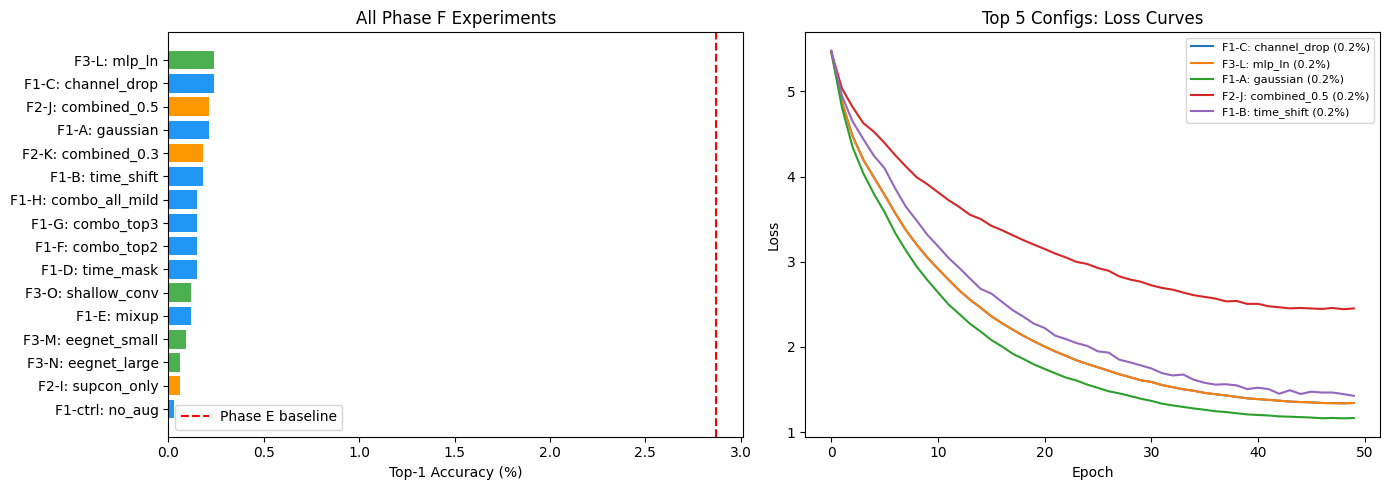

Saved: figures/phase_f_stage3_architecture.png


In [ ]:
# =============================================================================
# STAGE F3 RESULTS — ARCHITECTURE SWEEP
# =============================================================================

print("=" * 80)
print("STAGE F3 RESULTS — ARCHITECTURE SWEEP")
print("=" * 80)

all_f3 = [r for r in phase_f_results if r['name'].startswith('F3-')]
print(f"{'Name':<35s} {'Top-1':>7s} {'Top-5':>7s} {'Top-10':>7s} {'Signal':>8s} {'Params':>10s} {'Time':>6s}")
print("-" * 80)
for r in sorted(all_f3, key=lambda x: x['top_1'], reverse=True):
    print(f"{r['name']:<35s} {r['top_1']*100:>6.2f}% {r['top_5']*100:>6.2f}% "
          f"{r['top_10']*100:>6.2f}% {r['signal']:>7.1f}x {r['n_params']:>10,} {r['time']:>5.0f}s")
print("-" * 80)
print(f"\nBASELINE (Phase E): top-1 = 2.87%")
print(f"BEST F: {BEST_ARCH['name']} — top-1 = {BEST_ARCH['top_1']*100:.2f}%")

BEST_F = BEST_ARCH['config']
print(f"\n{'='*60}")
print("BEST OVERALL PHASE F CONFIG:")
for k, v in BEST_F.items():
    if k != 'name':
        print(f"  {k}: {v}")

# Save figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

all_results = sorted(phase_f_results, key=lambda x: x['top_1'])
names = [r['name'] for r in all_results]
accs = [r['top_1']*100 for r in all_results]
stage_colors = []
for r in all_results:
    if r['name'].startswith('F1-'): stage_colors.append('#2196F3')
    elif r['name'].startswith('F2-'): stage_colors.append('#FF9800')
    elif r['name'].startswith('F3-'): stage_colors.append('#4CAF50')
    else: stage_colors.append('#9E9E9E')
ax1.barh(names, accs, color=stage_colors)
ax1.axvline(x=2.87, color='red', linestyle='--', label='Phase E baseline')
ax1.set_xlabel('Top-1 Accuracy (%)')
ax1.set_title('All Phase F Experiments')
ax1.legend()

top5 = sorted(phase_f_results, key=lambda x: x['top_1'], reverse=True)[:5]
for r in top5:
    ax2.plot(r['losses'], label=f"{r['name']} ({r['top_1']*100:.1f}%)")
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Top 5 Configs: Loss Curves')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('figures/phase_f_stage3_architecture.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/phase_f_stage3_architecture.png")

In [ ]:
# =============================================================================
# FULL PIPELINE RE-RUN WITH BEST PHASE F CONFIG
# =============================================================================

print("=" * 70)
print("FULL PIPELINE RE-RUN WITH BEST PHASE F CONFIG")
print("=" * 70)
print(f"Config: {BEST_F}")

# Step 1: Use the already-trained encoder from the best experiment
best_enc = BEST_ARCH['encoder_obj']
best_tp = BEST_ARCH['text_proj_obj']
best_embed_dim = BEST_F.get('embed_dim', 128)

print(f"\nStep 1: Using best encoder from {BEST_ARCH['name']}")
print(f"  Encoder top-1: {BEST_ARCH['top_1']*100:.2f}%")

# Step 2: Extract embeddings
print("\nStep 2: Extracting embeddings...")
best_enc.eval()
best_tp.eval()
with torch.no_grad():
    E_train_seen_f = best_enc(X_train_tensor.to(device)).cpu().numpy()
    E_test_seen_f = best_enc(X_test_tensor.to(device)).cpu().numpy()
    E_unseen_f = best_enc(X_unseen_tensor.to(device)).cpu().numpy()
print(f"  E_train_seen: {E_train_seen_f.shape}")
print(f"  E_test_seen:  {E_test_seen_f.shape}")
print(f"  E_unseen:     {E_unseen_f.shape}")

# Step 3: Compute prototypes
print("\nStep 3: Computing prototypes...")
with torch.no_grad():
    T_train_proj = best_tp(T_train_tensor.to(device)).cpu().numpy()
    T_unseen_proj = best_tp(T_unseen_tensor.to(device)).cpu().numpy()

seen_classes_sorted = np.sort(np.unique(label_train_seen))
S_seen_f = np.zeros((len(seen_classes_sorted), best_embed_dim))
for i, c in enumerate(seen_classes_sorted):
    mask = label_train_seen == c
    S_seen_f[i] = T_train_proj[mask].mean(axis=0)
    S_seen_f[i] /= np.linalg.norm(S_seen_f[i])

unseen_labels_np = Y_unseen_tensor.numpy()
unseen_classes_sorted = np.sort(np.unique(unseen_labels_np))
S_unseen_f = np.zeros((len(unseen_classes_sorted), best_embed_dim))
for i, c in enumerate(unseen_classes_sorted):
    mask = unseen_labels_np == c
    S_unseen_f[i] = T_unseen_proj[mask].mean(axis=0)
    S_unseen_f[i] /= np.linalg.norm(S_unseen_f[i])

print(f"  Seen prototypes: {S_seen_f.shape}")
print(f"  Unseen prototypes: {S_unseen_f.shape}")

# Step 4: Save cached arrays
print("\nStep 4: Saving cached arrays...")
np.save('cached_arrays/E_train_seen.npy', E_train_seen_f)
np.save('cached_arrays/E_test_seen.npy', E_test_seen_f)
np.save('cached_arrays/E_unseen.npy', E_unseen_f)
np.save('cached_arrays/S_seen_prototypes.npy', S_seen_f)
np.save('cached_arrays/S_unseen_prototypes.npy', S_unseen_f)
print("  Cached arrays overwritten.")

# Step 5: Retrain WGAN-GP
print("\nStep 5: Retraining WGAN-GP...")
torch.manual_seed(42)

wgan_embed_dim = best_embed_dim
gen_f = Generator(z_dim=WGAN_CONFIG['z_dim'], embed_dim=wgan_embed_dim).to(device)
crit_f = Critic(embed_dim=wgan_embed_dim).to(device)

opt_g = torch.optim.Adam(gen_f.parameters(), lr=WGAN_CONFIG['lr'], betas=WGAN_CONFIG['betas'])
opt_c = torch.optim.Adam(crit_f.parameters(), lr=WGAN_CONFIG['lr'], betas=WGAN_CONFIG['betas'])

E_train_tensor_f = torch.FloatTensor(E_train_seen_f).to(device)
S_train_cond_f = torch.FloatTensor(T_train_proj).to(device)
S_train_cond_f = F.normalize(S_train_cond_f, p=2, dim=-1)

n_samples = E_train_tensor_f.shape[0]
n_critic = WGAN_CONFIG['n_critic']
n_steps = WGAN_CONFIG['n_steps']
lam_gp = WGAN_CONFIG['lambda_gp']
z_dim = WGAN_CONFIG['z_dim']
bs = WGAN_CONFIG['batch_size']

for step in range(1, n_steps + 1):
    for _ in range(n_critic):
        idx = torch.randint(0, n_samples, (bs,))
        real_e = E_train_tensor_f[idx]
        cond = S_train_cond_f[idx]
        z = torch.randn(bs, z_dim, device=device)
        fake_e = gen_f(z, cond)

        c_real = crit_f(real_e, cond).mean()
        c_fake = crit_f(fake_e.detach(), cond).mean()
        gp = compute_gradient_penalty(crit_f, real_e, fake_e.detach(), cond, device)

        c_loss = c_fake - c_real + lam_gp * gp
        opt_c.zero_grad()
        c_loss.backward()
        opt_c.step()

    z = torch.randn(bs, z_dim, device=device)
    idx = torch.randint(0, n_samples, (bs,))
    cond = S_train_cond_f[idx]
    fake_e = gen_f(z, cond)
    g_loss = -crit_f(fake_e, cond).mean()
    opt_g.zero_grad()
    g_loss.backward()
    opt_g.step()

    if step % 2000 == 0:
        print(f"  WGAN step {step}/{n_steps}: G={g_loss.item():.4f}, C={c_loss.item():.4f}")

print("  WGAN-GP training complete.")

# Step 6: Generate synthetic unseen embeddings
print("\nStep 6: Generating synthetic unseen embeddings...")
gen_f.eval()
n_synth = WGAN_CONFIG['n_synth_per_class']
E_synth_list = []
y_synth_list = []
with torch.no_grad():
    for i, c in enumerate(unseen_classes_sorted):
        cond = torch.FloatTensor(S_unseen_f[i]).unsqueeze(0).repeat(n_synth, 1).to(device)
        z = torch.randn(n_synth, z_dim, device=device)
        synth = gen_f(z, cond).cpu().numpy()
        E_synth_list.append(synth)
        y_synth_list.extend([c] * n_synth)

E_synth_unseen_f = np.vstack(E_synth_list)
y_synth_unseen_f = np.array(y_synth_list)
print(f"  E_synth_unseen: {E_synth_unseen_f.shape}")

# Step 7: GZSL evaluation (balanced counts)
print("\nStep 7: GZSL evaluation (balanced counts)...")
from collections import Counter
seen_counts = Counter(label_train_seen)
mean_seen_per_class = np.mean(list(seen_counts.values()))
target_per_unseen = int(round(mean_seen_per_class))

E_synth_bal = []
y_synth_bal = []
for c in unseen_classes_sorted:
    mask = y_synth_unseen_f == c
    indices = np.where(mask)[0]
    if len(indices) > target_per_unseen:
        chosen = np.random.choice(indices, target_per_unseen, replace=False)
    else:
        chosen = indices
    E_synth_bal.append(E_synth_unseen_f[chosen])
    y_synth_bal.extend([c] * len(chosen))

E_synth_bal = np.vstack(E_synth_bal)
y_synth_bal = np.array(y_synth_bal)

max_seen = int(seen_classes_sorted.max())
y_synth_bal_offset = y_synth_bal + max_seen
y_unseen_offset = unseen_labels_np + max_seen

X_gzsl = np.vstack([E_train_seen_f, E_synth_bal])
y_gzsl = np.concatenate([label_train_seen, y_synth_bal_offset])

clf_f = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42)
clf_f.fit(X_gzsl, y_gzsl)

pred_seen = clf_f.predict(E_test_seen_f)
acc_s = (pred_seen == label_test_seen).mean()

pred_unseen = clf_f.predict(E_unseen_f)
acc_u = (pred_unseen == y_unseen_offset).mean()

h_mean = 2 * acc_s * acc_u / (acc_s + acc_u + 1e-8)

unseen_label_set = set(y_synth_bal_offset)
all_preds = np.concatenate([pred_seen, pred_unseen])
routing_rate = np.mean([p in unseen_label_set for p in all_preds])

clf_synth = LogisticRegression(max_iter=1000, solver='saga', n_jobs=-1, random_state=42)
clf_synth.fit(E_synth_unseen_f, y_synth_unseen_f)
transfer_acc = clf_synth.score(E_unseen_f, unseen_labels_np)

print(f"\n{'='*60}")
print("OPTIMISED PIPELINE RESULTS (Phase F)")
print(f"{'='*60}")
print(f"  Encoder top-1 (seen-only): {BEST_ARCH['top_1']*100:.2f}%")
print(f"  AccS (GZSL):               {acc_s*100:.2f}%")
print(f"  AccU (GZSL):               {acc_u*100:.2f}%")
print(f"  H-mean:                    {h_mean*100:.2f}%")
print(f"  Routing rate:              {routing_rate*100:.2f}%")
print(f"  Synth->Real transfer:      {transfer_acc*100:.2f}%")

pipeline_f_results = {
    'encoder_top1': BEST_ARCH['top_1'],
    'acc_s': acc_s, 'acc_u': acc_u, 'h_mean': h_mean,
    'routing_rate': routing_rate, 'transfer': transfer_acc,
}

FULL PIPELINE RE-RUN WITH BEST PHASE F CONFIG
Config: {'loss_type': 'infonce', 'lambda_sup': 0.5, 'batch_mode': 'shuffle', 'K': 64, 'M': 4, 'augmentation': {'channel_drop_prob': 0.15}, 'name': 'F3-L: mlp_ln', 'encoder': 'mlp_ln', 'dropout': 0.1}

Step 1: Using best encoder from F3-L: mlp_ln
  Encoder top-1: 0.24%

Step 2: Extracting embeddings...
  E_train_seen: (13232, 128)
  E_test_seen:  (3308, 128)
  E_unseen:     (16000, 128)

Step 3: Computing prototypes...
  Seen prototypes: (1654, 128)
  Unseen prototypes: (200, 128)

Step 4: Saving cached arrays...
  Cached arrays overwritten.

Step 5: Retraining WGAN-GP...
  WGAN step 2000/10000: G=0.1082, C=-0.0300
  WGAN step 4000/10000: G=0.1046, C=-0.0246
  WGAN step 6000/10000: G=-0.2827, C=-0.0206
  WGAN step 8000/10000: G=-0.6143, C=-0.0255
  WGAN step 10000/10000: G=-0.8564, C=-0.0240
  WGAN-GP training complete.

Step 6: Generating synthetic unseen embeddings...
  E_synth_unseen: (4000, 128)

Step 7: GZSL evaluation (balanced counts)

FINAL COMPARISON

Metric                                          Baseline     Phase1    Phase E    Phase F
-------------------------------------------------------------------------------------
Encoder top-1 (seen-only)                          1.90%      1.90%      2.87%      0.24%
AccS (GZSL)                                        0.06%      2.90%      2.96%      2.45%
AccU (GZSL)                                        2.13%      0.22%      0.40%      1.25%
H-mean                                             0.12%      0.42%      0.70%      1.66%
Routing rate                                      99.70%      9.16%     11.31%     46.41%
Synth->Real transfer (200-way)                     1.73%      1.73%      2.51%      2.41%
-------------------------------------------------------------------------------------


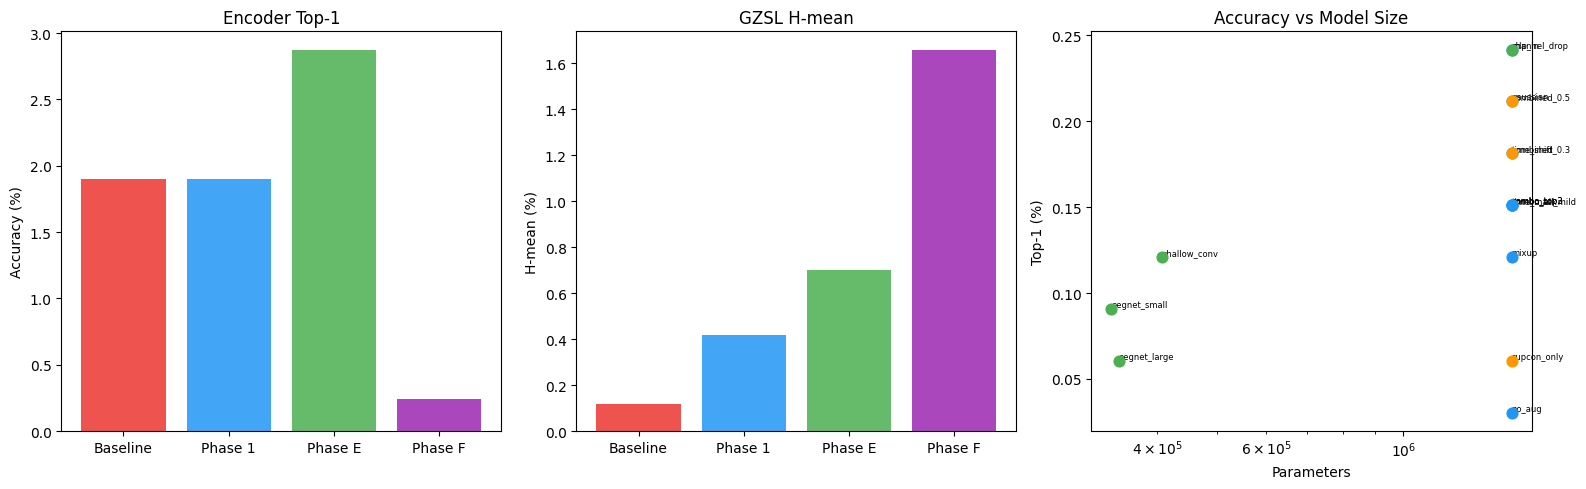

Saved: figures/phase_f_final_comparison.png

PHASE F COMPLETE
Best config: {'loss_type': 'infonce', 'lambda_sup': 0.5, 'batch_mode': 'shuffle', 'K': 64, 'M': 4, 'augmentation': {'channel_drop_prob': 0.15}, 'name': 'F3-L: mlp_ln', 'encoder': 'mlp_ln', 'dropout': 0.1}


In [ ]:
# =============================================================================
# FINAL COMPARISON — PHASE F vs PHASE E vs BASELINE
# =============================================================================

print("=" * 80)
print("FINAL COMPARISON")
print("=" * 80)

baseline = {'enc': 1.90, 'acc_s': 0.06, 'acc_u': 2.13, 'h': 0.12, 'rr': 99.70, 'xfer': 1.73}
phase1 =   {'enc': 1.90, 'acc_s': 2.90, 'acc_u': 0.22, 'h': 0.42, 'rr': 9.16,  'xfer': 1.73}
phase_e =  {'enc': 2.87, 'acc_s': 2.96, 'acc_u': 0.40, 'h': 0.70, 'rr': 11.31, 'xfer': 2.51}
phase_f =  {
    'enc': BEST_ARCH['top_1']*100,
    'acc_s': acc_s*100, 'acc_u': acc_u*100, 'h': h_mean*100,
    'rr': routing_rate*100, 'xfer': transfer_acc*100,
}

print(f"\n{'Metric':<45s} {'Baseline':>10s} {'Phase1':>10s} {'Phase E':>10s} {'Phase F':>10s}")
print("-" * 85)
for label, key in [
    ('Encoder top-1 (seen-only)', 'enc'),
    ('AccS (GZSL)', 'acc_s'),
    ('AccU (GZSL)', 'acc_u'),
    ('H-mean', 'h'),
    ('Routing rate', 'rr'),
    ('Synth->Real transfer (200-way)', 'xfer'),
]:
    print(f"{label:<45s} {baseline[key]:>9.2f}% {phase1[key]:>9.2f}% "
          f"{phase_e[key]:>9.2f}% {phase_f[key]:>9.2f}%")
print("-" * 85)

# Save figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

phases = ['Baseline', 'Phase 1', 'Phase E', 'Phase F']
colors = ['#EF5350', '#42A5F5', '#66BB6A', '#AB47BC']

enc_vals = [baseline['enc'], phase1['enc'], phase_e['enc'], phase_f['enc']]
axes[0].bar(phases, enc_vals, color=colors)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Encoder Top-1')

h_vals = [baseline['h'], phase1['h'], phase_e['h'], phase_f['h']]
axes[1].bar(phases, h_vals, color=colors)
axes[1].set_ylabel('H-mean (%)')
axes[1].set_title('GZSL H-mean')

for r in phase_f_results:
    c = '#2196F3' if r['name'].startswith('F1') else '#FF9800' if r['name'].startswith('F2') else '#4CAF50'
    axes[2].scatter(r['n_params'], r['top_1']*100, color=c, s=60, zorder=5)
    axes[2].annotate(r['name'].split(': ')[1] if ': ' in r['name'] else r['name'],
                     (r['n_params'], r['top_1']*100), fontsize=6, ha='left', va='bottom')
axes[2].set_xlabel('Parameters')
axes[2].set_ylabel('Top-1 (%)')
axes[2].set_title('Accuracy vs Model Size')
axes[2].set_xscale('log')

plt.tight_layout()
plt.savefig('figures/phase_f_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/phase_f_final_comparison.png")

print(f"\n{'='*60}")
print("PHASE F COMPLETE")
print(f"Best config: {BEST_F}")
print(f"{'='*60}")

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')